# E2 TinyFat Analysis Notebook

## 1. Experiment Description

E2 evaluates wire policies on a large random anatomy set. Each anatomy contributes one target at the end of every non-aorta branch. This notebook now keeps the original non-force-aware experiment and the force-aware follow-up experiment side by side.

Core experiment settings:

- experiment: `E2`
- config: `4`
- policy mode: stochastic
- environment start mode: random start
- anatomies sampled: `1000`
- targets per anatomy: `5` in the current anatomy set
- target rule: one `end` target per non-aorta branch
- targets per branch: `1`
- trials per anatomy-target job: `500` per candidate
- non-force-aware candidates per job: `15`
- force-aware candidates per job: `9`
- max episode steps: `828`
- friction: `0.1`

Current local data roots:

- non-force-aware root: `results/master_thesis/e2_tinyfat_finished_readable_20260515`
- force-aware root: `results/master_thesis/e2_force_aware_20260515`
- source non-force-aware TinyFat array job: `1192900`
- source force-aware TinyFat array job: `1201671`

Relevant experiment code:

- queue generation: `scripts/e2_tinyfat_generate_validate.py`
- one-array-task runner: `experiments/master-thesis/run_e2_cell.py`
- notebook/helper code: `experiments/master-thesis/notebook_helpers/e2_tinyfat.py`
- cache builder: `scripts/e2_build_trial_cache.py`


In [13]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable, Optional
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "master-thesis" / "run_e2_cell.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")


PROJECT_ROOT = find_project_root()
HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for path in (PROJECT_ROOT, HELPER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

E2_NON_FORCE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_tinyfat_finished_readable_20260515"
E2_FORCE_AWARE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_force_aware_20260515"

# Keep the old names as aliases for the anatomy/target metadata source.
E2_RESULT_ROOT = E2_NON_FORCE_RESULT_ROOT
E2_METADATA_ROOT = E2_RESULT_ROOT / "metadata"
E2_RUN_ROOT = E2_RESULT_ROOT / "runs" / "config_4"
E2_CACHE_ROOT = E2_RESULT_ROOT / "analysis_cache"
E2_FORCE_AWARE_CACHE_ROOT = E2_FORCE_AWARE_RESULT_ROOT / "analysis_cache"
for cache_root in (E2_CACHE_ROOT, E2_FORCE_AWARE_CACHE_ROOT):
    cache_root.mkdir(parents=True, exist_ok=True)

JOB_ID = "1192900"
FORCE_AWARE_JOB_ID = "1201671"
EXPECTED_TRIALS_PER_WIRE = 500
NON_FORCE_CANDIDATES_PER_JOB = 15
FORCE_AWARE_CANDIDATES_PER_JOB = 9
EXPECTED_NON_FORCE_ROWS_PER_JOB = EXPECTED_TRIALS_PER_WIRE * NON_FORCE_CANDIDATES_PER_JOB
EXPECTED_FORCE_AWARE_ROWS_PER_JOB = EXPECTED_TRIALS_PER_WIRE * FORCE_AWARE_CANDIDATES_PER_JOB
EXPECTED_ROWS_PER_JOB = EXPECTED_NON_FORCE_ROWS_PER_JOB

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"E2_NON_FORCE_RESULT_ROOT={E2_NON_FORCE_RESULT_ROOT}")
print(f"E2_FORCE_AWARE_RESULT_ROOT={E2_FORCE_AWARE_RESULT_ROOT}")


PROJECT_ROOT=/home/hannes-deittert/dev/Uni/master-project
E2_NON_FORCE_RESULT_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_tinyfat_finished_readable_20260515
E2_FORCE_AWARE_RESULT_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_force_aware_20260515


## 2. Generation of the Anatomy Set

The E2 anatomy set is sampled once and stored in the queue metadata. The current metadata says:

- source sample JSON: `results/experimental_prep/sample_1000_e2.json`
- number of selected anatomies: `1000`
- target seed start: `9000`
- target positions: `end`
- targets per branch: `1`

The generation logic is deterministic from the generated metadata: the sampled anatomy list is fixed by the sample JSON, and target seeds are assigned monotonically from `target_seed_start`. Each anatomy contributes one target for each non-aorta branch discovered by `DefaultEvaluationService.list_branches(...)`.

The code cell below loads the actual metadata used for the submitted cluster job. This is better than relying on notebook constants because it documents the exact submitted experiment state.


In [13]:
targets_payload = json.loads((E2_METADATA_ROOT / "targets.json").read_text(encoding="utf-8"))
experiment_config = json.loads((E2_METADATA_ROOT / "experiment_config.json").read_text(encoding="utf-8"))
wires_payload = json.loads((E2_METADATA_ROOT / "wires.json").read_text(encoding="utf-8"))

selected_anatomies = targets_payload["selected_anatomies"]

target_count_by_anatomy = pd.Series([len(item.get("targets", [])) for item in selected_anatomies])
branch_names = sorted({target["branch"] for item in selected_anatomies for target in item.get("targets", [])})

anatomy_set_summary = pd.DataFrame([
    {
        "n_anatomies": len(selected_anatomies),
        "target_counts_unique": sorted(target_count_by_anatomy.unique().tolist()),
        "total_targets": int(target_count_by_anatomy.sum()),
        "branches": ", ".join(branch_names),
        "targets_per_branch": targets_payload.get("targets_per_branch"),
        "target_positions": ", ".join(targets_payload.get("target_positions", [])),
        "target_seed_start": targets_payload.get("target_seed_start"),
        "source_sample_json": targets_payload.get("source_sample_json"),
    }
])

display(anatomy_set_summary)


,n_anatomies,target_counts_unique,total_targets,branches,targets_per_branch,target_positions,target_seed_start,source_sample_json
0,1000,[5],5000,"bct, lcca, lsa, rcca, rsa",1,end,9000,/home/hannes-deittert/dev/Uni/master-project/r...


## 3. Generation of the DataFrames

The dataframe strategy is trial-first for E2:

1. `manifest_df`: one row per planned array job, now combined across non-force-aware and force-aware experiments.
2. `targets_df`: one row per anatomy-target definition from the original E2 metadata. This is the clean target lookup table.
3. `summary_df`: one row per candidate per synced anatomy-target job, loaded from `candidate_summaries.csv`.
4. `trial_df`: one row per trial for every synced complete/readable job. This is the primary analysis table for E2 because it preserves per-trial success, end reason, seed, force, and step count.

For speed, `trial_df` is loaded from each result root's `analysis_cache/trial_df_requested_columns.pkl.gz`. The combined table keeps `training_family` (`non_force_aware` or `force_aware`) and `force_alpha` (`a001`, `a005`, `a05`, or missing for non-force-aware).


In [14]:
def _split_tool_ref(tool_ref: str):
    if "/" not in str(tool_ref):
        return str(tool_ref), ""
    model, wire = str(tool_ref).split("/", maxsplit=1)
    return model, wire


def _decode_if_bytes(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return value


def _manifest_path(result_root: Path) -> Path:
    metadata_root = result_root / "metadata"
    work_manifest = metadata_root / "job_manifest_work.json"
    force_manifest = metadata_root / "job_manifest_force_aware.json"
    if work_manifest.exists():
        return work_manifest
    if force_manifest.exists():
        return force_manifest
    raise FileNotFoundError(f"No supported E2 manifest found under {metadata_root}")


def load_force_aware_candidate_df(result_root: Path = E2_FORCE_AWARE_RESULT_ROOT) -> pd.DataFrame:
    path = result_root / "metadata" / "force_aware_candidates.json"
    if not path.exists():
        return pd.DataFrame(columns=["candidate_name", "force_alpha", "trained_on_wire", "force_aware_model", "force_aware_wire"])
    rows = []
    for item in json.loads(path.read_text(encoding="utf-8")):
        rows.append(
            {
                "candidate_name": item.get("name"),
                "force_alpha": item.get("alpha"),
                "trained_on_wire": item.get("tool_ref"),
                "force_aware_model": item.get("model"),
                "force_aware_wire": item.get("wire"),
            }
        )
    return pd.DataFrame(rows)


def local_run_dir_from_remote(output_dir_remote: str, result_root: Path) -> Path:
    text = str(output_dir_remote)
    markers = [
        f"results/master_thesis/{result_root.name}/",
        "results/master_thesis/e2_tinyfat/",
    ]
    for marker in markers:
        if marker in text:
            return result_root / text.split(marker, maxsplit=1)[1]
    return Path(text)


def load_manifest_df(result_root: Path, training_family: Optional[str] = None) -> pd.DataFrame:
    manifest_path = _manifest_path(result_root)
    payload = json.loads(manifest_path.read_text(encoding="utf-8"))
    if training_family is None:
        training_family = "force_aware" if manifest_path.name == "job_manifest_force_aware.json" else "non_force_aware"
    rows = []
    for idx, job in enumerate(payload.get("jobs", [])):
        target = job.get("target_spec", {})
        config = job.get("config_spec", {})
        rows.append(
            {
                "training_family": training_family,
                "array_index": idx,
                "source_e2_array_index": job.get("source_e2_array_index", idx),
                "job_name": job.get("job_name"),
                "anatomy_id": job.get("anatomy_id"),
                "anatomy_index": job.get("anatomy_index"),
                "target_index": job.get("target_index"),
                "branch": target.get("branch"),
                "target_position": target.get("target_position"),
                "target_seed": target.get("target_seed"),
                "seed_base": job.get("seed_base"),
                "config_id": job.get("config_id"),
                "policy_mode": config.get("policy_mode"),
                "stochastic_environment_mode": config.get("stochastic_environment_mode"),
                "trial_count": config.get("trial_count"),
                "max_episode_steps": config.get("max_episode_steps"),
                "friction": job.get("friction"),
                "output_dir_remote": job.get("output_dir"),
            }
        )
    return pd.DataFrame(rows)


def load_targets_df(metadata_root: Path = E2_METADATA_ROOT) -> pd.DataFrame:
    payload = json.loads((metadata_root / "targets.json").read_text(encoding="utf-8"))
    rows = []
    for anatomy_index, item in enumerate(payload.get("selected_anatomies", [])):
        for target in item.get("targets", []):
            rows.append(
                {
                    "anatomy_index": anatomy_index,
                    "anatomy_id": item.get("record_id"),
                    "arch_type": item.get("arch_type"),
                    "anatomy_seed": item.get("anatomy_seed"),
                    "target_index": target.get("target_index"),
                    "branch": target.get("branch"),
                    "target_position": target.get("target_position"),
                    "target_seed": target.get("target_seed"),
                    "target_kind": target.get("kind"),
                    "branch_point_count": target.get("branch_point_count"),
                    "branch_terminal_index": target.get("branch_terminal_index"),
                    "target_centerline_index": target.get("index"),
                    "threshold_mm": target.get("threshold_mm"),
                }
            )
    return pd.DataFrame(rows)


def load_finished_index_df(metadata_root: Path = E2_METADATA_ROOT, job_id: str = JOB_ID) -> pd.DataFrame:
    report_path = metadata_root / f"finished_complete_readable_{job_id}_report.jsonl"
    list_path = metadata_root / f"finished_complete_readable_{job_id}.txt"
    if report_path.exists():
        rows = [json.loads(line) for line in report_path.read_text(encoding="utf-8").splitlines() if line.strip()]
        return pd.DataFrame(rows)
    if list_path.exists():
        return pd.DataFrame({"relative_run_dir": list_path.read_text(encoding="utf-8").splitlines(), "status": "complete_readable"})
    return pd.DataFrame()


def load_summary_df(manifest_df: pd.DataFrame, result_root: Path, candidate_meta: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    rows = []
    alpha_by_candidate = {}
    trained_wire_by_candidate = {}
    if candidate_meta is not None and not candidate_meta.empty:
        alpha_by_candidate = candidate_meta.set_index("candidate_name")["force_alpha"].to_dict()
        trained_wire_by_candidate = candidate_meta.set_index("candidate_name")["trained_on_wire"].to_dict()
    for _, job in manifest_df.iterrows():
        run_dir = local_run_dir_from_remote(job["output_dir_remote"], result_root=result_root)
        csv_path = run_dir / "candidate_summaries.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        for col in [
            "training_family",
            "array_index",
            "source_e2_array_index",
            "anatomy_id",
            "anatomy_index",
            "target_index",
            "branch",
            "target_position",
            "target_seed",
            "seed_base",
            "config_id",
            "friction",
            "max_episode_steps",
        ]:
            df[col] = job[col]
        df["force_alpha"] = df["candidate_name"].map(alpha_by_candidate) if alpha_by_candidate else pd.NA
        if "trained_on_wire" not in df.columns:
            df["trained_on_wire"] = df["candidate_name"].map(trained_wire_by_candidate) if trained_wire_by_candidate else pd.NA
        df["run_dir"] = str(run_dir)
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    split = out["execution_wire"].map(_split_tool_ref)
    out["wire_model"] = [x[0] for x in split]
    out["wire_shape"] = [x[1] for x in split]
    out["candidate_key"] = out.apply(
        lambda row: f"{row['training_family']}::{row['execution_wire']}::{row['force_alpha']}"
        if pd.notna(row.get("force_alpha"))
        else f"{row['training_family']}::{row['execution_wire']}",
        axis=1,
    )
    return out


# Keep this cell runnable even if the metadata-inspection cell above was skipped.
if "wires_payload" not in globals():
    wires_payload = json.loads((E2_METADATA_ROOT / "wires.json").read_text(encoding="utf-8"))

force_aware_candidate_df = load_force_aware_candidate_df()
non_force_manifest_all_df = load_manifest_df(E2_NON_FORCE_RESULT_ROOT, training_family="non_force_aware")
force_aware_manifest_df = load_manifest_df(E2_FORCE_AWARE_RESULT_ROOT, training_family="force_aware")
force_source_job_ids = set(force_aware_manifest_df["source_e2_array_index"].dropna().astype(int))
non_force_manifest_df = non_force_manifest_all_df[
    non_force_manifest_all_df["source_e2_array_index"].astype(int).isin(force_source_job_ids)
].copy()
manifest_df = pd.concat([non_force_manifest_df, force_aware_manifest_df], ignore_index=True)
targets_df = load_targets_df()
finished_index_df = load_finished_index_df()
non_force_summary_df = load_summary_df(non_force_manifest_df, E2_NON_FORCE_RESULT_ROOT)
force_aware_summary_df = load_summary_df(force_aware_manifest_df, E2_FORCE_AWARE_RESULT_ROOT, force_aware_candidate_df)
summary_df = pd.concat([non_force_summary_df, force_aware_summary_df], ignore_index=True)

coverage_df = (
    summary_df.groupby("training_family", dropna=False)
    .agg(
        planned_jobs=("array_index", "nunique"),
        synced_summary_jobs=("array_index", "nunique"),
        summary_rows=("candidate_name", "size"),
    )
    .reset_index()
)
coverage_df["targets_in_metadata"] = len(targets_df)
coverage_df["expected_rows_per_complete_job"] = coverage_df["training_family"].map(
    {"non_force_aware": EXPECTED_NON_FORCE_ROWS_PER_JOB, "force_aware": EXPECTED_FORCE_AWARE_ROWS_PER_JOB}
)

display(coverage_df)
display(summary_df.head())
display(force_aware_candidate_df)


,training_family,planned_jobs,synced_summary_jobs,summary_rows,targets_in_metadata,expected_rows_per_complete_job
0,force_aware,1700,1700,15300,5000,4500
1,non_force_aware,1700,1700,25500,5000,7500


,scenario_name,candidate_name,execution_wire,trained_on_wire,trial_count,success_rate,valid_rate,soft_score_mean_valid,soft_score_std_valid,candidate_score_final,...,target_seed,seed_base,config_id,friction,max_episode_steps,force_alpha,run_dir,wire_model,wire_shape,candidate_key
0,Tree_03__target_0,archvar_amplatz_gentle_best,amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,500,0.994,0.974,0.935676,0.047513,0.911348,...,9000,123,4,0.1,828,NaN,/home/hannes-deittert/dev/Uni/master-project/r...,amplatz_super_stiff,gentle,non_force_aware::amplatz_super_stiff/gentle
1,Tree_03__target_0,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,500,0.990,0.988,0.922953,0.049262,0.911878,...,9000,123,4,0.1,828,NaN,/home/hannes-deittert/dev/Uni/master-project/r...,amplatz_super_stiff,standard_j,non_force_aware::amplatz_super_stiff/standard_j
2,Tree_03__target_0,archvar_amplatz_straight_best,amplatz_super_stiff/straight,amplatz_super_stiff/straight,500,0.288,0.272,0.772491,0.092727,0.210118,...,9000,123,4,0.1,828,NaN,/home/hannes-deittert/dev/Uni/master-project/r...,amplatz_super_stiff,straight,non_force_aware::amplatz_super_stiff/straight
3,Tree_03__target_0,archvar_amplatz_strong_hook_best,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,500,0.968,0.956,0.933206,0.037743,0.892145,...,9000,123,4,0.1,828,NaN,/home/hannes-deittert/dev/Uni/master-project/r...,amplatz_super_stiff,strong_hook,non_force_aware::amplatz_super_stiff/strong_hook
4,Tree_03__target_0,archvar_amplatz_tight_j_best,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,500,0.992,0.992,0.911461,0.049392,0.904170,...,9000,123,4,0.1,828,NaN,/home/hannes-deittert/dev/Uni/master-project/r...,amplatz_super_stiff,tight_j,non_force_aware::amplatz_super_stiff/tight_j


,candidate_name,force_alpha,trained_on_wire,force_aware_model,force_aware_wire
0,amplatz_super_stiff_standard_j_a001_force_aware,a001,amplatz_super_stiff/standard_j,amplatz_super_stiff,standard_j
1,amplatz_super_stiff_standard_j_a005_force_aware,a005,amplatz_super_stiff/standard_j,amplatz_super_stiff,standard_j
2,amplatz_super_stiff_standard_j_a05_force_aware,a05,amplatz_super_stiff/standard_j,amplatz_super_stiff,standard_j
3,steve_default_standard_j_a001_force_aware,a001,steve_default/standard_j,steve_default,standard_j
4,steve_default_standard_j_a005_force_aware,a005,steve_default/standard_j,steve_default,standard_j
5,steve_default_standard_j_a05_force_aware,a05,steve_default/standard_j,steve_default,standard_j
6,universal_ii_standard_j_a001_force_aware,a001,universal_ii/standard_j,universal_ii,standard_j
7,universal_ii_standard_j_a005_force_aware,a005,universal_ii/standard_j,universal_ii,standard_j
8,universal_ii_standard_j_a05_force_aware,a05,universal_ii/standard_j,universal_ii,standard_j


### 3.1 Trial-Level DataFrame Cache

`trial_df` is the big table: all synced jobs, all candidates, all trials. It is loaded from both result roots and concatenated into one table.

Important comparison columns:

- `training_family`: `non_force_aware` or `force_aware`
- `force_alpha`: missing for non-force-aware rows; `a001`, `a005`, or `a05` for force-aware rows
- `candidate_key`: unique candidate identifier that keeps force-aware alpha values separate
- `wire_model` / `wire_shape`: parsed from `execution_wire`

The cache also keeps `trial_index` and job metadata columns so rows remain traceable after concatenating all jobs.


In [15]:
REQUESTED_TRIAL_COLUMNS = [
    "trial_index",
    "candidate_name",
    "execution_wire",
    "trained_on_wire",
    "end_reason",
    "env_seed",
    "policy_seed",
    "force_available_for_score",
    "force_within_safety_threshold",
    "success",
    "steps_total",
    "tip_force_normal_trial_max_N",
    "tip_force_normal_trial_mean_N",
    "wire_force_normal_trial_max_N",
    "wire_force_normal_trial_mean_N",
]

TRIAL_METADATA_COLUMNS = [
    "training_family",
    "array_index",
    "source_e2_array_index",
    "anatomy_id",
    "anatomy_index",
    "target_index",
    "branch",
    "target_position",
    "target_seed",
    "seed_base",
    "config_id",
    "friction",
    "max_episode_steps",
]

# Keep this False for normal notebook work. Loading both full trial caches at once is large
# (~20.4M rows before any additional derived columns) and can exhaust RAM on a desktop.
LOAD_FULL_E2_TRIALS = False


def load_cached_trial_df(cache_root: Path) -> pd.DataFrame:
    parquet_path = cache_root / "trial_df_requested_columns.parquet"
    pickle_path = cache_root / "trial_df_requested_columns.pkl.gz"
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)
    raise FileNotFoundError(
        "No E2 trial cache found under "
        f"{cache_root}. Build it with: python scripts/e2_build_trial_cache.py <result-root> --format pickle"
    )


def standardize_trial_df(df: pd.DataFrame, training_family: str, cache_path: Path) -> pd.DataFrame:
    df = df.copy()
    if "training_family" not in df.columns:
        df["training_family"] = training_family
    if "source_e2_array_index" not in df.columns:
        df["source_e2_array_index"] = df["array_index"]
    if "force_alpha" not in df.columns:
        df["force_alpha"] = pd.NA
    if "trained_on_wire" not in df.columns:
        df["trained_on_wire"] = pd.NA
    if "policy_seed" not in df.columns:
        df["policy_seed"] = pd.NA
    df["cache_path"] = str(cache_path)
    split = df["execution_wire"].map(_split_tool_ref)
    df["wire_model"] = [x[0] for x in split]
    df["wire_shape"] = [x[1] for x in split]
    df["candidate_key"] = np.where(
        df["force_alpha"].notna(),
        df["training_family"].astype(str) + "::" + df["execution_wire"].astype(str) + "::" + df["force_alpha"].astype(str),
        df["training_family"].astype(str) + "::" + df["execution_wire"].astype(str),
    )
    df["anatomy_target_key"] = (
        df["anatomy_id"].astype(str)
        + "__target_"
        + df["target_index"].astype(str).str.zfill(3)
        + "__"
        + df["branch"].astype(str)
    )
    return df


def load_e2_trial_family(training_family: str) -> pd.DataFrame:
    if training_family == "non_force_aware":
        df = standardize_trial_df(
            load_cached_trial_df(E2_CACHE_ROOT),
            "non_force_aware",
            E2_CACHE_ROOT / "trial_df_requested_columns.pkl.gz",
        )
        force_source_job_ids = set(force_aware_manifest_df["source_e2_array_index"].dropna().astype(int))
        return df[df["source_e2_array_index"].astype(int).isin(force_source_job_ids)].copy()
    if training_family == "force_aware":
        return standardize_trial_df(
            load_cached_trial_df(E2_FORCE_AWARE_CACHE_ROOT),
            "force_aware",
            E2_FORCE_AWARE_CACHE_ROOT / "trial_df_requested_columns.pkl.gz",
        )
    raise ValueError("training_family must be 'non_force_aware' or 'force_aware'")


def load_e2_trial_combined() -> pd.DataFrame:
    return pd.concat(
        [load_e2_trial_family("non_force_aware"), load_e2_trial_family("force_aware")],
        ignore_index=True,
    )


trial_cache_summary = pd.DataFrame(
    [
        {
            "training_family": "non_force_aware",
            "cache_path": str(E2_CACHE_ROOT / "trial_df_requested_columns.pkl.gz"),
            "cache_exists": (E2_CACHE_ROOT / "trial_df_requested_columns.pkl.gz").exists(),
            "matched_jobs": len(non_force_manifest_df),
            "candidate_keys": NON_FORCE_CANDIDATES_PER_JOB,
            "expected_trial_rows": len(non_force_manifest_df) * EXPECTED_NON_FORCE_ROWS_PER_JOB,
        },
        {
            "training_family": "force_aware",
            "cache_path": str(E2_FORCE_AWARE_CACHE_ROOT / "trial_df_requested_columns.pkl.gz"),
            "cache_exists": (E2_FORCE_AWARE_CACHE_ROOT / "trial_df_requested_columns.pkl.gz").exists(),
            "matched_jobs": len(force_aware_manifest_df),
            "candidate_keys": FORCE_AWARE_CANDIDATES_PER_JOB,
            "expected_trial_rows": len(force_aware_manifest_df) * EXPECTED_FORCE_AWARE_ROWS_PER_JOB,
        },
    ]
)
trial_cache_summary["cache_size_GB"] = trial_cache_summary["cache_path"].map(
    lambda value: Path(value).stat().st_size / 1024**3 if Path(value).exists() else np.nan
)

display(trial_cache_summary)

def _show_trial_loading_hint():
    display(Markdown(
        "Full trial caches are not loaded by default to avoid exhausting RAM. "
        "Use `load_e2_trial_family('non_force_aware')`, `load_e2_trial_family('force_aware')`, "
        "or set `LOAD_FULL_E2_TRIALS = True` and rerun this cell if you really need one combined `trial_df`."
    ))

if LOAD_FULL_E2_TRIALS:
    trial_df = load_e2_trial_combined()
    display(
        trial_df.groupby("training_family", dropna=False)
        .agg(
            trial_rows=("trial_index", "size"),
            jobs_in_trial_df=("source_e2_array_index", "nunique"),
            candidate_keys=("candidate_key", "nunique"),
            candidate_wires=("execution_wire", "nunique"),
        )
        .reset_index()
    )
    display(trial_df.head())
else:
    trial_df = None
    _show_trial_loading_hint()


,training_family,cache_path,cache_exists,matched_jobs,candidate_keys,expected_trial_rows,cache_size_GB
0,non_force_aware,/home/hannes-deittert/dev/Uni/master-project/r...,True,1700,15,12750000,0.385719
1,force_aware,/home/hannes-deittert/dev/Uni/master-project/r...,True,1700,9,7650000,0.192633


Full trial caches are not loaded by default to avoid exhausting RAM. Use `load_e2_trial_family('non_force_aware')`, `load_e2_trial_family('force_aware')`, or set `LOAD_FULL_E2_TRIALS = True` and rerun this cell if you really need one combined `trial_df`.

## 3.2 Bootstrap Wire Scores With E1-Style Calibration

This section computes per-wire scores for the large E2 experiment using the same trial-score logic as the E1 confidence analysis:

1. Efficiency is normalized with the fixed config-4 E1/E2 step budget `828`.
2. Safety is normalized from the maximum whole-wire normal force with the same force-score curve and a hard force limit of `2.0 N`.
3. A trial is valid for the wire score only if it succeeds, stays within the step budget, and stays within the force limit.
4. The wire score for an anatomy-target/candidate group is the mean of `trial_score * valid_for_score` over bootstrapped trials. This is equivalent to `valid_rate * mean_valid_trial_score`.

The computation is intentionally family-specific. Run it once for `force_aware` and once for `non_force_aware`; the outputs are saved as CSV files and are not mixed.


### 3.2.0 Model-Level Success and Valid-Trial Rates

This section summarizes success and validity independently of the final wire score. The success rate counts all trials that reached the target, including trials that exceeded the force threshold. The valid-trial rate counts trials that are valid for ranking. The successful-but-invalid rate is the fraction of all trials that reached the target but were invalid, which primarily captures successful trials excluded by the force constraint.


In [16]:
# Model-level success and valid-trial rates for force-aware and non-force-aware E2 agents.
# Rates are computed from trial counts, not by averaging displayed percentages.
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_paths = [
    E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
    E2_SCORE_OUTPUT_DIR / "e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
]
missing_paths = [path for path in score_paths if not path.exists()]

if missing_paths:
    display(Markdown("Build the E2 bootstrap score tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    score_df = pd.concat([pd.read_csv(path) for path in score_paths], ignore_index=True)

    rate_df = score_df.copy()
    rate_df["force_alpha_label"] = rate_df["force_alpha"].fillna("non_force")
    rate_df["n_trials"] = pd.to_numeric(rate_df["n_trials_available"], errors="coerce")
    rate_df["success_rate"] = pd.to_numeric(rate_df["success_rate"], errors="coerce")
    rate_df["valid_rate"] = pd.to_numeric(rate_df["valid_rate"], errors="coerce")
    rate_df["success_trials"] = rate_df["success_rate"] * rate_df["n_trials"]
    rate_df["valid_trials"] = rate_df["valid_rate"] * rate_df["n_trials"]
    rate_df["successful_but_invalid_trials"] = (rate_df["success_trials"] - rate_df["valid_trials"]).clip(lower=0)
    rate_df["has_successful_trial"] = rate_df["success_trials"].gt(0)
    rate_df["has_valid_successful_trial"] = rate_df["valid_trials"].gt(0)

    def summarize_rates(group_cols):
        summary = (
            rate_df
            .groupby(group_cols, dropna=False)
            .agg(
                n_score_rows=("candidate_key", "count"),
                n_candidate_wires=("candidate_key", "nunique"),
                n_anatomy_target_groups=("anatomy_target_key", "nunique"),
                n_trials=("n_trials", "sum"),
                success_trials=("success_trials", "sum"),
                valid_trials=("valid_trials", "sum"),
                successful_but_invalid_trials=("successful_but_invalid_trials", "sum"),
                anatomy_targets_with_success=("has_successful_trial", "sum"),
                anatomy_targets_with_valid_success=("has_valid_successful_trial", "sum"),
            )
            .reset_index()
        )
        summary["overall_success_rate"] = summary["success_trials"] / summary["n_trials"]
        summary["valid_trial_rate"] = summary["valid_trials"] / summary["n_trials"]
        summary["successful_but_invalid_rate"] = summary["successful_but_invalid_trials"] / summary["n_trials"]
        summary["successful_but_invalid_share_of_successes"] = np.where(
            summary["success_trials"].gt(0),
            summary["successful_but_invalid_trials"] / summary["success_trials"],
            np.nan,
        )
        summary["successful_trials_invalid_force_percent"] = (
            100.0 * summary["successful_but_invalid_share_of_successes"]
        )
        summary["anatomy_target_success_coverage"] = (
            summary["anatomy_targets_with_success"] / summary["n_anatomy_target_groups"]
        )
        summary["anatomy_target_valid_success_coverage"] = (
            summary["anatomy_targets_with_valid_success"] / summary["n_anatomy_target_groups"]
        )
        return summary

    model_cols = ["training_family", "wire_model", "wire_shape", "force_alpha_label"]
    e2_model_rate_summary_df = summarize_rates(model_cols)
    e2_model_rate_summary_df = e2_model_rate_summary_df.sort_values(
        ["overall_success_rate", "valid_trial_rate"],
        ascending=[False, False],
    ).reset_index(drop=True)
    e2_model_rate_summary_df["overall_success_rank"] = np.arange(1, len(e2_model_rate_summary_df) + 1)

    branch_cols = ["training_family", "wire_model", "wire_shape", "force_alpha_label", "branch"]
    e2_model_branch_rate_summary_df = summarize_rates(branch_cols)
    sort_keys = e2_model_rate_summary_df[
        ["training_family", "wire_model", "wire_shape", "force_alpha_label", "overall_success_rank"]
    ]
    e2_model_branch_rate_summary_df = (
        e2_model_branch_rate_summary_df
        .merge(sort_keys, on=["training_family", "wire_model", "wire_shape", "force_alpha_label"], how="left")
        .sort_values(["overall_success_rank", "branch"])
        .reset_index(drop=True)
    )

    display_cols = [
        "overall_success_rank",
        "training_family",
        "wire_model",
        "wire_shape",
        "force_alpha_label",
        "n_candidate_wires",
        "n_anatomy_target_groups",
        "n_trials",
        "overall_success_rate",
        "valid_trial_rate",
        "successful_but_invalid_rate",
        "successful_but_invalid_share_of_successes",
        "successful_trials_invalid_force_percent",
        "anatomy_target_success_coverage",
        "anatomy_target_valid_success_coverage",
    ]
    branch_display_cols = [
        "overall_success_rank",
        "training_family",
        "wire_model",
        "wire_shape",
        "force_alpha_label",
        "branch",
        "n_candidate_wires",
        "n_anatomy_target_groups",
        "n_trials",
        "overall_success_rate",
        "valid_trial_rate",
        "successful_but_invalid_rate",
        "successful_but_invalid_share_of_successes",
        "successful_trials_invalid_force_percent",
        "anatomy_target_success_coverage",
        "anatomy_target_valid_success_coverage",
    ]

    overall_csv = E2_SCORE_OUTPUT_DIR / "e2_model_success_valid_rates_overall.csv"
    branch_csv = E2_SCORE_OUTPUT_DIR / "e2_model_success_valid_rates_by_branch.csv"
    e2_model_rate_summary_df.to_csv(overall_csv, index=False)
    e2_model_branch_rate_summary_df.to_csv(branch_csv, index=False)

    display(Markdown("### Overall model-level success and validity rates"))
    display(Markdown(f"Saved overall table: `{overall_csv}`"))
    display(e2_model_rate_summary_df[display_cols].round(4))

    display(Markdown("### Model-level success and validity rates by target branch"))
    display(Markdown(f"Saved branch table: `{branch_csv}`"))
    display(e2_model_branch_rate_summary_df[branch_display_cols].round(4))


    # Optional compact view: average the three force-aware alpha values per wire family.
    force_aware_alpha_mean_df = e2_model_rate_summary_df.loc[
        e2_model_rate_summary_df["training_family"].eq("force_aware")
    ].copy()

    e2_force_aware_family_alpha_mean_df = (
        force_aware_alpha_mean_df
        .groupby(["training_family", "wire_model", "wire_shape"], dropna=False)
        .agg(
            n_alpha_values=("force_alpha_label", "nunique"),
            mean_overall_success_rate=("overall_success_rate", "mean"),
            mean_valid_trial_rate=("valid_trial_rate", "mean"),
            mean_successful_but_invalid_rate=("successful_but_invalid_rate", "mean"),
            mean_successful_but_invalid_share_of_successes=("successful_but_invalid_share_of_successes", "mean"),
            mean_successful_trials_invalid_force_percent=("successful_trials_invalid_force_percent", "mean"),
            mean_anatomy_target_success_coverage=("anatomy_target_success_coverage", "mean"),
            mean_anatomy_target_valid_success_coverage=("anatomy_target_valid_success_coverage", "mean"),
            total_trials=("n_trials", "sum"),
            total_success_trials=("success_trials", "sum"),
            total_valid_trials=("valid_trials", "sum"),
            total_successful_but_invalid_trials=("successful_but_invalid_trials", "sum"),
        )
        .reset_index()
    )
    e2_force_aware_family_alpha_mean_df["pooled_overall_success_rate"] = (
        e2_force_aware_family_alpha_mean_df["total_success_trials"]
        / e2_force_aware_family_alpha_mean_df["total_trials"]
    )
    e2_force_aware_family_alpha_mean_df["pooled_valid_trial_rate"] = (
        e2_force_aware_family_alpha_mean_df["total_valid_trials"]
        / e2_force_aware_family_alpha_mean_df["total_trials"]
    )
    e2_force_aware_family_alpha_mean_df["pooled_successful_but_invalid_rate"] = (
        e2_force_aware_family_alpha_mean_df["total_successful_but_invalid_trials"]
        / e2_force_aware_family_alpha_mean_df["total_trials"]
    )
    e2_force_aware_family_alpha_mean_df["pooled_successful_trials_invalid_force_percent"] = np.where(
        e2_force_aware_family_alpha_mean_df["total_success_trials"].gt(0),
        100.0
        * e2_force_aware_family_alpha_mean_df["total_successful_but_invalid_trials"]
        / e2_force_aware_family_alpha_mean_df["total_success_trials"],
        np.nan,
    )
    e2_force_aware_family_alpha_mean_df = e2_force_aware_family_alpha_mean_df.sort_values(
        ["pooled_overall_success_rate", "pooled_valid_trial_rate"],
        ascending=[False, False],
    ).reset_index(drop=True)

    force_aware_alpha_mean_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_family_rates_averaged_over_alpha.csv"
    e2_force_aware_family_alpha_mean_df.to_csv(force_aware_alpha_mean_csv, index=False)

    force_aware_alpha_mean_display_cols = [
        "training_family",
        "wire_model",
        "wire_shape",
        "n_alpha_values",
        "mean_overall_success_rate",
        "mean_valid_trial_rate",
        "mean_successful_but_invalid_rate",
        "mean_successful_but_invalid_share_of_successes",
        "mean_successful_trials_invalid_force_percent",
        "mean_anatomy_target_success_coverage",
        "mean_anatomy_target_valid_success_coverage",
        "pooled_overall_success_rate",
        "pooled_valid_trial_rate",
        "pooled_successful_but_invalid_rate",
        "pooled_successful_trials_invalid_force_percent",
    ]

    display(Markdown("### Force-aware family rates averaged over alpha values"))
    display(Markdown(f"Saved alpha-averaged force-aware table: `{force_aware_alpha_mean_csv}`"))
    display(e2_force_aware_family_alpha_mean_df[force_aware_alpha_mean_display_cols].round(4))


### Overall model-level success and validity rates

Saved overall table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_model_success_valid_rates_overall.csv`

,overall_success_rank,training_family,wire_model,wire_shape,force_alpha_label,n_candidate_wires,n_anatomy_target_groups,n_trials,overall_success_rate,valid_trial_rate,successful_but_invalid_rate,successful_but_invalid_share_of_successes,successful_trials_invalid_force_percent,anatomy_target_success_coverage,anatomy_target_valid_success_coverage
0,1,non_force_aware,steve_default,standard_j,non_force,1,1700,850000,0.7543,0.0036,0.7507,0.9952,99.5226,0.9671,0.0553
1,2,non_force_aware,steve_default,tight_j,non_force,1,1700,850000,0.7399,0.0001,0.7398,0.9999,99.9925,0.9824,0.0100
2,3,non_force_aware,amplatz_super_stiff,standard_j,non_force,1,1700,850000,0.7199,0.7157,0.0042,0.0059,0.5858,0.9441,0.9441
3,4,force_aware,universal_ii,standard_j,a05,1,1700,850000,0.6899,0.6897,0.0002,0.0003,0.0283,0.9600,0.9600
4,5,force_aware,universal_ii,standard_j,a001,1,1700,850000,0.6811,0.6808,0.0002,0.0003,0.0335,0.9482,0.9476
5,6,non_force_aware,amplatz_super_stiff,tight_j,non_force,1,1700,850000,0.6516,0.6469,0.0047,0.0071,0.7145,0.9447,0.9441
6,7,force_aware,universal_ii,standard_j,a005,1,1700,850000,0.6491,0.6489,0.0002,0.0003,0.0266,0.9459,0.9459
7,8,force_aware,amplatz_super_stiff,standard_j,a005,1,1700,850000,0.6372,0.6294,0.0078,0.0122,1.2218,0.9341,0.9335
8,9,force_aware,amplatz_super_stiff,standard_j,a05,1,1700,850000,0.6161,0.6109,0.0051,0.0083,0.8343,0.9376,0.9376
9,10,non_force_aware,universal_ii,standard_j,non_force,1,1700,850000,0.5860,0.5858,0.0002,0.0004,0.0400,0.9641,0.9635


### Model-level success and validity rates by target branch

Saved branch table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_model_success_valid_rates_by_branch.csv`

,overall_success_rank,training_family,wire_model,wire_shape,force_alpha_label,branch,n_candidate_wires,n_anatomy_target_groups,n_trials,overall_success_rate,valid_trial_rate,successful_but_invalid_rate,successful_but_invalid_share_of_successes,successful_trials_invalid_force_percent,anatomy_target_success_coverage,anatomy_target_valid_success_coverage
0,1,non_force_aware,steve_default,standard_j,non_force,bct,1,340,170000,0.9123,0.0009,0.9115,0.9991,99.9059,1.0000,0.0441
1,1,non_force_aware,steve_default,standard_j,non_force,lcca,1,340,170000,0.6888,0.0005,0.6883,0.9993,99.9300,0.9559,0.0882
2,1,non_force_aware,steve_default,standard_j,non_force,lsa,1,340,170000,0.9429,0.0166,0.9263,0.9824,98.2420,0.9941,0.1353
3,1,non_force_aware,steve_default,standard_j,non_force,rcca,1,340,170000,0.4772,0.0000,0.4772,1.0000,99.9988,0.9000,0.0029
4,1,non_force_aware,steve_default,standard_j,non_force,rsa,1,340,170000,0.7504,0.0001,0.7503,0.9999,99.9890,0.9853,0.0059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,24,force_aware,steve_default,standard_j,a05,bct,1,340,170000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000
116,24,force_aware,steve_default,standard_j,a05,lcca,1,340,170000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000
117,24,force_aware,steve_default,standard_j,a05,lsa,1,340,170000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000
118,24,force_aware,steve_default,standard_j,a05,rcca,1,340,170000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000


### Force-aware family rates averaged over alpha values

Saved alpha-averaged force-aware table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_family_rates_averaged_over_alpha.csv`

,training_family,wire_model,wire_shape,n_alpha_values,mean_overall_success_rate,mean_valid_trial_rate,mean_successful_but_invalid_rate,mean_successful_but_invalid_share_of_successes,mean_successful_trials_invalid_force_percent,mean_anatomy_target_success_coverage,mean_anatomy_target_valid_success_coverage,pooled_overall_success_rate,pooled_valid_trial_rate,pooled_successful_but_invalid_rate,pooled_successful_trials_invalid_force_percent
0,force_aware,universal_ii,standard_j,3,0.6734,0.6732,0.0002,0.0003,0.0295,0.9514,0.9512,0.6734,0.6732,0.0002,0.0295
1,force_aware,amplatz_super_stiff,standard_j,3,0.6074,0.6011,0.0063,0.0104,1.0350,0.9384,0.9380,0.6074,0.6011,0.0063,1.0368
2,force_aware,steve_default,standard_j,3,0.1053,0.0009,0.1044,0.9904,99.0374,0.1243,0.0084,0.1053,0.0009,0.1044,99.1918


### 3.2.0a Overall Score Distribution and Branch Maxima

This section inspects the E2 score distribution over all anatomy-target combinations and all candidate expert units, including both force-aware and non-force-aware agents. It also reports the highest observed wire score in each target branch across all wires and anatomies.


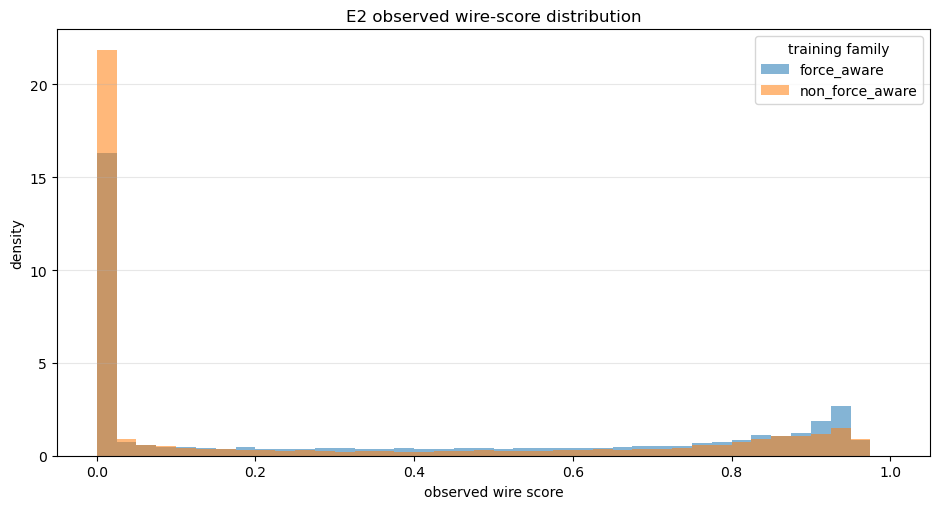

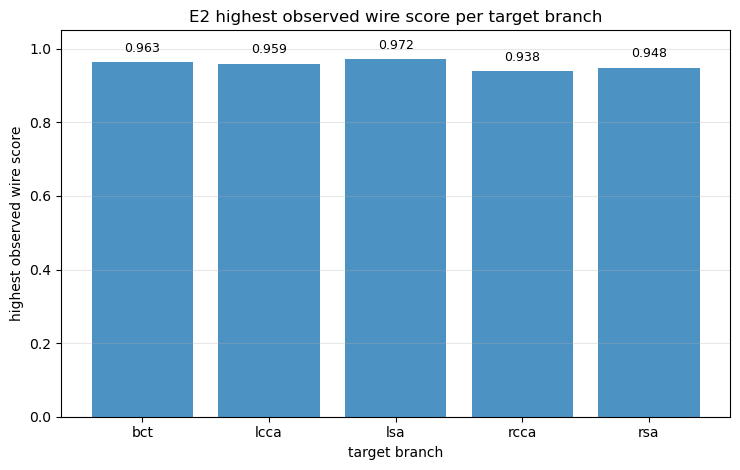

### Overall score distribution

Saved overall distribution table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_score_distribution_overall.csv`

,training_family,n_score_rows,n_expert_units,n_anatomy_target_groups,mean_score,median_score,std_score,min_score,q05_score,q25_score,q75_score,q95_score,max_score
0,force_aware,15300,9,1700,0.3654,0.2116,0.3808,0.0,0.0,0.0,0.7894,0.9396,0.9678
1,non_force_aware,25500,15,1700,0.2717,0.0033,0.3654,0.0,0.0,0.0,0.6482,0.9323,0.9718


### Score distribution by branch and training family

Saved branch distribution table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_score_distribution_by_branch.csv`

,training_family,branch,n_score_rows,n_expert_units,n_anatomy_target_groups,mean_score,median_score,std_score,min_score,q05_score,q25_score,q75_score,q95_score,max_score
0,force_aware,bct,3060,9,340,0.5095,0.7364,0.4026,0.0,0.0,0.0,0.8726,0.9399,0.9620
1,force_aware,lcca,3060,9,340,0.3081,0.0517,0.3617,0.0,0.0,0.0,0.6864,0.9243,0.9593
2,force_aware,lsa,3060,9,340,0.5290,0.8119,0.4337,0.0,0.0,0.0,0.9296,0.9535,0.9678
3,force_aware,rcca,3060,9,340,0.1912,0.0485,0.2453,0.0,0.0,0.0,0.3575,0.7056,0.9382
4,force_aware,rsa,3060,9,340,0.2892,0.1756,0.3113,0.0,0.0,0.0,0.5602,0.8503,0.9456
5,non_force_aware,bct,5100,15,340,0.3827,0.1879,0.3968,0.0,0.0,0.0,0.8257,0.9205,0.9630
6,non_force_aware,lcca,5100,15,340,0.2202,0.0000,0.3285,0.0,0.0,0.0,0.4600,0.8710,0.9541
7,non_force_aware,lsa,5100,15,340,0.4955,0.7018,0.4301,0.0,0.0,0.0,0.9222,0.9561,0.9718
8,non_force_aware,rcca,5100,15,340,0.0616,0.0000,0.1334,0.0,0.0,0.0,0.0474,0.3746,0.9104
9,non_force_aware,rsa,5100,15,340,0.1986,0.0016,0.2916,0.0,0.0,0.0,0.3817,0.8130,0.9481


### Highest observed score per target branch

Saved branch maximum table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_highest_score_per_branch.csv`

Saved figures: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_score_distribution_histogram.png`, `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_highest_score_per_branch_bar.png`

,branch,highest_observed_wire_score,training_family,wire_model,wire_shape,force_alpha_label,candidate_name,execution_wire,anatomy_target_key,anatomy_id,target_index,valid_rate,success_rate,mean_wire_force_max_N
0,bct,0.9630,non_force_aware,universal_ii,tight_j,non_force,archvar_universalii_tight_j_best,universal_ii/tight_j,Tree_1510__target_000__bct,Tree_1510,0,1.000,1.000,0.0553
1,lcca,0.9593,force_aware,universal_ii,standard_j,a001,universal_ii_standard_j_a001_force_aware,universal_ii/standard_j,Tree_03__target_001__lcca,Tree_03,1,1.000,1.000,0.0587
2,lsa,0.9718,non_force_aware,universal_ii,straight,non_force,archvar_universalii_straight_best,universal_ii/straight,Tree_2471__target_002__lsa,Tree_2471,2,1.000,1.000,0.0242
3,rcca,0.9382,force_aware,universal_ii,standard_j,a001,universal_ii_standard_j_a001_force_aware,universal_ii/standard_j,Tree_1288__target_003__rcca,Tree_1288,3,0.996,0.996,0.1066
4,rsa,0.9481,non_force_aware,universal_ii,tight_j,non_force,archvar_universalii_tight_j_best,universal_ii/tight_j,Tree_1168__target_004__rsa,Tree_1168,4,1.000,1.000,0.0809


In [17]:
# Overall E2 score distribution across all anatomy-target groups and candidate expert units.
# Also identify the highest observed score per target branch.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_paths = [
    E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
    E2_SCORE_OUTPUT_DIR / "e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
]
missing_paths = [path for path in score_paths if not path.exists()]

if missing_paths:
    display(Markdown("Build the E2 bootstrap score tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    score_df = pd.concat([pd.read_csv(path) for path in score_paths], ignore_index=True)
    score_df["observed_wire_score"] = pd.to_numeric(score_df["observed_wire_score"], errors="coerce")
    score_df["force_alpha_label"] = score_df["force_alpha"].fillna("non_force")
    score_df["expert_unit"] = (
        score_df["training_family"].astype(str)
        + " / " + score_df["wire_model"].astype(str)
        + " / " + score_df["wire_shape"].astype(str)
        + " / " + score_df["force_alpha_label"].astype(str)
    )

    def score_distribution_summary(group_cols):
        return (
            score_df
            .groupby(group_cols, dropna=False)
            .agg(
                n_score_rows=("observed_wire_score", "count"),
                n_expert_units=("expert_unit", "nunique"),
                n_anatomy_target_groups=("anatomy_target_key", "nunique"),
                mean_score=("observed_wire_score", "mean"),
                median_score=("observed_wire_score", "median"),
                std_score=("observed_wire_score", "std"),
                min_score=("observed_wire_score", "min"),
                q05_score=("observed_wire_score", lambda s: s.quantile(0.05)),
                q25_score=("observed_wire_score", lambda s: s.quantile(0.25)),
                q75_score=("observed_wire_score", lambda s: s.quantile(0.75)),
                q95_score=("observed_wire_score", lambda s: s.quantile(0.95)),
                max_score=("observed_wire_score", "max"),
            )
            .reset_index()
        )

    e2_score_distribution_overall_df = score_distribution_summary(["training_family"])
    e2_score_distribution_by_branch_df = score_distribution_summary(["training_family", "branch"])

    # One row per branch: the single highest score observed over all anatomies and expert units.
    best_idx = score_df.groupby("branch", dropna=False)["observed_wire_score"].idxmax()
    e2_highest_score_per_branch_df = (
        score_df.loc[best_idx, [
            "branch",
            "observed_wire_score",
            "training_family",
            "wire_model",
            "wire_shape",
            "force_alpha_label",
            "candidate_name",
            "execution_wire",
            "anatomy_target_key",
            "anatomy_id",
            "target_index",
            "valid_rate",
            "success_rate",
            "mean_wire_force_max_N",
        ]]
        .rename(columns={"observed_wire_score": "highest_observed_wire_score"})
        .sort_values("branch")
        .reset_index(drop=True)
    )

    overall_csv = E2_SCORE_OUTPUT_DIR / "e2_score_distribution_overall.csv"
    branch_distribution_csv = E2_SCORE_OUTPUT_DIR / "e2_score_distribution_by_branch.csv"
    branch_max_csv = E2_SCORE_OUTPUT_DIR / "e2_highest_score_per_branch.csv"
    e2_score_distribution_overall_df.to_csv(overall_csv, index=False)
    e2_score_distribution_by_branch_df.to_csv(branch_distribution_csv, index=False)
    e2_highest_score_per_branch_df.to_csv(branch_max_csv, index=False)

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    bins = np.linspace(0, 1, 41)
    for training_family, group in score_df.groupby("training_family", dropna=False):
        ax.hist(
            group["observed_wire_score"].dropna(),
            bins=bins,
            alpha=0.55,
            label=str(training_family),
            density=True,
        )
    ax.set_title("E2 observed wire-score distribution")
    ax.set_xlabel("observed wire score")
    ax.set_ylabel("density")
    ax.legend(title="training family")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    hist_png = E2_SCORE_OUTPUT_DIR / "e2_score_distribution_histogram.png"
    hist_pdf = E2_SCORE_OUTPUT_DIR / "e2_score_distribution_histogram.pdf"
    fig.savefig(hist_png, dpi=200, bbox_inches="tight")
    fig.savefig(hist_pdf, bbox_inches="tight")
    plt.show()

    branch_order = sorted(e2_highest_score_per_branch_df["branch"].dropna().unique())
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    plot_df = e2_highest_score_per_branch_df.set_index("branch").reindex(branch_order).reset_index()
    ax.bar(plot_df["branch"], plot_df["highest_observed_wire_score"], color="tab:blue", alpha=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_title("E2 highest observed wire score per target branch")
    ax.set_xlabel("target branch")
    ax.set_ylabel("highest observed wire score")
    ax.grid(axis="y", alpha=0.3)
    for bar, value in zip(ax.patches, plot_df["highest_observed_wire_score"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    fig.tight_layout()
    branch_max_png = E2_SCORE_OUTPUT_DIR / "e2_highest_score_per_branch_bar.png"
    branch_max_pdf = E2_SCORE_OUTPUT_DIR / "e2_highest_score_per_branch_bar.pdf"
    fig.savefig(branch_max_png, dpi=200, bbox_inches="tight")
    fig.savefig(branch_max_pdf, bbox_inches="tight")
    plt.show()

    display(Markdown("### Overall score distribution"))
    display(Markdown(f"Saved overall distribution table: `{overall_csv}`"))
    display(e2_score_distribution_overall_df.round(4))

    display(Markdown("### Score distribution by branch and training family"))
    display(Markdown(f"Saved branch distribution table: `{branch_distribution_csv}`"))
    display(e2_score_distribution_by_branch_df.round(4))

    display(Markdown("### Highest observed score per target branch"))
    display(Markdown(f"Saved branch maximum table: `{branch_max_csv}`"))
    display(Markdown(f"Saved figures: `{hist_png}`, `{branch_max_png}`"))
    display(e2_highest_score_per_branch_df.round(4))


In [18]:
import matplotlib.pyplot as plt

E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E2_SCORE_STEP_BUDGET = 828.0
E2_FORCE_LIMIT_N = 2.0
E2_BOOTSTRAP_N = 1000
E2_BOOTSTRAP_K = 500
E2_BOOTSTRAP_SEED = 123


def e2_success_to_float(series: pd.Series) -> pd.Series:
    mapped = series.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)


def e2_force_safety_score(force_n: pd.Series) -> pd.Series:
    force = pd.to_numeric(force_n, errors="coerce").clip(lower=0)
    c = 0.30
    p = 2.0
    k = 10.0
    f50 = 1.55
    fmax = E2_FORCE_LIMIT_N
    g = 1.0 / (1.0 + np.exp(k * (force - f50)))
    g0 = 1.0 / (1.0 + np.exp(k * (0.0 - f50)))
    gmax = 1.0 / (1.0 + np.exp(k * (fmax - f50)))
    logistic_part = ((g - gmax) / (g0 - gmax)).clip(0, 1)
    polynomial_part = (1.0 - c * np.power(force, p)).clip(0, 1)
    return (logistic_part * polynomial_part).clip(0, 1)


def e2_score_trials(trials: pd.DataFrame) -> pd.DataFrame:
    scored = trials.copy()
    scored["success_numeric"] = e2_success_to_float(scored["success"])
    scored["steps_total"] = pd.to_numeric(scored["steps_total"], errors="coerce")
    scored["wire_force_normal_trial_max_N"] = pd.to_numeric(scored["wire_force_normal_trial_max_N"], errors="coerce")

    denom = max(E2_SCORE_STEP_BUDGET - 1.0, 1.0)
    scored["step_budget"] = E2_SCORE_STEP_BUDGET
    scored["score_efficiency"] = (1.0 - ((scored["steps_total"] - 1.0) / denom)).clip(0, 1)
    scored.loc[scored["success_numeric"].lt(1.0), "score_efficiency"] = 0.0
    scored["score_safety"] = e2_force_safety_score(scored["wire_force_normal_trial_max_N"])
    scored["within_step_budget"] = scored["steps_total"].le(E2_SCORE_STEP_BUDGET)
    scored["within_force_limit"] = scored["wire_force_normal_trial_max_N"].le(E2_FORCE_LIMIT_N)
    scored["valid_for_score"] = (
        scored["success_numeric"].eq(1.0)
        & scored["within_step_budget"]
        & scored["within_force_limit"]
    )
    scored["trial_score"] = 0.5 * scored["score_efficiency"] + 0.5 * scored["score_safety"]
    scored["efficiency_contribution"] = (0.5 * scored["score_efficiency"]).where(scored["valid_for_score"], 0.0)
    scored["safety_contribution"] = (0.5 * scored["score_safety"]).where(scored["valid_for_score"], 0.0)
    scored["score_contribution"] = scored["efficiency_contribution"] + scored["safety_contribution"]
    return scored


def e2_bootstrap_output_path(training_family: str) -> Path:
    return E2_SCORE_OUTPUT_DIR / f"e2_{training_family}_wire_score_bootstrap_ci_k{E2_BOOTSTRAP_K}_b{E2_BOOTSTRAP_N}.csv"


def bootstrap_mean_ci(values: np.ndarray, rng: np.random.Generator) -> tuple:
    sample_idx = rng.integers(0, len(values), size=(E2_BOOTSTRAP_N, E2_BOOTSTRAP_K))
    boot_scores = values[sample_idx].mean(axis=1)
    ci_low, ci_high = np.quantile(boot_scores, [0.025, 0.975])
    return float(boot_scores.mean()), float(ci_low), float(ci_high), float((ci_high - ci_low) / 2.0)


def build_e2_wire_score_bootstrap_ci(training_family: str, rebuild: bool = False) -> pd.DataFrame:
    out_path = e2_bootstrap_output_path(training_family)
    if out_path.exists() and not rebuild:
        print(f"Loading existing bootstrap table: {out_path}")
        return pd.read_csv(out_path)

    print(f"Loading trial cache for {training_family}...")
    family_trials = load_e2_trial_family(training_family)
    print(f"loaded rows: {len(family_trials):,}")

    keep_cols = [
        "training_family",
        "source_e2_array_index",
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "candidate_key",
        "candidate_name",
        "execution_wire",
        "wire_model",
        "wire_shape",
        "force_alpha",
        "success",
        "steps_total",
        "wire_force_normal_trial_max_N",
    ]
    family_trials = family_trials[[col for col in keep_cols if col in family_trials.columns]].copy()
    scored = e2_score_trials(family_trials)
    del family_trials

    group_cols = [
        "training_family",
        "source_e2_array_index",
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "candidate_key",
        "candidate_name",
        "execution_wire",
        "wire_model",
        "wire_shape",
        "force_alpha",
    ]

    rng = np.random.default_rng(E2_BOOTSTRAP_SEED)
    rows = []
    grouped = list(scored.groupby(group_cols, dropna=False, sort=False))
    print(f"bootstrapping {len(grouped):,} wire/anatomy-target groups with B={E2_BOOTSTRAP_N}, k={E2_BOOTSTRAP_K}")

    for group_index, (key, group) in enumerate(grouped, start=1):
        values = group["score_contribution"].to_numpy(dtype=float)
        n_available = len(values)
        if n_available < E2_BOOTSTRAP_K:
            continue
        boot_mean, ci_low, ci_high, ci_half_width = bootstrap_mean_ci(values, rng)
        valid = group["valid_for_score"].astype(bool)
        observed_score = float(values.mean())
        row = dict(zip(group_cols, key))
        row.update(
            {
                "n_trials_available": int(n_available),
                "n_boot": int(E2_BOOTSTRAP_N),
                "k": int(E2_BOOTSTRAP_K),
                "observed_wire_score": observed_score,
                "observed_efficiency_component": float(group["efficiency_contribution"].mean()),
                "observed_safety_component": float(group["safety_contribution"].mean()),
                "bootstrap_mean_wire_score": boot_mean,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "ci_half_width": ci_half_width,
                "valid_rate": float(valid.mean()),
                "n_valid_trials": int(valid.sum()),
                "mean_valid_trial_score": float(group.loc[valid, "trial_score"].mean()) if valid.any() else 0.0,
                "success_rate": float(group["success_numeric"].mean()),
                "mean_steps_total": float(group["steps_total"].mean()),
                "mean_wire_force_max_N": float(group["wire_force_normal_trial_max_N"].mean()),
            }
        )
        rows.append(row)
        if group_index % 1000 == 0:
            print(f"processed groups: {group_index:,}/{len(grouped):,}")

    result = pd.DataFrame(rows)
    result.to_csv(out_path, index=False)
    print(f"saved: {out_path}")
    display(
        result.groupby("training_family")
        .agg(
            rows=("candidate_key", "size"),
            anatomy_targets=("anatomy_target_key", "nunique"),
            candidate_keys=("candidate_key", "nunique"),
            mean_score=("observed_wire_score", "mean"),
            median_ci_half_width=("ci_half_width", "median"),
        )
        .round(4)
    )
    return result


In [19]:
# Run this cell once per family. It does not mix force-aware and non-force-aware agents.
# Change this value to "non_force_aware" and rerun to build the other table.
E2_BOOTSTRAP_FAMILY_TO_BUILD = "force_aware"  # options: "force_aware", "non_force_aware"
E2_REBUILD_BOOTSTRAP = False

e2_bootstrap_ci_df = build_e2_wire_score_bootstrap_ci(E2_BOOTSTRAP_FAMILY_TO_BUILD, rebuild=E2_REBUILD_BOOTSTRAP)
display(e2_bootstrap_ci_df.head(20).round(4))


Loading existing bootstrap table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,candidate_key,candidate_name,execution_wire,...,bootstrap_mean_wire_score,ci_low,ci_high,ci_half_width,valid_rate,n_valid_trials,mean_valid_trial_score,success_rate,mean_steps_total,mean_wire_force_max_N
0,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,...,0.9191,0.9093,0.9275,0.0091,0.990,495,0.9283,0.990,90.330,0.3454
1,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff_standard_j_a005_force_aware,amplatz_super_stiff/standard_j,...,0.8461,0.8334,0.8594,0.0130,0.984,492,0.8599,0.998,96.914,0.6767
2,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff_standard_j_a05_force_aware,amplatz_super_stiff/standard_j,...,0.7085,0.6726,0.7432,0.0353,0.768,384,0.9224,0.770,252.366,0.4564
3,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::steve_default/standard_j::a001,steve_default_standard_j_a001_force_aware,steve_default/standard_j,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.000,828.000,1.6148
4,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::steve_default/standard_j::a005,steve_default_standard_j_a005_force_aware,steve_default/standard_j,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.000,828.000,0.5181
5,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::steve_default/standard_j::a05,steve_default_standard_j_a05_force_aware,steve_default/standard_j,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.000,828.000,0.0000
6,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::universal_ii/standard_j::a001,universal_ii_standard_j_a001_force_aware,universal_ii/standard_j,...,0.9585,0.9536,0.9618,0.0041,0.998,499,0.9603,0.998,65.854,0.0488
7,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::universal_ii/standard_j::a005,universal_ii_standard_j_a005_force_aware,universal_ii/standard_j,...,0.8778,0.8580,0.8953,0.0186,0.948,474,0.9255,0.948,149.028,0.0747
8,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::universal_ii/standard_j::a05,universal_ii_standard_j_a05_force_aware,universal_ii/standard_j,...,0.1367,0.1081,0.1667,0.0293,0.144,72,0.9478,0.144,721.174,0.0878
9,force_aware,1,Tree_03__target_001__lcca,Tree_03,0,1,lcca,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,...,0.8926,0.8849,0.8996,0.0074,0.996,498,0.8963,0.998,88.440,0.5311


In [20]:
# Run this cell once per family. It does not mix force-aware and non-force-aware agents.
# Change this value to "non_force_aware" and rerun to build the other table.
E2_BOOTSTRAP_FAMILY_TO_BUILD = "non_force_aware"  # options: "force_aware", "non_force_aware"
E2_REBUILD_BOOTSTRAP = False

e2_bootstrap_ci_df = build_e2_wire_score_bootstrap_ci(E2_BOOTSTRAP_FAMILY_TO_BUILD, rebuild=E2_REBUILD_BOOTSTRAP)
display(e2_bootstrap_ci_df.head(20).round(4))


Loading existing bootstrap table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,candidate_key,candidate_name,execution_wire,...,bootstrap_mean_wire_score,ci_low,ci_high,ci_half_width,valid_rate,n_valid_trials,mean_valid_trial_score,success_rate,mean_steps_total,mean_wire_force_max_N
0,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,archvar_amplatz_gentle_best,amplatz_super_stiff/gentle,...,0.8693,0.8542,0.8832,0.0145,0.974,487,0.8929,0.994,103.414,0.5067
1,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/standard_j,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,...,0.8679,0.8570,0.8784,0.0107,0.988,494,0.8785,0.990,140.948,0.4609
2,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/straight,archvar_amplatz_straight_best,amplatz_super_stiff/straight,...,0.1777,0.1522,0.2044,0.0261,0.272,136,0.6536,0.288,716.566,0.3421
3,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/strong_hook,archvar_amplatz_strong_hook_best,amplatz_super_stiff/strong_hook,...,0.8461,0.8285,0.8622,0.0168,0.956,478,0.8850,0.968,92.196,0.6134
4,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/tight_j,archvar_amplatz_tight_j_best,amplatz_super_stiff/tight_j,...,0.8517,0.8419,0.8613,0.0097,0.992,496,0.8584,0.992,155.126,0.5256
5,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::steve_default/gentle,archvar_steve_gentle_best,steve_default/gentle,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.000,828.000,2.2041
6,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::steve_default/standard_j,archvar_steve_standard_j_best,steve_default/standard_j,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.644,373.536,4.9113
7,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::steve_default/straight,archvar_steve_straight_best,steve_default/straight,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.000,674.768,4.0645
8,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::steve_default/strong_hook,archvar_steve_strong_hook_best,steve_default/strong_hook,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.592,398.588,15.5006
9,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::steve_default/tight_j,archvar_steve_tight_j_best,steve_default/tight_j,...,0.0000,0.0000,0.0000,0.0000,0.000,0,0.0000,0.990,79.054,8.8890


### non_force_aware: anatomy-target #20 = `Tree_1047__target_000__bct`

,label,observed_wire_score,bootstrap_mean_wire_score,ci_low,ci_high,valid_rate,success_rate,mean_wire_force_max_N
0,universal_ii/tight_j,0.9629,0.9629,0.9625,0.9632,1.000,1.000,0.0682
1,universal_ii/strong_hook,0.9337,0.9336,0.9295,0.9365,0.998,0.998,0.1116
2,universal_ii/standard_j,0.9047,0.9046,0.8851,0.9225,0.950,0.950,0.0642
3,amplatz_super_stiff/standard_j,0.8971,0.8971,0.8871,0.9064,0.992,0.998,0.5183
4,amplatz_super_stiff/strong_hook,0.8633,0.8631,0.8531,0.8721,0.996,0.998,0.6930
5,amplatz_super_stiff/gentle,0.8208,0.8212,0.8030,0.8385,0.954,0.980,0.6674
6,amplatz_super_stiff/tight_j,0.7975,0.7977,0.7756,0.8172,0.924,0.926,0.6281
7,universal_ii/gentle,0.5634,0.5630,0.5271,0.5961,0.670,0.670,0.0730
8,universal_ii/straight,0.0012,0.0013,0.0000,0.0037,0.002,0.002,0.1038
9,amplatz_super_stiff/straight,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.2105


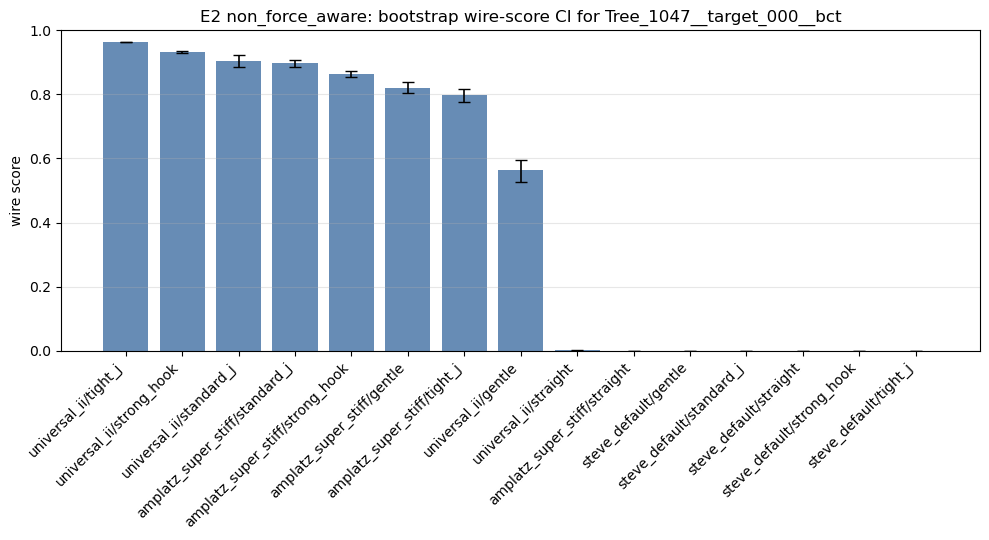

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_Tree_1047__target_000__bct_wire_score_ci.png`

In [21]:
# Select one anatomy-target and one family, then plot all wire options with 95% bootstrap CIs.
# Prefer an explicit key prefix for reproducible thesis figures; set it to None to use the numeric index.
E2_SCORE_PLOT_FAMILY = "non_force_aware"  # options: "force_aware", "non_force_aware"
E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX = "Tree_1047__target_000"
E2_SCORE_PLOT_ANATOMY_TARGET_NUMBER = 1

plot_table_path = e2_bootstrap_output_path(E2_SCORE_PLOT_FAMILY)
if not plot_table_path.exists():
    display(Markdown(f"Build the bootstrap table first: `{plot_table_path}`"))
else:
    plot_source = pd.read_csv(plot_table_path)
    anatomy_targets = sorted(plot_source["anatomy_target_key"].dropna().unique())
    if not anatomy_targets:
        raise ValueError("No anatomy-target keys found in the bootstrap table.")
    if E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX:
        matching_keys = [key for key in anatomy_targets if str(key).startswith(E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX)]
        if not matching_keys:
            raise KeyError(f"No anatomy-target key starts with `{E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX}`.")
        if len(matching_keys) > 1:
            print("Multiple matching anatomy-target keys; using the first:", matching_keys)
        selected_key = matching_keys[0]
        selected_index = anatomy_targets.index(selected_key)
    else:
        selected_index = int(E2_SCORE_PLOT_ANATOMY_TARGET_NUMBER)
        if selected_index < 0 or selected_index >= len(anatomy_targets):
            raise IndexError(f"Select a number from 0 to {len(anatomy_targets) - 1}.")
        selected_key = anatomy_targets[selected_index]

    E2_SCORE_PLOT_ANATOMY_TARGET_NUMBER = selected_index
    E2_SCORE_PLOT_ANATOMY_TARGET_KEY = selected_key
    plot_df = (
        plot_source.loc[plot_source["anatomy_target_key"].eq(selected_key)]
        .sort_values("observed_wire_score", ascending=False)
        .reset_index(drop=True)
    )
    plot_df["label"] = plot_df["execution_wire"].astype(str)
    plot_df.loc[plot_df["force_alpha"].notna(), "label"] = (
        plot_df.loc[plot_df["force_alpha"].notna(), "execution_wire"].astype(str)
        + " / "
        + plot_df.loc[plot_df["force_alpha"].notna(), "force_alpha"].astype(str)
    )

    display(Markdown(f"### {E2_SCORE_PLOT_FAMILY}: anatomy-target #{selected_index} = `{selected_key}`"))
    display(
        plot_df[[
            "label",
            "observed_wire_score",
            "bootstrap_mean_wire_score",
            "ci_low",
            "ci_high",
            "valid_rate",
            "success_rate",
            "mean_wire_force_max_N",
        ]].round(4)
    )

    x = np.arange(len(plot_df))
    y = plot_df["observed_wire_score"].to_numpy(dtype=float)
    yerr = np.vstack([
        y - plot_df["ci_low"].to_numpy(dtype=float),
        plot_df["ci_high"].to_numpy(dtype=float) - y,
    ])

    fig, ax = plt.subplots(figsize=(max(10, len(plot_df) * 0.55), 5.5))
    ax.bar(x, y, color="#4C78A8", alpha=0.85)
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.2, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
    ax.set_ylim(0, min(1.0, max(0.2, float(plot_df["ci_high"].max()) + 0.05)))
    ax.set_ylabel("wire score")
    ax.set_title(f"E2 {E2_SCORE_PLOT_FAMILY}: bootstrap wire-score CI for {selected_key}")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    figure_stem = f"e2_{E2_SCORE_PLOT_FAMILY}_{selected_key}_wire_score_ci"
    figure_stem = figure_stem.replace("/", "_").replace(" ", "_")
    figure_png = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.png"
    figure_pdf = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.pdf"
    fig.savefig(figure_png, dpi=200, bbox_inches="tight")
    fig.savefig(figure_pdf, bbox_inches="tight")
    plt.show()
    display(Markdown(f"Saved figure: `{figure_png}`"))




### Component view: non-force-aware, anatomy-target #20: Tree 1047, target 000 (BCT)

,label,observed_wire_score,observed_efficiency_component,observed_safety_component,valid_percent,ci_low,ci_high
0,universal_ii/tight_j,0.9629,0.4638,0.4991,100.0,0.9625,0.9632
1,universal_ii/strong_hook,0.9337,0.4370,0.4966,99.8,0.9295,0.9365
2,universal_ii/standard_j,0.9047,0.4305,0.4743,95.0,0.8851,0.9225
3,amplatz_super_stiff/standard_j,0.8971,0.4523,0.4448,99.2,0.8871,0.9064
4,amplatz_super_stiff/strong_hook,0.8633,0.4545,0.4089,99.6,0.8531,0.8721
5,amplatz_super_stiff/gentle,0.8208,0.4117,0.4091,95.4,0.8030,0.8385
6,amplatz_super_stiff/tight_j,0.7975,0.3963,0.4012,92.4,0.7756,0.8172
7,universal_ii/gentle,0.5634,0.2292,0.3341,67.0,0.5271,0.5961
8,universal_ii/straight,0.0012,0.0002,0.0010,0.2,0.0000,0.0037
9,amplatz_super_stiff/straight,0.0000,0.0000,0.0000,0.0,0.0000,0.0000


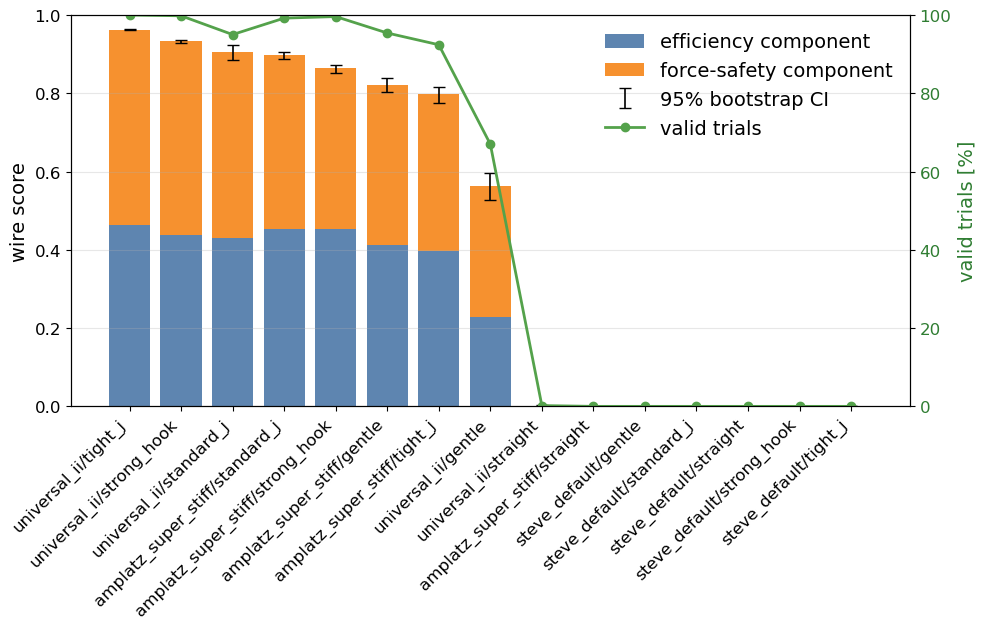

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_Tree_1047__target_000__bct_score_components_valid_trials.png`

In [23]:
# Extra component plot for the same selected anatomy-target:
# stacked bars show the score contribution from efficiency and force safety.
# The right y-axis shows the valid-trial percentage for each wire.

component_table_path = e2_bootstrap_output_path(E2_SCORE_PLOT_FAMILY)
if not component_table_path.exists():
    display(Markdown(f"Build the bootstrap table first: `{component_table_path}`"))
else:
    component_source = pd.read_csv(component_table_path)
    required_component_cols = ["observed_efficiency_component", "observed_safety_component", "valid_rate"]
    missing_component_cols = [col for col in required_component_cols if col not in component_source.columns]
    if missing_component_cols:
        display(Markdown(
            "The existing bootstrap table does not yet contain component columns. "
            "Set `E2_REBUILD_BOOTSTRAP = True` in the bootstrap build cell and rerun it for this family. "
            "Missing: `" + "`, `".join(missing_component_cols) + "`."
        ))
    else:
        anatomy_targets = sorted(component_source["anatomy_target_key"].dropna().unique())
        if "E2_SCORE_PLOT_ANATOMY_TARGET_KEY" in globals() and E2_SCORE_PLOT_ANATOMY_TARGET_KEY in anatomy_targets:
            selected_key = E2_SCORE_PLOT_ANATOMY_TARGET_KEY
            selected_index = anatomy_targets.index(selected_key)
        elif "E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX" in globals() and E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX:
            matching_keys = [key for key in anatomy_targets if str(key).startswith(E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX)]
            if not matching_keys:
                raise KeyError(f"No anatomy-target key starts with `{E2_SCORE_PLOT_ANATOMY_TARGET_KEY_PREFIX}`.")
            if len(matching_keys) > 1:
                print("Multiple matching anatomy-target keys; using the first:", matching_keys)
            selected_key = matching_keys[0]
            selected_index = anatomy_targets.index(selected_key)
        else:
            selected_index = int(E2_SCORE_PLOT_ANATOMY_TARGET_NUMBER)
            if selected_index < 0 or selected_index >= len(anatomy_targets):
                raise IndexError(f"Select a number from 0 to {len(anatomy_targets) - 1}.")
            selected_key = anatomy_targets[selected_index]

        E2_SCORE_PLOT_ANATOMY_TARGET_NUMBER = selected_index
        E2_SCORE_PLOT_ANATOMY_TARGET_KEY = selected_key

        def format_family_label(training_family):
            return {
                "non_force_aware": "non-force-aware",
                "force_aware": "force-aware",
            }.get(str(training_family), str(training_family).replace("_", "-"))

        def format_anatomy_target_label(anatomy_target_key):
            parts = str(anatomy_target_key).split("__")
            tree_label = parts[0].replace("_", " ") if len(parts) > 0 else str(anatomy_target_key)
            target_label = parts[1].replace("target_", "target ") if len(parts) > 1 else "target unknown"
            branch_label = parts[2].upper() if len(parts) > 2 else "branch unknown"
            return f"{tree_label}, {target_label} ({branch_label})"

        family_label = format_family_label(E2_SCORE_PLOT_FAMILY)
        anatomy_target_label = format_anatomy_target_label(selected_key)

        component_df = (
            component_source.loc[component_source["anatomy_target_key"].eq(selected_key)]
            .sort_values("observed_wire_score", ascending=False)
            .reset_index(drop=True)
        )
        component_df["label"] = component_df["execution_wire"].astype(str)
        component_df.loc[component_df["force_alpha"].notna(), "label"] = (
            component_df.loc[component_df["force_alpha"].notna(), "execution_wire"].astype(str)
            + " / "
            + component_df.loc[component_df["force_alpha"].notna(), "force_alpha"].astype(str)
        )
        component_df["valid_percent"] = 100.0 * component_df["valid_rate"]

        display(Markdown(f"### Component view: {family_label}, anatomy-target #{selected_index}: {anatomy_target_label}"))
        display(
            component_df[[
                "label",
                "observed_wire_score",
                "observed_efficiency_component",
                "observed_safety_component",
                "valid_percent",
                "ci_low",
                "ci_high",
            ]].round(4)
        )

        x = np.arange(len(component_df))
        efficiency = component_df["observed_efficiency_component"].to_numpy(dtype=float)
        safety = component_df["observed_safety_component"].to_numpy(dtype=float)
        total = component_df["observed_wire_score"].to_numpy(dtype=float)
        yerr = np.vstack([
            total - component_df["ci_low"].to_numpy(dtype=float),
            component_df["ci_high"].to_numpy(dtype=float) - total,
        ])

        fig, ax_score = plt.subplots(figsize=(max(10, len(component_df) * 0.6), 6.4))
        ax_score.bar(x, efficiency, label="efficiency component", color="#4C78A8", alpha=0.90)
        ax_score.bar(x, safety, bottom=efficiency, label="force-safety component", color="#F58518", alpha=0.90)
        ax_score.errorbar(x, total, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.2, capsize=4, label="95% bootstrap CI")
        ax_score.set_ylabel("wire score", fontsize=14)
        ax_score.set_ylim(0, min(1.0, max(0.2, float(component_df["ci_high"].max()) + 0.05)))
        ax_score.set_xticks(x)
        ax_score.set_xticklabels(component_df["label"], rotation=45, ha="right", fontsize=12)
        ax_score.tick_params(axis="both", labelsize=12)
        ax_score.grid(axis="y", alpha=0.3)

        ax_valid = ax_score.twinx()
        ax_valid.plot(x, component_df["valid_percent"], color="#54A24B", marker="o", linewidth=2, label="valid trials")
        ax_valid.set_ylabel("valid trials [%]", color="#2F7D32", fontsize=14)
        ax_valid.tick_params(axis="y", labelcolor="#2F7D32", labelsize=12)
        ax_valid.set_ylim(0, 100)

        lines_score, labels_score = ax_score.get_legend_handles_labels()
        lines_valid, labels_valid = ax_valid.get_legend_handles_labels()
        ax_score.legend(lines_score + lines_valid, labels_score + labels_valid, loc="upper right", fontsize=14, frameon=False)
        plt.tight_layout()

        figure_stem = f"e2_{E2_SCORE_PLOT_FAMILY}_{selected_key}_score_components_valid_trials"
        figure_stem = figure_stem.replace("/", "_").replace(" ", "_")
        figure_png = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.png"
        figure_pdf = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.pdf"
        fig.savefig(figure_png, dpi=200, bbox_inches="tight")
        fig.savefig(figure_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved figure: `{figure_png}`"))





### 3.2.0b Overall Efficiency-to-Force-Safety Component Ratio

This table summarizes how much of the E2 calibrated score comes from the efficiency component versus the force-safety component for each wire family, tip shape, and force-alpha setting. It uses the already generated per-anatomy-target score tables, so it does not reload the full trial caches. The component means are weighted by `n_trials_available`, which recovers the overall trial-level mean across all available trials for that candidate group. The 95% confidence interval is a percentile bootstrap over anatomy-target groups.


In [50]:
# Overall efficiency-to-force-safety component ratio per wire family, tip shape, and alpha.
# Uses the existing per-anatomy-target bootstrap score tables instead of loading the large trial caches.
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

try:
    E2_SCORE_OUTPUT_DIR
except NameError:
    E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E2_COMPONENT_RATIO_BOOT_N = 1000
E2_COMPONENT_RATIO_BOOT_SEED = 20260608

component_score_paths = {
    "non_force_aware": E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
    "force_aware": E2_SCORE_OUTPUT_DIR / "e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv",
}
missing_paths = [path for path in component_score_paths.values() if not path.exists()]

if missing_paths:
    display(Markdown("Build the E2 bootstrap score tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    component_frames = []
    for training_family, table_path in component_score_paths.items():
        frame = pd.read_csv(table_path)
        if "training_family" not in frame.columns:
            frame["training_family"] = training_family
        component_frames.append(frame)

    component_source = pd.concat(component_frames, ignore_index=True)
    component_source["force_alpha_label"] = component_source["force_alpha"].fillna("non_force")

    required_cols = [
        "training_family",
        "wire_model",
        "wire_shape",
        "force_alpha_label",
        "anatomy_target_key",
        "observed_efficiency_component",
        "observed_safety_component",
        "n_trials_available",
    ]
    missing_cols = [col for col in required_cols if col not in component_source.columns]

    if missing_cols:
        display(Markdown("Missing component columns: `" + "`, `".join(missing_cols) + "`. Rebuild the bootstrap score tables if needed."))
    else:
        component_source = component_source[required_cols].copy()
        numeric_cols = [
            "observed_efficiency_component",
            "observed_safety_component",
            "n_trials_available",
        ]
        for col in numeric_cols:
            component_source[col] = pd.to_numeric(component_source[col], errors="coerce")
        component_source = component_source.dropna(subset=numeric_cols)
        component_source = component_source.loc[component_source["n_trials_available"].gt(0)].copy()

        def weighted_component_mean(values: np.ndarray, weights: np.ndarray) -> float:
            return float(np.average(values, weights=weights)) if values.size else float("nan")

        def summarize_component_ratio(group: pd.DataFrame, *, seed: int) -> dict:
            eff = group["observed_efficiency_component"].to_numpy(dtype=float)
            safety = group["observed_safety_component"].to_numpy(dtype=float)
            weights = group["n_trials_available"].to_numpy(dtype=float)

            eff_mean = weighted_component_mean(eff, weights)
            safety_mean = weighted_component_mean(safety, weights)
            component_score_mean = eff_mean + safety_mean
            ratio = eff_mean / safety_mean if safety_mean > 0 else np.nan
            share = eff_mean / component_score_mean if component_score_mean > 0 else np.nan

            rng = np.random.default_rng(seed)
            sample_idx = rng.integers(0, len(group), size=(E2_COMPONENT_RATIO_BOOT_N, len(group)))
            boot_weights = weights[sample_idx]
            boot_eff = (eff[sample_idx] * boot_weights).sum(axis=1) / boot_weights.sum(axis=1)
            boot_safety = (safety[sample_idx] * boot_weights).sum(axis=1) / boot_weights.sum(axis=1)
            boot_score = boot_eff + boot_safety
            boot_ratio = np.divide(
                boot_eff,
                boot_safety,
                out=np.full_like(boot_eff, np.nan),
                where=boot_safety > 0,
            )
            boot_share = np.divide(
                boot_eff,
                boot_score,
                out=np.full_like(boot_eff, np.nan),
                where=boot_score > 0,
            )
            def finite_ci(values: np.ndarray) -> tuple:
                values = values[np.isfinite(values)]
                if values.size == 0:
                    return float("nan"), float("nan")
                return tuple(np.quantile(values, [0.025, 0.975]))

            eff_ci_low, eff_ci_high = finite_ci(boot_eff)
            safety_ci_low, safety_ci_high = finite_ci(boot_safety)
            score_ci_low, score_ci_high = finite_ci(boot_score)
            ratio_ci_low, ratio_ci_high = finite_ci(boot_ratio)
            share_ci_low, share_ci_high = finite_ci(boot_share)

            return {
                "n_anatomy_targets": int(group["anatomy_target_key"].nunique()),
                "n_component_rows": int(len(group)),
                "n_trials_total": int(weights.sum()),
                "efficiency_component_mean": eff_mean,
                "efficiency_component_mean_ci_low": float(eff_ci_low),
                "efficiency_component_mean_ci_high": float(eff_ci_high),
                "force_safety_component_mean": safety_mean,
                "force_safety_component_mean_ci_low": float(safety_ci_low),
                "force_safety_component_mean_ci_high": float(safety_ci_high),
                "component_score_mean": component_score_mean,
                "component_score_mean_ci_low": float(score_ci_low),
                "component_score_mean_ci_high": float(score_ci_high),
                "efficiency_to_safety_ratio": ratio,
                "efficiency_to_safety_ratio_ci_low": float(ratio_ci_low),
                "efficiency_to_safety_ratio_ci_high": float(ratio_ci_high),
                "efficiency_component_share": share,
                "efficiency_component_share_ci_low": float(share_ci_low),
                "efficiency_component_share_ci_high": float(share_ci_high),
            }

        rows = []
        group_cols = ["wire_model", "wire_shape", "force_alpha_label"]
        for group_index, (group_key, group) in enumerate(component_source.groupby(group_cols, dropna=False, sort=False)):
            row = dict(zip(group_cols, group_key))
            row.update(summarize_component_ratio(group, seed=E2_COMPONENT_RATIO_BOOT_SEED + group_index))
            rows.append(row)

        component_ratio_df = pd.DataFrame(rows)
        wire_model_order = ["amplatz_super_stiff", "universal_ii", "steve_default"]
        wire_shape_order = ["standard_j", "tight_j", "strong_hook", "gentle", "straight"]
        force_alpha_order = ["non_force", "a001", "a005", "a05"]
        component_ratio_df["wire_model_order"] = component_ratio_df["wire_model"].map({name: idx for idx, name in enumerate(wire_model_order)}).fillna(99)
        component_ratio_df["wire_shape_order"] = component_ratio_df["wire_shape"].map({name: idx for idx, name in enumerate(wire_shape_order)}).fillna(99)
        component_ratio_df["force_alpha_order"] = component_ratio_df["force_alpha_label"].map({name: idx for idx, name in enumerate(force_alpha_order)}).fillna(99)
        component_ratio_df = (
            component_ratio_df
            .sort_values(["wire_model_order", "wire_shape_order", "force_alpha_order", "wire_model", "wire_shape", "force_alpha_label"])
            .drop(columns=["wire_model_order", "wire_shape_order", "force_alpha_order"])
            .reset_index(drop=True)
        )

        component_ratio_csv = E2_SCORE_OUTPUT_DIR / "e2_overall_efficiency_force_safety_component_ratio_by_wire_alpha.csv"
        component_ratio_df.to_csv(component_ratio_csv, index=False)

        display(Markdown(f"Saved component-ratio table: `{component_ratio_csv}`"))
        display(
            component_ratio_df[[
                "wire_model",
                "wire_shape",
                "force_alpha_label",
                "n_anatomy_targets",
                "n_trials_total",
                "efficiency_component_mean",
                "efficiency_component_mean_ci_low",
                "efficiency_component_mean_ci_high",
                "force_safety_component_mean",
                "force_safety_component_mean_ci_low",
                "force_safety_component_mean_ci_high",
                "component_score_mean",
                "component_score_mean_ci_low",
                "component_score_mean_ci_high",
                "efficiency_to_safety_ratio",
                "efficiency_to_safety_ratio_ci_low",
                "efficiency_to_safety_ratio_ci_high",
                "efficiency_component_share",
                "efficiency_component_share_ci_low",
                "efficiency_component_share_ci_high",
            ]].round(4)
        )


        non_force_component_ci_df = (
            component_ratio_df
            .loc[component_ratio_df["force_alpha_label"].eq("non_force")]
            .copy()
        )
        family_label_map = {
            "steve_default": "stEVE default",
            "amplatz_super_stiff": "Amplatz Super Stiff",
            "universal_ii": "Universal II",
        }
        tip_shape_label_map = {
            "standard_j": "standard J",
            "tight_j": "tight J",
            "strong_hook": "strong hook",
            "gentle": "gentle",
            "straight": "straight",
        }
        latex_family_order = ["steve_default", "amplatz_super_stiff", "universal_ii"]
        latex_tip_order = ["standard_j", "tight_j", "strong_hook", "gentle", "straight"]
        non_force_component_ci_df["latex_family_order"] = non_force_component_ci_df["wire_model"].map({name: idx for idx, name in enumerate(latex_family_order)}).fillna(99)
        non_force_component_ci_df["latex_tip_order"] = non_force_component_ci_df["wire_shape"].map({name: idx for idx, name in enumerate(latex_tip_order)}).fillna(99)
        non_force_component_ci_df = (
            non_force_component_ci_df
            .sort_values(["latex_family_order", "latex_tip_order", "wire_model", "wire_shape"])
            .drop(columns=["latex_family_order", "latex_tip_order"])
            .reset_index(drop=True)
        )
        non_force_component_ci_df["Family"] = non_force_component_ci_df["wire_model"].map(family_label_map).fillna(non_force_component_ci_df["wire_model"])
        non_force_component_ci_df["Tip shape"] = non_force_component_ci_df["wire_shape"].map(tip_shape_label_map).fillna(non_force_component_ci_df["wire_shape"])

        def format_component_ci(row: pd.Series, prefix: str) -> str:
            mean = row[f"{prefix}_mean"]
            low = row[f"{prefix}_mean_ci_low"]
            high = row[f"{prefix}_mean_ci_high"]
            return f"${mean:.4f}$ [$${low:.4f}$, $${high:.4f}$]".replace("[$$", "[$").replace(", $$", ", $")

        def format_component_pm_ci(row: pd.Series, prefix: str) -> str:
            mean = row[f"{prefix}_mean"]
            low = row[f"{prefix}_mean_ci_low"]
            high = row[f"{prefix}_mean_ci_high"]
            half_width = (high - low) / 2.0
            return f"${mean:.4f} \pm {half_width:.4f}$"

        non_force_component_ci_df["mean efficiency component [CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_ci(row, "efficiency_component"),
            axis=1,
        )
        non_force_component_ci_df["mean safety component [CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_ci(row, "force_safety_component"),
            axis=1,
        )
        non_force_component_ci_df["mean score [CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_ci(row, "component_score"),
            axis=1,
        )
        non_force_component_ci_df["mean efficiency component [pm CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_pm_ci(row, "efficiency_component"),
            axis=1,
        )
        non_force_component_ci_df["mean safety component [pm CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_pm_ci(row, "force_safety_component"),
            axis=1,
        )
        non_force_component_ci_df["mean score [pm CI]"] = non_force_component_ci_df.apply(
            lambda row: format_component_pm_ci(row, "component_score"),
            axis=1,
        )

        non_force_component_ci_csv = E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_efficiency_safety_score_component_mean_ci_for_table.csv"
        non_force_component_ci_df.to_csv(non_force_component_ci_csv, index=False)

        display(Markdown(f"Saved non-force component CI table: `{non_force_component_ci_csv}`"))
        display(
            non_force_component_ci_df[[
                "Family",
                "Tip shape",
                "mean efficiency component [CI]",
                "mean safety component [CI]",
                "mean score [CI]",
            ]]
        )

        latex_component_rows = [
            f"{row['Family']} & {row['Tip shape']} & {row['mean efficiency component [CI]']} & {row['mean safety component [CI]']} & {row['mean score [CI]']} \\"
            for _, row in non_force_component_ci_df.iterrows()
        ]
        display(Markdown("#### LaTeX component columns for the non-force-aware table, full CI"))
        display(Markdown("```latex\n" + "\n".join(latex_component_rows) + "\n```"))

        latex_component_pm_rows = [
            f"{row['Family']} & {row['Tip shape']} & {row['mean efficiency component [pm CI]']} & {row['mean safety component [pm CI]']} & {row['mean score [pm CI]']} \\"
            for _, row in non_force_component_ci_df.iterrows()
        ]
        display(Markdown("#### LaTeX component columns for the non-force-aware table, mean $\pm$ half CI width"))
        display(Markdown("```latex\n" + "\n".join(latex_component_pm_rows) + "\n```"))


Saved component-ratio table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_overall_efficiency_force_safety_component_ratio_by_wire_alpha.csv`

,wire_model,wire_shape,force_alpha_label,n_anatomy_targets,n_trials_total,efficiency_component_mean,efficiency_component_mean_ci_low,efficiency_component_mean_ci_high,force_safety_component_mean,force_safety_component_mean_ci_low,force_safety_component_mean_ci_high,component_score_mean,component_score_mean_ci_low,component_score_mean_ci_high,efficiency_to_safety_ratio,efficiency_to_safety_ratio_ci_low,efficiency_to_safety_ratio_ci_high,efficiency_component_share,efficiency_component_share_ci_low,efficiency_component_share_ci_high
0,amplatz_super_stiff,standard_j,non_force,1700,850000,0.2894,0.2814,0.2978,0.3125,0.3048,0.3208,0.6019,0.5860,0.6188,0.9261,0.9199,0.9321,0.4808,0.4791,0.4824
1,amplatz_super_stiff,standard_j,a001,1700,850000,0.2105,0.2034,0.2174,0.2377,0.2305,0.2449,0.4482,0.4342,0.4626,0.8855,0.8770,0.8939,0.4696,0.4672,0.4720
2,amplatz_super_stiff,standard_j,a005,1700,850000,0.2506,0.2428,0.2587,0.2659,0.2579,0.2739,0.5165,0.5009,0.5322,0.9427,0.9358,0.9497,0.4852,0.4834,0.4871
3,amplatz_super_stiff,standard_j,a05,1700,850000,0.2399,0.2323,0.2480,0.2599,0.2521,0.2682,0.4998,0.4844,0.5163,0.9232,0.9175,0.9294,0.4800,0.4785,0.4817
4,amplatz_super_stiff,tight_j,non_force,1700,850000,0.2511,0.2433,0.2586,0.2719,0.2639,0.2794,0.5230,0.5074,0.5384,0.9236,0.9176,0.9300,0.4801,0.4785,0.4819
5,amplatz_super_stiff,strong_hook,non_force,1700,850000,0.2314,0.2226,0.2407,0.2211,0.2128,0.2294,0.4526,0.4354,0.4700,1.0465,1.0396,1.0536,0.5114,0.5097,0.5131
6,amplatz_super_stiff,gentle,non_force,1700,850000,0.1554,0.1479,0.1642,0.1686,0.1605,0.1780,0.3240,0.3086,0.3421,0.9219,0.9141,0.9295,0.4797,0.4776,0.4817
7,amplatz_super_stiff,straight,non_force,1700,850000,0.0830,0.0746,0.0913,0.0845,0.0756,0.0928,0.1675,0.1501,0.1840,0.9832,0.9725,0.9945,0.4958,0.4930,0.4986
8,universal_ii,standard_j,non_force,1700,850000,0.2338,0.2262,0.2412,0.2920,0.2838,0.3004,0.5257,0.5099,0.5409,0.8006,0.7948,0.8065,0.4446,0.4428,0.4465
9,universal_ii,standard_j,a001,1700,850000,0.2789,0.2709,0.2870,0.3394,0.3303,0.3482,0.6184,0.6013,0.6353,0.8217,0.8165,0.8266,0.4511,0.4495,0.4525


Saved non-force component CI table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_efficiency_safety_score_component_mean_ci_for_table.csv`

,Family,Tip shape,mean efficiency component [CI],mean safety component [CI],mean score [CI]
0,stEVE default,standard J,"$0.0016$ [$0.0009$, $0.0025$]","$0.0002$ [$0.0000$, $0.0003$]","$0.0017$ [$0.0010$, $0.0028$]"
1,stEVE default,tight J,"$0.0000$ [$0.0000$, $0.0001$]","$0.0000$ [$0.0000$, $0.0000$]","$0.0000$ [$0.0000$, $0.0001$]"
2,stEVE default,strong hook,"$0.0000$ [$0.0000$, $0.0000$]","$0.0000$ [$0.0000$, $0.0000$]","$0.0000$ [$0.0000$, $0.0000$]"
3,stEVE default,gentle,"$0.0008$ [$0.0004$, $0.0014$]","$0.0001$ [$0.0000$, $0.0002$]","$0.0009$ [$0.0004$, $0.0015$]"
4,stEVE default,straight,"$0.0019$ [$0.0008$, $0.0031$]","$0.0002$ [$0.0000$, $0.0005$]","$0.0021$ [$0.0009$, $0.0036$]"
5,Amplatz Super Stiff,standard J,"$0.2894$ [$0.2814$, $0.2978$]","$0.3125$ [$0.3048$, $0.3208$]","$0.6019$ [$0.5860$, $0.6188$]"
6,Amplatz Super Stiff,tight J,"$0.2511$ [$0.2433$, $0.2586$]","$0.2719$ [$0.2639$, $0.2794$]","$0.5230$ [$0.5074$, $0.5384$]"
7,Amplatz Super Stiff,strong hook,"$0.2314$ [$0.2226$, $0.2407$]","$0.2211$ [$0.2128$, $0.2294$]","$0.4526$ [$0.4354$, $0.4700$]"
8,Amplatz Super Stiff,gentle,"$0.1554$ [$0.1479$, $0.1642$]","$0.1686$ [$0.1605$, $0.1780$]","$0.3240$ [$0.3086$, $0.3421$]"
9,Amplatz Super Stiff,straight,"$0.0830$ [$0.0746$, $0.0913$]","$0.0845$ [$0.0756$, $0.0928$]","$0.1675$ [$0.1501$, $0.1840$]"


#### LaTeX component columns for the non-force-aware table, full CI

```latex
stEVE default & standard J & $0.0016$ [$0.0009$, $0.0025$] & $0.0002$ [$0.0000$, $0.0003$] & $0.0017$ [$0.0010$, $0.0028$] \
stEVE default & tight J & $0.0000$ [$0.0000$, $0.0001$] & $0.0000$ [$0.0000$, $0.0000$] & $0.0000$ [$0.0000$, $0.0001$] \
stEVE default & strong hook & $0.0000$ [$0.0000$, $0.0000$] & $0.0000$ [$0.0000$, $0.0000$] & $0.0000$ [$0.0000$, $0.0000$] \
stEVE default & gentle & $0.0008$ [$0.0004$, $0.0014$] & $0.0001$ [$0.0000$, $0.0002$] & $0.0009$ [$0.0004$, $0.0015$] \
stEVE default & straight & $0.0019$ [$0.0008$, $0.0031$] & $0.0002$ [$0.0000$, $0.0005$] & $0.0021$ [$0.0009$, $0.0036$] \
Amplatz Super Stiff & standard J & $0.2894$ [$0.2814$, $0.2978$] & $0.3125$ [$0.3048$, $0.3208$] & $0.6019$ [$0.5860$, $0.6188$] \
Amplatz Super Stiff & tight J & $0.2511$ [$0.2433$, $0.2586$] & $0.2719$ [$0.2639$, $0.2794$] & $0.5230$ [$0.5074$, $0.5384$] \
Amplatz Super Stiff & strong hook & $0.2314$ [$0.2226$, $0.2407$] & $0.2211$ [$0.2128$, $0.2294$] & $0.4526$ [$0.4354$, $0.4700$] \
Amplatz Super Stiff & gentle & $0.1554$ [$0.1479$, $0.1642$] & $0.1686$ [$0.1605$, $0.1780$] & $0.3240$ [$0.3086$, $0.3421$] \
Amplatz Super Stiff & straight & $0.0830$ [$0.0746$, $0.0913$] & $0.0845$ [$0.0756$, $0.0928$] & $0.1675$ [$0.1501$, $0.1840$] \
Universal II & standard J & $0.2338$ [$0.2262$, $0.2412$] & $0.2920$ [$0.2838$, $0.3004$] & $0.5257$ [$0.5099$, $0.5409$] \
Universal II & tight J & $0.2184$ [$0.2106$, $0.2261$] & $0.2865$ [$0.2774$, $0.2958$] & $0.5049$ [$0.4882$, $0.5216$] \
Universal II & strong hook & $0.1810$ [$0.1721$, $0.1895$] & $0.2314$ [$0.2209$, $0.2416$] & $0.4124$ [$0.3930$, $0.4309$] \
Universal II & gentle & $0.1557$ [$0.1466$, $0.1639$] & $0.2038$ [$0.1932$, $0.2141$] & $0.3595$ [$0.3402$, $0.3780$] \
Universal II & straight & $0.0926$ [$0.0849$, $0.1002$] & $0.1071$ [$0.0986$, $0.1157$] & $0.1997$ [$0.1834$, $0.2159$] \
```

#### LaTeX component columns for the non-force-aware table, mean $\pm$ half CI width

```latex
stEVE default & standard J & $0.0016 \pm 0.0008$ & $0.0002 \pm 0.0002$ & $0.0017 \pm 0.0009$ \
stEVE default & tight J & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ \
stEVE default & strong hook & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ \
stEVE default & gentle & $0.0008 \pm 0.0005$ & $0.0001 \pm 0.0001$ & $0.0009 \pm 0.0006$ \
stEVE default & straight & $0.0019 \pm 0.0011$ & $0.0002 \pm 0.0002$ & $0.0021 \pm 0.0014$ \
Amplatz Super Stiff & standard J & $0.2894 \pm 0.0082$ & $0.3125 \pm 0.0080$ & $0.6019 \pm 0.0164$ \
Amplatz Super Stiff & tight J & $0.2511 \pm 0.0076$ & $0.2719 \pm 0.0077$ & $0.5230 \pm 0.0155$ \
Amplatz Super Stiff & strong hook & $0.2314 \pm 0.0090$ & $0.2211 \pm 0.0083$ & $0.4526 \pm 0.0173$ \
Amplatz Super Stiff & gentle & $0.1554 \pm 0.0082$ & $0.1686 \pm 0.0088$ & $0.3240 \pm 0.0168$ \
Amplatz Super Stiff & straight & $0.0830 \pm 0.0084$ & $0.0845 \pm 0.0086$ & $0.1675 \pm 0.0169$ \
Universal II & standard J & $0.2338 \pm 0.0075$ & $0.2920 \pm 0.0083$ & $0.5257 \pm 0.0155$ \
Universal II & tight J & $0.2184 \pm 0.0077$ & $0.2865 \pm 0.0092$ & $0.5049 \pm 0.0167$ \
Universal II & strong hook & $0.1810 \pm 0.0087$ & $0.2314 \pm 0.0103$ & $0.4124 \pm 0.0190$ \
Universal II & gentle & $0.1557 \pm 0.0087$ & $0.2038 \pm 0.0105$ & $0.3595 \pm 0.0189$ \
Universal II & straight & $0.0926 \pm 0.0077$ & $0.1071 \pm 0.0085$ & $0.1997 \pm 0.0163$ \
```

### 3.2.1 Overall Wire Score Across Anatomy-Target Groups

This analysis aggregates the per-anatomy-target wire scores over all E2 anatomy-target combinations. For each candidate wire, the mean score is bootstrapped by resampling anatomy-target groups with replacement. The table reports the score range, mean, median, and the 95% bootstrap confidence interval of the mean score.


### Overall wire score across anatomy-target groups: non_force_aware

Saved table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_overall_wire_score_bootstrap_mean_ci.csv`

,training_family,candidate_key,label,execution_wire,force_alpha,n_anatomy_targets,min_score,max_score,mean_score,median_score,mean_score_ci_low,mean_score_ci_high,mean_score_ci_half_width
0,non_force_aware,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,1700,0.0,0.9541,0.6019,0.7675,0.5855,0.6174,0.0159
1,non_force_aware,non_force_aware::universal_ii/standard_j,universal_ii/standard_j,universal_ii/standard_j,NaN,1700,0.0,0.9708,0.5257,0.5581,0.5092,0.5420,0.0164
2,non_force_aware,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,NaN,1700,0.0,0.9499,0.5230,0.6192,0.5077,0.5380,0.0151
3,non_force_aware,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,universal_ii/tight_j,NaN,1700,0.0,0.9639,0.5049,0.5782,0.4877,0.5221,0.0172
4,non_force_aware,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,NaN,1700,0.0,0.9223,0.4526,0.5634,0.4358,0.4693,0.0167
5,non_force_aware,non_force_aware::universal_ii/strong_hook,universal_ii/strong_hook,universal_ii/strong_hook,NaN,1700,0.0,0.9574,0.4124,0.3041,0.3938,0.4307,0.0185
6,non_force_aware,non_force_aware::universal_ii/gentle,universal_ii/gentle,universal_ii/gentle,NaN,1700,0.0,0.9662,0.3595,0.1308,0.3411,0.3779,0.0184
7,non_force_aware,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,1700,0.0,0.9588,0.3240,0.1427,0.3074,0.3410,0.0168
8,non_force_aware,non_force_aware::universal_ii/straight,universal_ii/straight,universal_ii/straight,NaN,1700,0.0,0.9718,0.1997,0.0000,0.1829,0.2172,0.0171
9,non_force_aware,non_force_aware::amplatz_super_stiff/straight,amplatz_super_stiff/straight,amplatz_super_stiff/straight,NaN,1700,0.0,0.9656,0.1675,0.0000,0.1508,0.1835,0.0164


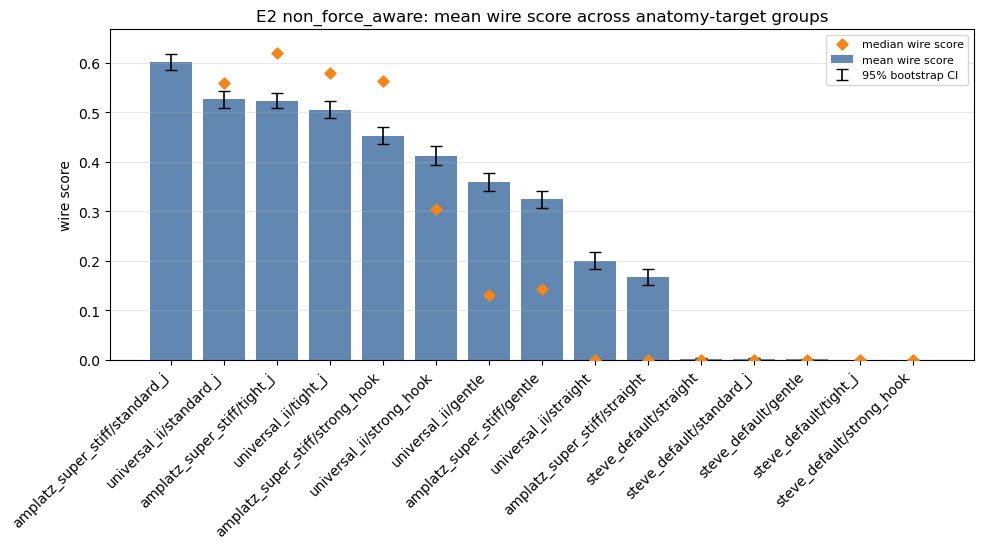

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_overall_wire_score_bootstrap_mean_ci.png`

In [24]:
# Overall wire score across all anatomy-target groups.
# This uses the per-wire/per-anatomy-target bootstrap table from section 3.2.
# It does not load the full trial table.
E2_OVERALL_WIRE_SCORE_FAMILY = "non_force_aware"  # options: "force_aware", "non_force_aware"
E2_OVERALL_WIRE_SCORE_BOOT_N = 10000
E2_OVERALL_WIRE_SCORE_BOOT_SEED = 123

score_table_path = e2_bootstrap_output_path(E2_OVERALL_WIRE_SCORE_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    score_df = pd.read_csv(score_table_path)
    required_cols = {"candidate_key", "execution_wire", "anatomy_target_key", "observed_wire_score", "force_alpha"}
    missing_cols = sorted(required_cols - set(score_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        rng = np.random.default_rng(E2_OVERALL_WIRE_SCORE_BOOT_SEED)
        rows = []
        for candidate_key, group in score_df.groupby("candidate_key", dropna=False):
            values = pd.to_numeric(group["observed_wire_score"], errors="coerce").dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            sample_idx = rng.integers(0, len(values), size=(E2_OVERALL_WIRE_SCORE_BOOT_N, len(values)))
            boot_mean = values[sample_idx].mean(axis=1)

            execution_wire = group["execution_wire"].dropna().astype(str).iloc[0] if group["execution_wire"].notna().any() else str(candidate_key)
            force_alpha_values = group["force_alpha"].dropna().unique()
            force_alpha = force_alpha_values[0] if len(force_alpha_values) else np.nan
            label = execution_wire if pd.isna(force_alpha) else f"{execution_wire} / {force_alpha}"

            rows.append({
                "training_family": E2_OVERALL_WIRE_SCORE_FAMILY,
                "candidate_key": candidate_key,
                "label": label,
                "execution_wire": execution_wire,
                "force_alpha": force_alpha,
                "n_anatomy_targets": int(len(values)),
                "min_score": float(np.min(values)),
                "max_score": float(np.max(values)),
                "mean_score": float(np.mean(values)),
                "median_score": float(np.median(values)),
                "mean_score_ci_low": float(np.quantile(boot_mean, 0.025)),
                "mean_score_ci_high": float(np.quantile(boot_mean, 0.975)),
                "mean_score_ci_half_width": float((np.quantile(boot_mean, 0.975) - np.quantile(boot_mean, 0.025)) / 2.0),
            })

        overall_wire_score_df = (
            pd.DataFrame(rows)
            .sort_values("mean_score", ascending=False)
            .reset_index(drop=True)
        )

        overall_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_OVERALL_WIRE_SCORE_FAMILY}_overall_wire_score_bootstrap_mean_ci.csv"
        overall_wire_score_df.to_csv(overall_csv, index=False)

        display(Markdown(f"### Overall wire score across anatomy-target groups: {E2_OVERALL_WIRE_SCORE_FAMILY}"))
        display(Markdown(f"Saved table: `{overall_csv}`"))
        display(overall_wire_score_df.round(4))

        x = np.arange(len(overall_wire_score_df))
        y = overall_wire_score_df["mean_score"].to_numpy(dtype=float)
        yerr = np.vstack([
            y - overall_wire_score_df["mean_score_ci_low"].to_numpy(dtype=float),
            overall_wire_score_df["mean_score_ci_high"].to_numpy(dtype=float) - y,
        ])

        fig, ax = plt.subplots(figsize=(max(10, len(overall_wire_score_df) * 0.62), 5.6))
        ax.bar(x, y, color="#4C78A8", alpha=0.88, label="mean wire score")
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.2, capsize=4, label="95% bootstrap CI")
        ax.scatter(x, overall_wire_score_df["median_score"], color="#F58518", marker="D", s=32, label="median wire score", zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(overall_wire_score_df["label"], rotation=45, ha="right")
        ax.set_ylabel("wire score")
        ax.set_ylim(0, min(1.0, max(0.2, float(overall_wire_score_df["mean_score_ci_high"].max()) + 0.05)))
        ax.set_title(f"E2 {E2_OVERALL_WIRE_SCORE_FAMILY}: mean wire score across anatomy-target groups")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)
        plt.tight_layout()

        figure_stem = f"e2_{E2_OVERALL_WIRE_SCORE_FAMILY}_overall_wire_score_bootstrap_mean_ci"
        figure_png = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.png"
        figure_pdf = E2_SCORE_OUTPUT_DIR / f"{figure_stem}.pdf"
        fig.savefig(figure_png, dpi=200, bbox_inches="tight")
        fig.savefig(figure_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved figure: `{figure_png}`"))



### 3.2.2 Overall Wire Score by Target Branch

This branch-wise analysis repeats the overall wire-score aggregation separately for each target branch. The mean score is bootstrapped by resampling anatomy-target groups with replacement within each wire-branch group.


### Overall wire score by target branch: non_force_aware

Saved table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_score_by_branch_bootstrap_mean_ci.csv`

,training_family,branch,candidate_key,label,execution_wire,force_alpha,n_anatomy_targets,min_score,max_score,mean_score,median_score,mean_score_ci_low,mean_score_ci_high,mean_score_ci_half_width
0,non_force_aware,bct,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,universal_ii/tight_j,NaN,340,0.0,0.9630,0.8561,0.9052,0.8394,0.8716,0.0161
1,non_force_aware,bct,non_force_aware::universal_ii/strong_hook,universal_ii/strong_hook,universal_ii/strong_hook,NaN,340,0.0,0.9574,0.8039,0.8947,0.7787,0.8273,0.0243
2,non_force_aware,bct,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,340,0.0,0.9338,0.7915,0.8509,0.7704,0.8114,0.0205
3,non_force_aware,bct,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,NaN,340,0.0,0.9053,0.7597,0.8138,0.7406,0.7775,0.0185
4,non_force_aware,bct,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,NaN,340,0.0,0.9037,0.7076,0.8056,0.6832,0.7320,0.0244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,non_force_aware,rsa,non_force_aware::steve_default/standard_j,steve_default/standard_j,steve_default/standard_j,NaN,340,0.0,0.0152,0.0000,0.0000,0.0000,0.0001,0.0001
71,non_force_aware,rsa,non_force_aware::steve_default/gentle,steve_default/gentle,steve_default/gentle,NaN,340,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
72,non_force_aware,rsa,non_force_aware::steve_default/straight,steve_default/straight,steve_default/straight,NaN,340,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
73,non_force_aware,rsa,non_force_aware::steve_default/strong_hook,steve_default/strong_hook,steve_default/strong_hook,NaN,340,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


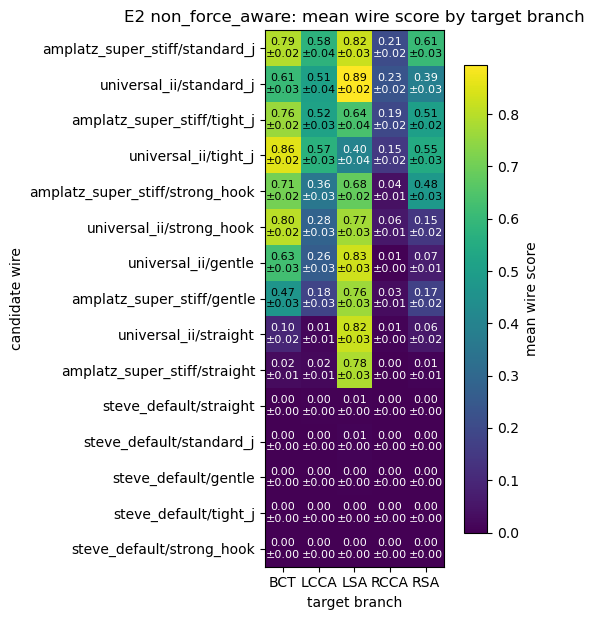

Saved heatmap: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_score_by_branch_heatmap.png`

### Top three wires per branch

,branch,label,mean_score,mean_score_ci_low,mean_score_ci_high,median_score,min_score,max_score,n_anatomy_targets
0,bct,universal_ii/tight_j,0.8561,0.8394,0.8716,0.9052,0.0,0.9630,340
1,bct,universal_ii/strong_hook,0.8039,0.7787,0.8273,0.8947,0.0,0.9574,340
2,bct,amplatz_super_stiff/standard_j,0.7915,0.7704,0.8114,0.8509,0.0,0.9338,340
3,lcca,amplatz_super_stiff/standard_j,0.5779,0.5417,0.6148,0.7655,0.0,0.9300,340
4,lcca,universal_ii/tight_j,0.5728,0.5375,0.6071,0.6750,0.0,0.9541,340
5,lcca,amplatz_super_stiff/tight_j,0.5171,0.4822,0.5517,0.6842,0.0,0.8986,340
6,lsa,universal_ii/standard_j,0.8949,0.8783,0.9096,0.9484,0.0,0.9708,340
7,lsa,universal_ii/gentle,0.8306,0.8036,0.8567,0.9389,0.0,0.9662,340
8,lsa,amplatz_super_stiff/standard_j,0.8241,0.7974,0.8486,0.9067,0.0,0.9541,340
9,rcca,universal_ii/standard_j,0.2308,0.2094,0.2526,0.1908,0.0,0.9104,340


In [25]:
# Overall wire score by target branch.
# This uses the per-wire/per-anatomy-target score table from section 3.2.
E2_BRANCH_WIRE_SCORE_FAMILY = E2_OVERALL_WIRE_SCORE_FAMILY if "E2_OVERALL_WIRE_SCORE_FAMILY" in globals() else "non_force_aware"
E2_BRANCH_WIRE_SCORE_BOOT_N = E2_OVERALL_WIRE_SCORE_BOOT_N if "E2_OVERALL_WIRE_SCORE_BOOT_N" in globals() else 10000
E2_BRANCH_WIRE_SCORE_BOOT_SEED = E2_OVERALL_WIRE_SCORE_BOOT_SEED if "E2_OVERALL_WIRE_SCORE_BOOT_SEED" in globals() else 123

score_table_path = e2_bootstrap_output_path(E2_BRANCH_WIRE_SCORE_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    score_df = pd.read_csv(score_table_path)
    if "branch" not in score_df.columns:
        if "anatomy_target_key" in score_df.columns:
            score_df["branch"] = score_df["anatomy_target_key"].astype(str).str.split("__").str[-1]
        else:
            raise KeyError("The score table needs either `branch` or `anatomy_target_key`.")

    required_cols = {"candidate_key", "execution_wire", "branch", "anatomy_target_key", "observed_wire_score", "force_alpha"}
    missing_cols = sorted(required_cols - set(score_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        rng = np.random.default_rng(E2_BRANCH_WIRE_SCORE_BOOT_SEED)
        rows = []
        for (candidate_key, branch), group in score_df.groupby(["candidate_key", "branch"], dropna=False):
            values = pd.to_numeric(group["observed_wire_score"], errors="coerce").dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue
            sample_idx = rng.integers(0, len(values), size=(E2_BRANCH_WIRE_SCORE_BOOT_N, len(values)))
            boot_mean = values[sample_idx].mean(axis=1)

            execution_wire = group["execution_wire"].dropna().astype(str).iloc[0] if group["execution_wire"].notna().any() else str(candidate_key)
            force_alpha_values = group["force_alpha"].dropna().unique()
            force_alpha = force_alpha_values[0] if len(force_alpha_values) else np.nan
            label = execution_wire if pd.isna(force_alpha) else f"{execution_wire} / {force_alpha}"

            rows.append({
                "training_family": E2_BRANCH_WIRE_SCORE_FAMILY,
                "branch": branch,
                "candidate_key": candidate_key,
                "label": label,
                "execution_wire": execution_wire,
                "force_alpha": force_alpha,
                "n_anatomy_targets": int(len(values)),
                "min_score": float(np.min(values)),
                "max_score": float(np.max(values)),
                "mean_score": float(np.mean(values)),
                "median_score": float(np.median(values)),
                "mean_score_ci_low": float(np.quantile(boot_mean, 0.025)),
                "mean_score_ci_high": float(np.quantile(boot_mean, 0.975)),
                "mean_score_ci_half_width": float((np.quantile(boot_mean, 0.975) - np.quantile(boot_mean, 0.025)) / 2.0),
            })

        branch_wire_score_df = (
            pd.DataFrame(rows)
            .sort_values(["branch", "mean_score"], ascending=[True, False])
            .reset_index(drop=True)
        )

        branch_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_WIRE_SCORE_FAMILY}_wire_score_by_branch_bootstrap_mean_ci.csv"
        branch_wire_score_df.to_csv(branch_csv, index=False)

        display(Markdown(f"### Overall wire score by target branch: {E2_BRANCH_WIRE_SCORE_FAMILY}"))
        display(Markdown(f"Saved table: `{branch_csv}`"))
        display(branch_wire_score_df.round(4))

        branch_order = sorted(branch_wire_score_df["branch"].dropna().unique())
        label_order = (
            branch_wire_score_df
            .groupby("label", dropna=False)["mean_score"]
            .mean()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
        heatmap_df = (
            branch_wire_score_df
            .pivot(index="label", columns="branch", values="mean_score")
            .reindex(index=label_order, columns=branch_order)
        )
        ci_half_df = (
            branch_wire_score_df
            .pivot(index="label", columns="branch", values="mean_score_ci_half_width")
            .reindex(index=label_order, columns=branch_order)
        )

        fig, ax = plt.subplots(figsize=(max(7.5, len(branch_order) * 1.4), max(5.5, len(label_order) * 0.42)))
        im = ax.imshow(heatmap_df.to_numpy(dtype=float), cmap="viridis", vmin=0.0, vmax=max(0.2, float(np.nanmax(heatmap_df.to_numpy(dtype=float)))))
        ax.set_xticks(np.arange(len(branch_order)))
        ax.set_xticklabels([str(branch).upper() for branch in branch_order])
        ax.set_yticks(np.arange(len(label_order)))
        ax.set_yticklabels(label_order)
        ax.set_xlabel("target branch")
        ax.set_ylabel("candidate wire")
        ax.set_title(f"E2 {E2_BRANCH_WIRE_SCORE_FAMILY}: mean wire score by target branch")

        for row_idx, label in enumerate(label_order):
            for col_idx, branch in enumerate(branch_order):
                value = heatmap_df.loc[label, branch]
                ci_half = ci_half_df.loc[label, branch]
                if pd.isna(value):
                    text = ""
                else:
                    text = f"{value:.2f}\n±{ci_half:.2f}"
                ax.text(col_idx, row_idx, text, ha="center", va="center", color="white" if value < 0.45 else "black", fontsize=8)

        cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("mean wire score")
        fig.tight_layout()

        heatmap_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_WIRE_SCORE_FAMILY}_wire_score_by_branch_heatmap.png"
        heatmap_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_WIRE_SCORE_FAMILY}_wire_score_by_branch_heatmap.pdf"
        fig.savefig(heatmap_png, dpi=200, bbox_inches="tight")
        fig.savefig(heatmap_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved heatmap: `{heatmap_png}`"))

        top_by_branch = (
            branch_wire_score_df
            .sort_values(["branch", "mean_score"], ascending=[True, False])
            .groupby("branch", dropna=False)
            .head(3)
            .loc[:, ["branch", "label", "mean_score", "mean_score_ci_low", "mean_score_ci_high", "median_score", "min_score", "max_score", "n_anatomy_targets"]]
            .reset_index(drop=True)
        )
        display(Markdown("### Top three wires per branch"))
        display(top_by_branch.round(4))




### 3.2.3 Distribution of Wire Ranking Positions

Plan:

1. Use the per-wire/per-anatomy-target score table from section 3.2.
2. For each anatomy-target group, rank all candidate wires by `observed_wire_score`, with rank 1 being the highest score.
3. Use average ranks for exact score ties, so fully tied candidates receive the same middle rank instead of arbitrarily breaking ties.
4. Summarize the rank distribution per wire in a table.
5. Plot the rank distribution as a box plot. Lower rank values are better.


### Wire ranking-position distribution: non_force_aware

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution.csv`

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_detail.csv`

,candidate_key,label,execution_wire,force_alpha,n_anatomy_targets,min_rank,q25_rank,median_rank,mean_rank,q75_rank,max_rank,top_rank_rate_percent,mean_score
0,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,1700,1.0,2.0,3.0,3.637,5.0,12.0,19.647,0.602
1,non_force_aware::universal_ii/standard_j,universal_ii/standard_j,universal_ii/standard_j,NaN,1700,1.0,2.0,3.0,3.735,5.0,12.0,16.471,0.526
2,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,universal_ii/tight_j,NaN,1700,1.0,1.0,3.0,3.940,5.0,13.0,29.471,0.505
3,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,NaN,1700,1.0,3.0,4.0,4.565,6.0,13.0,7.588,0.523
4,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,NaN,1700,1.0,4.0,6.0,5.905,8.0,12.0,3.294,0.453
5,non_force_aware::universal_ii/strong_hook,universal_ii/strong_hook,universal_ii/strong_hook,NaN,1700,1.0,4.0,6.0,5.925,8.0,12.0,6.824,0.412
6,non_force_aware::universal_ii/gentle,universal_ii/gentle,universal_ii/gentle,NaN,1700,1.0,4.0,7.0,6.826,9.0,12.5,1.294,0.359
7,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,1700,1.0,6.0,7.0,7.263,8.0,12.5,0.235,0.324
8,non_force_aware::universal_ii/straight,universal_ii/straight,universal_ii/straight,NaN,1700,1.0,8.0,10.5,8.841,12.0,13.5,14.176,0.200
9,non_force_aware::amplatz_super_stiff/straight,amplatz_super_stiff/straight,amplatz_super_stiff/straight,NaN,1700,1.0,9.0,11.5,9.964,12.0,13.5,0.235,0.168


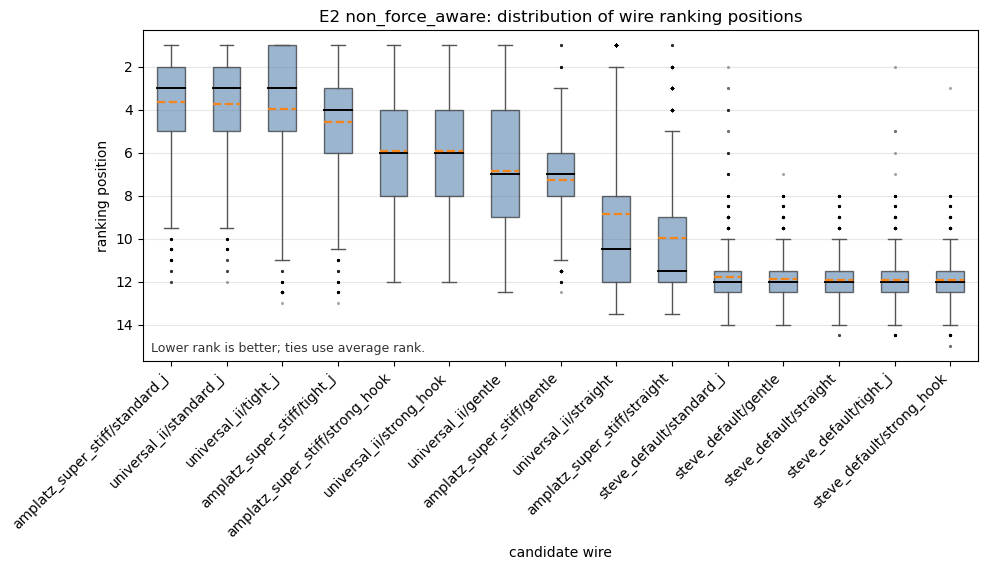

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_boxplot.png`

In [26]:
# Distribution of wire ranking positions across anatomy-target groups.
# Lower rank is better. Rank 1 is the highest-scoring wire within one anatomy-target group.
E2_RANK_DISTRIBUTION_FAMILY = "non_force_aware"  # options: "force_aware", "non_force_aware"

score_table_path = e2_bootstrap_output_path(E2_RANK_DISTRIBUTION_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    score_df = pd.read_csv(score_table_path)
    required_cols = {"anatomy_target_key", "candidate_key", "execution_wire", "force_alpha", "observed_wire_score"}
    missing_cols = sorted(required_cols - set(score_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        rank_df = score_df.copy()
        rank_df["observed_wire_score"] = pd.to_numeric(rank_df["observed_wire_score"], errors="coerce")
        rank_df["rank_position"] = (
            rank_df
            .groupby("anatomy_target_key", dropna=False)["observed_wire_score"]
            .rank(method="average", ascending=False)
        )
        rank_df["is_top_rank"] = rank_df["rank_position"].eq(1.0)

        rank_df["label"] = rank_df["execution_wire"].astype(str)
        force_mask = rank_df["force_alpha"].notna()
        rank_df.loc[force_mask, "label"] = (
            rank_df.loc[force_mask, "execution_wire"].astype(str)
            + " / "
            + rank_df.loc[force_mask, "force_alpha"].astype(str)
        )

        rank_summary_df = (
            rank_df
            .groupby(["candidate_key", "label", "execution_wire", "force_alpha"], dropna=False)
            .agg(
                n_anatomy_targets=("anatomy_target_key", "nunique"),
                min_rank=("rank_position", "min"),
                q25_rank=("rank_position", lambda s: float(s.quantile(0.25))),
                median_rank=("rank_position", "median"),
                mean_rank=("rank_position", "mean"),
                q75_rank=("rank_position", lambda s: float(s.quantile(0.75))),
                max_rank=("rank_position", "max"),
                top_rank_rate_percent=("is_top_rank", lambda s: 100.0 * float(s.mean())),
                mean_score=("observed_wire_score", "mean"),
            )
            .reset_index()
            .sort_values(["median_rank", "mean_rank", "mean_score"], ascending=[True, True, False])
            .reset_index(drop=True)
        )

        rank_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution.csv"
        rank_detail_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_detail.csv"
        rank_summary_df.to_csv(rank_csv, index=False)
        rank_df.to_csv(rank_detail_csv, index=False)

        display(Markdown(f"### Wire ranking-position distribution: {E2_RANK_DISTRIBUTION_FAMILY}"))
        display(Markdown(f"Saved summary table: `{rank_csv}`"))
        display(Markdown(f"Saved detail table: `{rank_detail_csv}`"))
        display(rank_summary_df.round(3))

        plot_order = rank_summary_df["label"].tolist()
        plot_data = [
            rank_df.loc[rank_df["label"].eq(label), "rank_position"].dropna().to_numpy(dtype=float)
            for label in plot_order
        ]

        fig, ax = plt.subplots(figsize=(max(10, len(plot_order) * 0.62), 5.8))
        ax.boxplot(
            plot_data,
            labels=plot_order,
            showmeans=True,
            meanline=True,
            patch_artist=True,
            boxprops={"facecolor": "#4C78A8", "alpha": 0.55},
            medianprops={"color": "black", "linewidth": 1.4},
            meanprops={"color": "#F58518", "linewidth": 1.6},
            whiskerprops={"color": "#555555"},
            capprops={"color": "#555555"},
            flierprops={"marker": ".", "markersize": 2.5, "alpha": 0.35},
        )
        ax.set_xticklabels(plot_order, rotation=45, ha="right")
        ax.set_ylabel("ranking position")
        ax.set_xlabel("candidate wire")
        ax.set_title(f"E2 {E2_RANK_DISTRIBUTION_FAMILY}: distribution of wire ranking positions")
        ax.invert_yaxis()
        ax.grid(axis="y", alpha=0.3)
        ax.text(
            0.01,
            0.02,
            "Lower rank is better; ties use average rank.",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
            color="#333333",
        )
        fig.tight_layout()

        figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_boxplot.png"
        figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_boxplot.pdf"
        fig.savefig(figure_png, dpi=200, bbox_inches="tight")
        fig.savefig(figure_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved figure: `{figure_png}`"))



### 3.2.4 Ranking-Position Distribution Without Equal-Score Groups

This repeats the ranking-position analysis after excluding anatomy-target groups where all candidate wires have the same observed score. These cases create non-informative rank ties, often because all candidate scores are zero.


### Wire ranking-position distribution without equal-score groups: non_force_aware

Removed **13** of **1700** anatomy-target groups (0.76%) where all candidate wire scores were equal.

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_without_equal_scores.csv`

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_without_equal_scores_detail.csv`

,candidate_key,label,execution_wire,force_alpha,n_anatomy_targets,min_rank,q25_rank,median_rank,mean_rank,q75_rank,max_rank,top_rank_rate_percent,mean_score
0,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,1687,1.0,2.0,3.0,3.603,5.0,12.0,19.798,0.607
1,non_force_aware::universal_ii/standard_j,universal_ii/standard_j,universal_ii/standard_j,NaN,1687,1.0,2.0,3.0,3.702,5.0,12.0,16.598,0.530
2,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,universal_ii/tight_j,NaN,1687,1.0,1.0,3.0,3.909,5.0,13.0,29.698,0.509
3,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,NaN,1687,1.0,3.0,4.0,4.539,6.0,13.0,7.647,0.527
4,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,NaN,1687,1.0,4.0,6.0,5.889,8.0,12.0,3.320,0.456
5,non_force_aware::universal_ii/strong_hook,universal_ii/strong_hook,universal_ii/strong_hook,NaN,1687,1.0,4.0,6.0,5.909,8.0,12.0,6.876,0.416
6,non_force_aware::universal_ii/gentle,universal_ii/gentle,universal_ii/gentle,NaN,1687,1.0,4.0,7.0,6.817,9.0,12.5,1.304,0.362
7,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,1687,1.0,6.0,7.0,7.257,8.0,12.5,0.237,0.327
8,non_force_aware::universal_ii/straight,universal_ii/straight,universal_ii/straight,NaN,1687,1.0,8.0,10.5,8.848,12.0,13.5,14.286,0.201
9,non_force_aware::amplatz_super_stiff/straight,amplatz_super_stiff/straight,amplatz_super_stiff/straight,NaN,1687,1.0,9.0,11.5,9.979,12.0,13.5,0.237,0.169


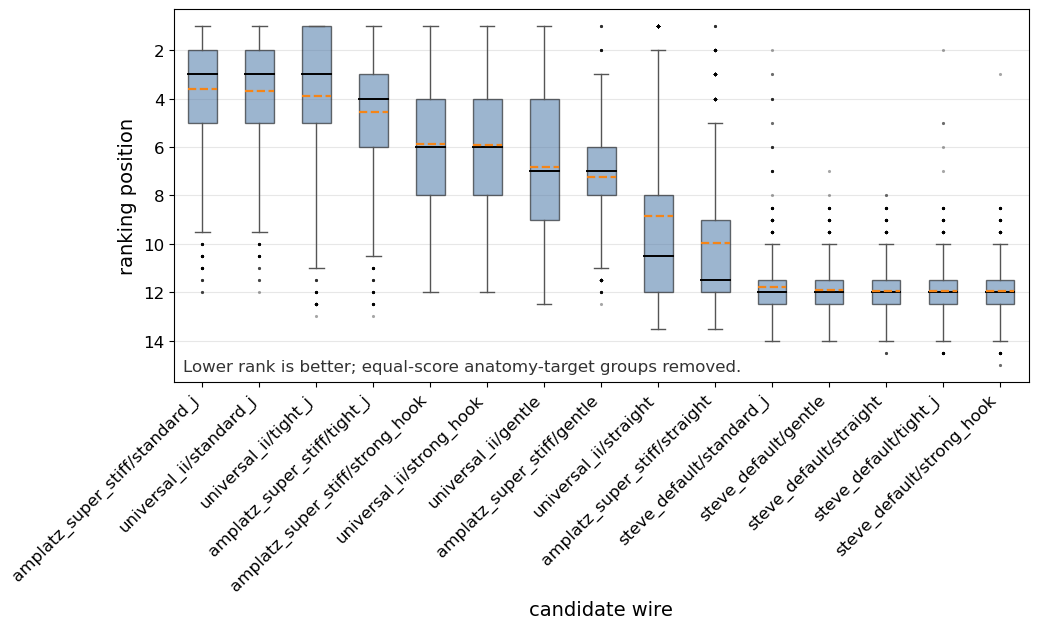

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_without_equal_scores_boxplot.png`

In [38]:
# Filtered distribution of wire ranking positions.
# Excludes anatomy-target groups where all candidate wires have exactly the same observed score.
E2_FILTERED_RANK_DISTRIBUTION_FAMILY = E2_RANK_DISTRIBUTION_FAMILY if "E2_RANK_DISTRIBUTION_FAMILY" in globals() else "non_force_aware"
E2_EQUAL_SCORE_TOLERANCE = 1e-12

score_table_path = e2_bootstrap_output_path(E2_FILTERED_RANK_DISTRIBUTION_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    score_df = pd.read_csv(score_table_path)
    required_cols = {"anatomy_target_key", "candidate_key", "execution_wire", "force_alpha", "observed_wire_score"}
    missing_cols = sorted(required_cols - set(score_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        score_df = score_df.copy()
        score_df["observed_wire_score"] = pd.to_numeric(score_df["observed_wire_score"], errors="coerce")

        score_range_df = (
            score_df
            .groupby("anatomy_target_key", dropna=False)
            .agg(
                min_score=("observed_wire_score", "min"),
                max_score=("observed_wire_score", "max"),
                n_candidates=("candidate_key", "nunique"),
            )
            .reset_index()
        )
        score_range_df["score_range"] = score_range_df["max_score"] - score_range_df["min_score"]
        equal_score_keys = set(
            score_range_df.loc[score_range_df["score_range"].abs().le(E2_EQUAL_SCORE_TOLERANCE), "anatomy_target_key"]
        )

        filtered_rank_df = score_df.loc[~score_df["anatomy_target_key"].isin(equal_score_keys)].copy()
        removed_groups = len(equal_score_keys)
        total_groups = score_df["anatomy_target_key"].nunique()
        removed_percent = 100.0 * removed_groups / total_groups if total_groups else np.nan

        filtered_rank_df["rank_position"] = (
            filtered_rank_df
            .groupby("anatomy_target_key", dropna=False)["observed_wire_score"]
            .rank(method="average", ascending=False)
        )
        filtered_rank_df["is_top_rank"] = filtered_rank_df["rank_position"].eq(1.0)

        filtered_rank_df["label"] = filtered_rank_df["execution_wire"].astype(str)
        force_mask = filtered_rank_df["force_alpha"].notna()
        filtered_rank_df.loc[force_mask, "label"] = (
            filtered_rank_df.loc[force_mask, "execution_wire"].astype(str)
            + " / "
            + filtered_rank_df.loc[force_mask, "force_alpha"].astype(str)
        )

        filtered_rank_summary_df = (
            filtered_rank_df
            .groupby(["candidate_key", "label", "execution_wire", "force_alpha"], dropna=False)
            .agg(
                n_anatomy_targets=("anatomy_target_key", "nunique"),
                min_rank=("rank_position", "min"),
                q25_rank=("rank_position", lambda s: float(s.quantile(0.25))),
                median_rank=("rank_position", "median"),
                mean_rank=("rank_position", "mean"),
                q75_rank=("rank_position", lambda s: float(s.quantile(0.75))),
                max_rank=("rank_position", "max"),
                top_rank_rate_percent=("is_top_rank", lambda s: 100.0 * float(s.mean())),
                mean_score=("observed_wire_score", "mean"),
            )
            .reset_index()
            .sort_values(["median_rank", "mean_rank", "mean_score"], ascending=[True, True, False])
            .reset_index(drop=True)
        )

        summary_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_FILTERED_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_without_equal_scores.csv"
        detail_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_FILTERED_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_without_equal_scores_detail.csv"
        filtered_rank_summary_df.to_csv(summary_csv, index=False)
        filtered_rank_df.to_csv(detail_csv, index=False)

        display(Markdown(f"### Wire ranking-position distribution without equal-score groups: {E2_FILTERED_RANK_DISTRIBUTION_FAMILY}"))
        display(Markdown(
            f"Removed **{removed_groups}** of **{total_groups}** anatomy-target groups "
            f"({removed_percent:.2f}%) where all candidate wire scores were equal."
        ))
        display(Markdown(f"Saved summary table: `{summary_csv}`"))
        display(Markdown(f"Saved detail table: `{detail_csv}`"))
        display(filtered_rank_summary_df.round(3))

        plot_order = filtered_rank_summary_df["label"].tolist()
        plot_data = [
            filtered_rank_df.loc[filtered_rank_df["label"].eq(label), "rank_position"].dropna().to_numpy(dtype=float)
            for label in plot_order
        ]

        fig, ax = plt.subplots(figsize=(max(10.5, len(plot_order) * 0.68), 6.4))
        ax.boxplot(
            plot_data,
            labels=plot_order,
            showmeans=True,
            meanline=True,
            patch_artist=True,
            boxprops={"facecolor": "#4C78A8", "alpha": 0.55},
            medianprops={"color": "black", "linewidth": 1.4},
            meanprops={"color": "#F58518", "linewidth": 1.6},
            whiskerprops={"color": "#555555"},
            capprops={"color": "#555555"},
            flierprops={"marker": ".", "markersize": 2.5, "alpha": 0.35},
        )
        ax.set_xticklabels(plot_order, rotation=45, ha="right", fontsize=12)
        ax.set_ylabel("ranking position", fontsize=14)
        ax.set_xlabel("candidate wire", fontsize=14)
        ax.tick_params(axis="both", labelsize=12)
        ax.invert_yaxis()
        ax.grid(axis="y", alpha=0.3)
        ax.text(
            0.01,
            0.02,
            "Lower rank is better; equal-score anatomy-target groups removed.",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=12,
            color="#333333",
        )
        fig.tight_layout()

        figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_FILTERED_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_without_equal_scores_boxplot.png"
        figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_FILTERED_RANK_DISTRIBUTION_FAMILY}_wire_rank_distribution_without_equal_scores_boxplot.pdf"
        fig.savefig(figure_png, dpi=200, bbox_inches="tight")
        fig.savefig(figure_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved figure: `{figure_png}`"))



### 3.2.5 Branch-Wise Ranking-Position Distributions Without Equal-Score Groups

This repeats the filtered ranking-position boxplot separately for each target branch. Equal-score anatomy-target groups are removed before ranking, as in the previous section.


### Branch-wise ranking-position distributions without equal-score groups: non_force_aware

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_by_branch_without_equal_scores.csv`

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_by_branch_without_equal_scores_detail.csv`

Saved removal table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_equal_score_removed_by_branch.csv`

Equal-score anatomy-target groups removed per branch:

,branch,total_anatomy_targets,removed_equal_score_targets,removed_percent
0,bct,340,0,0.000
1,lcca,340,11,3.235
2,lsa,340,1,0.294
3,rcca,340,1,0.294
4,rsa,340,0,0.000


,branch,candidate_key,label,execution_wire,force_alpha,n_anatomy_targets,min_rank,q25_rank,median_rank,mean_rank,q75_rank,max_rank,top_rank_rate_percent,mean_score
0,bct,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,universal_ii/tight_j,NaN,340,1.0,1.0,1.0,1.671,2.0,9.0,59.706,0.856
1,bct,non_force_aware::universal_ii/strong_hook,universal_ii/strong_hook,universal_ii/strong_hook,NaN,340,1.0,1.0,2.0,2.678,3.0,11.5,28.529,0.804
2,bct,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,340,1.0,3.0,3.0,3.541,4.0,9.0,5.000,0.791
3,bct,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,amplatz_super_stiff/tight_j,NaN,340,1.0,3.0,5.0,4.613,6.0,10.5,2.353,0.760
4,bct,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,amplatz_super_stiff/strong_hook,NaN,340,1.0,4.0,5.0,5.359,6.0,11.5,0.882,0.708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,rsa,non_force_aware::steve_default/standard_j,steve_default/standard_j,steve_default/standard_j,NaN,340,8.5,11.5,12.0,11.815,12.5,13.0,0.000,0.000
71,rsa,non_force_aware::steve_default/gentle,steve_default/gentle,steve_default/gentle,NaN,340,8.5,11.5,12.0,11.834,12.5,13.0,0.000,0.000
72,rsa,non_force_aware::steve_default/straight,steve_default/straight,steve_default/straight,NaN,340,8.5,11.5,12.0,11.834,12.5,13.0,0.000,0.000
73,rsa,non_force_aware::steve_default/strong_hook,steve_default/strong_hook,steve_default/strong_hook,NaN,340,8.5,11.5,12.0,11.834,12.5,13.0,0.000,0.000


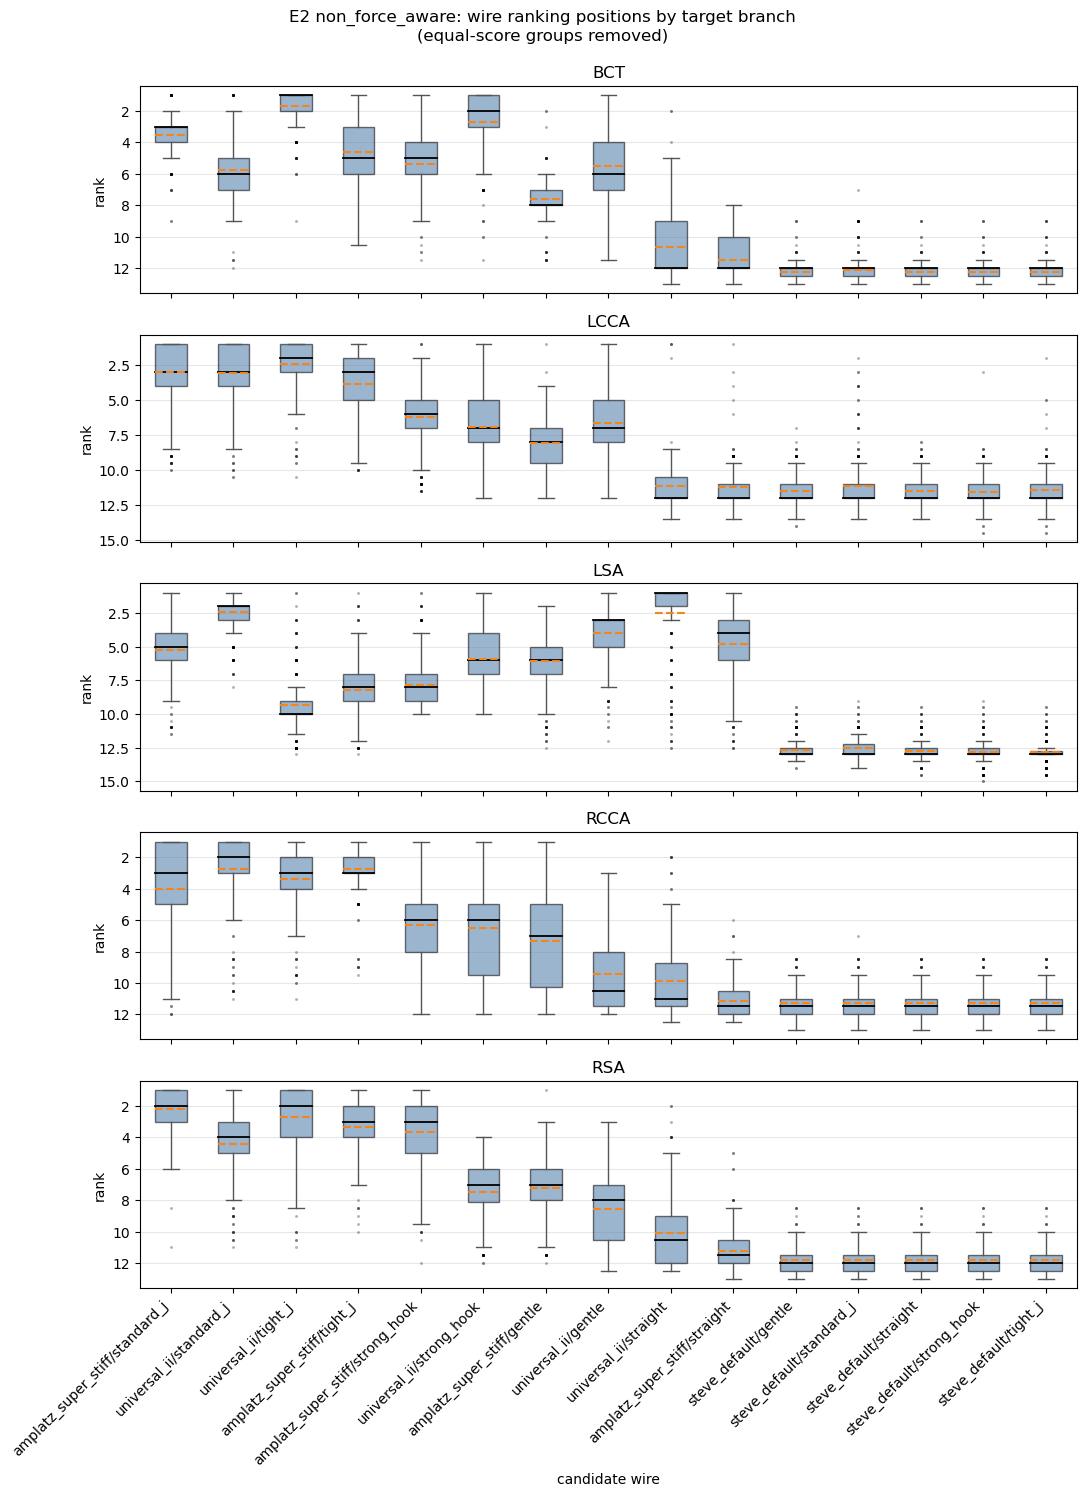

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_rank_distribution_by_branch_without_equal_scores_boxplot.png`

In [28]:
# Branch-wise filtered distribution of wire ranking positions.
# One subplot per target branch. Lower rank is better.
E2_BRANCH_FILTERED_RANK_FAMILY = E2_FILTERED_RANK_DISTRIBUTION_FAMILY if "E2_FILTERED_RANK_DISTRIBUTION_FAMILY" in globals() else "non_force_aware"
E2_BRANCH_FILTERED_RANK_EQUAL_SCORE_TOLERANCE = E2_EQUAL_SCORE_TOLERANCE if "E2_EQUAL_SCORE_TOLERANCE" in globals() else 1e-12

score_table_path = e2_bootstrap_output_path(E2_BRANCH_FILTERED_RANK_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    score_df = pd.read_csv(score_table_path)
    if "branch" not in score_df.columns:
        if "anatomy_target_key" in score_df.columns:
            score_df["branch"] = score_df["anatomy_target_key"].astype(str).str.split("__").str[-1]
        else:
            raise KeyError("The score table needs either `branch` or `anatomy_target_key`.")

    required_cols = {"anatomy_target_key", "branch", "candidate_key", "execution_wire", "force_alpha", "observed_wire_score"}
    missing_cols = sorted(required_cols - set(score_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        score_df = score_df.copy()
        score_df["observed_wire_score"] = pd.to_numeric(score_df["observed_wire_score"], errors="coerce")

        score_range_df = (
            score_df
            .groupby("anatomy_target_key", dropna=False)
            .agg(
                branch=("branch", "first"),
                min_score=("observed_wire_score", "min"),
                max_score=("observed_wire_score", "max"),
                n_candidates=("candidate_key", "nunique"),
            )
            .reset_index()
        )
        score_range_df["score_range"] = score_range_df["max_score"] - score_range_df["min_score"]
        equal_score_keys = set(
            score_range_df.loc[
                score_range_df["score_range"].abs().le(E2_BRANCH_FILTERED_RANK_EQUAL_SCORE_TOLERANCE),
                "anatomy_target_key",
            ]
        )

        rank_df = score_df.loc[~score_df["anatomy_target_key"].isin(equal_score_keys)].copy()
        rank_df["rank_position"] = (
            rank_df
            .groupby("anatomy_target_key", dropna=False)["observed_wire_score"]
            .rank(method="average", ascending=False)
        )
        rank_df["is_top_rank"] = rank_df["rank_position"].eq(1.0)
        rank_df["label"] = rank_df["execution_wire"].astype(str)
        force_mask = rank_df["force_alpha"].notna()
        rank_df.loc[force_mask, "label"] = (
            rank_df.loc[force_mask, "execution_wire"].astype(str)
            + " / "
            + rank_df.loc[force_mask, "force_alpha"].astype(str)
        )

        branch_rank_summary_df = (
            rank_df
            .groupby(["branch", "candidate_key", "label", "execution_wire", "force_alpha"], dropna=False)
            .agg(
                n_anatomy_targets=("anatomy_target_key", "nunique"),
                min_rank=("rank_position", "min"),
                q25_rank=("rank_position", lambda s: float(s.quantile(0.25))),
                median_rank=("rank_position", "median"),
                mean_rank=("rank_position", "mean"),
                q75_rank=("rank_position", lambda s: float(s.quantile(0.75))),
                max_rank=("rank_position", "max"),
                top_rank_rate_percent=("is_top_rank", lambda s: 100.0 * float(s.mean())),
                mean_score=("observed_wire_score", "mean"),
            )
            .reset_index()
            .sort_values(["branch", "median_rank", "mean_rank", "mean_score"], ascending=[True, True, True, False])
            .reset_index(drop=True)
        )

        removed_by_branch = (
            score_range_df.assign(equal_score=lambda df: df["anatomy_target_key"].isin(equal_score_keys))
            .groupby("branch", dropna=False)
            .agg(
                total_anatomy_targets=("anatomy_target_key", "nunique"),
                removed_equal_score_targets=("equal_score", "sum"),
            )
            .reset_index()
        )
        removed_by_branch["removed_percent"] = 100.0 * removed_by_branch["removed_equal_score_targets"] / removed_by_branch["total_anatomy_targets"]

        summary_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_FILTERED_RANK_FAMILY}_wire_rank_distribution_by_branch_without_equal_scores.csv"
        detail_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_FILTERED_RANK_FAMILY}_wire_rank_distribution_by_branch_without_equal_scores_detail.csv"
        removed_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_FILTERED_RANK_FAMILY}_wire_rank_equal_score_removed_by_branch.csv"
        branch_rank_summary_df.to_csv(summary_csv, index=False)
        rank_df.to_csv(detail_csv, index=False)
        removed_by_branch.to_csv(removed_csv, index=False)

        display(Markdown(f"### Branch-wise ranking-position distributions without equal-score groups: {E2_BRANCH_FILTERED_RANK_FAMILY}"))
        display(Markdown(f"Saved summary table: `{summary_csv}`"))
        display(Markdown(f"Saved detail table: `{detail_csv}`"))
        display(Markdown(f"Saved removal table: `{removed_csv}`"))
        display(Markdown("Equal-score anatomy-target groups removed per branch:"))
        display(removed_by_branch.round(3))
        display(branch_rank_summary_df.round(3))

        branch_order = sorted(rank_df["branch"].dropna().unique())
        label_order = (
            rank_df
            .groupby("label", dropna=False)["rank_position"]
            .median()
            .sort_values()
            .index
            .tolist()
        )

        n_branches = len(branch_order)
        fig, axes = plt.subplots(n_branches, 1, figsize=(max(11, len(label_order) * 0.62), max(4.2, 3.0 * n_branches)), sharex=True)
        if n_branches == 1:
            axes = [axes]

        positions = np.arange(1, len(label_order) + 1)
        for row_index, (ax, branch) in enumerate(zip(axes, branch_order)):
            branch_df = rank_df.loc[rank_df["branch"].eq(branch)]
            plot_data = [
                branch_df.loc[branch_df["label"].eq(label), "rank_position"].dropna().to_numpy(dtype=float)
                for label in label_order
            ]
            ax.boxplot(
                plot_data,
                positions=positions,
                showmeans=True,
                meanline=True,
                patch_artist=True,
                boxprops={"facecolor": "#4C78A8", "alpha": 0.55},
                medianprops={"color": "black", "linewidth": 1.3},
                meanprops={"color": "#F58518", "linewidth": 1.5},
                whiskerprops={"color": "#555555"},
                capprops={"color": "#555555"},
                flierprops={"marker": ".", "markersize": 2.2, "alpha": 0.30},
            )
            ax.set_title(str(branch).upper())
            ax.set_ylabel("rank")
            ax.set_xticks(positions)
            if row_index < len(branch_order) - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xticklabels(label_order, rotation=45, ha="right")
                ax.set_xlabel("candidate wire")
            ax.invert_yaxis()
            ax.grid(axis="y", alpha=0.3)
        fig.suptitle(f"E2 {E2_BRANCH_FILTERED_RANK_FAMILY}: wire ranking positions by target branch\n(equal-score groups removed)", y=0.995)
        fig.tight_layout()

        figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_FILTERED_RANK_FAMILY}_wire_rank_distribution_by_branch_without_equal_scores_boxplot.png"
        figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_FILTERED_RANK_FAMILY}_wire_rank_distribution_by_branch_without_equal_scores_boxplot.pdf"
        fig.savefig(figure_png, dpi=200, bbox_inches="tight")
        fig.savefig(figure_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved figure: `{figure_png}`"))





### 3.2.6 Mean Ranking Position per Branch

This table ranks the wires within each target branch by their mean ranking position across anatomy-target groups. Lower mean position is better. The heatmap shows the resulting branch-specific wire order, where rank 1 is the best average position for that branch.


### Mean ranking-position order per target branch: non_force_aware

Saved table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_mean_position_rank_by_branch.csv`

,branch,label,mean_position_rank_within_branch,mean_rank,median_rank,top_rank_rate_percent,mean_score,n_anatomy_targets
0,bct,universal_ii/tight_j,1.0,1.671,1.0,59.706,0.856,340
1,bct,universal_ii/strong_hook,2.0,2.678,2.0,28.529,0.804,340
2,bct,amplatz_super_stiff/standard_j,3.0,3.541,3.0,5.000,0.791,340
3,bct,amplatz_super_stiff/tight_j,4.0,4.613,5.0,2.353,0.760,340
4,bct,amplatz_super_stiff/strong_hook,5.0,5.359,5.0,0.882,0.708,340
...,...,...,...,...,...,...,...,...
70,rsa,steve_default/standard_j,11.0,11.815,12.0,0.000,0.000,340
71,rsa,steve_default/gentle,13.5,11.834,12.0,0.000,0.000,340
72,rsa,steve_default/straight,13.5,11.834,12.0,0.000,0.000,340
73,rsa,steve_default/strong_hook,13.5,11.834,12.0,0.000,0.000,340


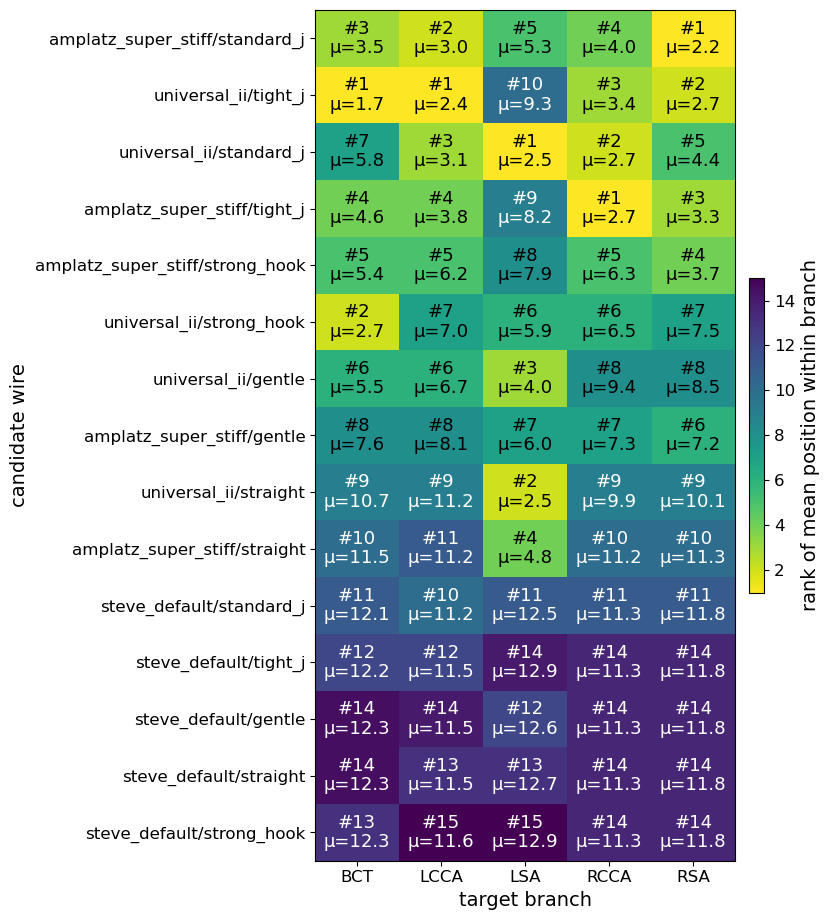

Saved heatmap: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_wire_mean_position_rank_by_branch_heatmap.png`

In [29]:
# Rank wires within each branch by their mean ranking position.
# This uses the branch-wise rank summary from section 3.2.5.
E2_BRANCH_MEAN_RANK_FAMILY = E2_BRANCH_FILTERED_RANK_FAMILY if "E2_BRANCH_FILTERED_RANK_FAMILY" in globals() else "non_force_aware"

branch_rank_summary_path = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_MEAN_RANK_FAMILY}_wire_rank_distribution_by_branch_without_equal_scores.csv"
if branch_rank_summary_path.exists():
    branch_rank_source = pd.read_csv(branch_rank_summary_path)
elif "branch_rank_summary_df" in globals():
    branch_rank_source = branch_rank_summary_df.copy()
else:
    branch_rank_source = pd.DataFrame()

if branch_rank_source.empty:
    display(Markdown(f"Run section 3.2.5 first. Missing: `{branch_rank_summary_path}`"))
else:
    required_cols = {"branch", "label", "mean_rank", "median_rank", "mean_score", "n_anatomy_targets"}
    missing_cols = sorted(required_cols - set(branch_rank_source.columns))
    if missing_cols:
        display(Markdown("Missing columns: `" + "`, `".join(missing_cols) + "`."))
    else:
        branch_mean_rank_df = branch_rank_source.copy()
        branch_mean_rank_df["mean_position_rank_within_branch"] = (
            branch_mean_rank_df
            .groupby("branch", dropna=False)["mean_rank"]
            .rank(method="average", ascending=True)
        )
        branch_mean_rank_df = (
            branch_mean_rank_df
            .sort_values(["branch", "mean_position_rank_within_branch", "mean_rank"])
            .reset_index(drop=True)
        )

        table_cols = [
            "branch",
            "label",
            "mean_position_rank_within_branch",
            "mean_rank",
            "median_rank",
            "top_rank_rate_percent",
            "mean_score",
            "n_anatomy_targets",
        ]
        table_cols = [col for col in table_cols if col in branch_mean_rank_df.columns]

        mean_rank_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_MEAN_RANK_FAMILY}_wire_mean_position_rank_by_branch.csv"
        branch_mean_rank_df[table_cols].to_csv(mean_rank_csv, index=False)

        display(Markdown(f"### Mean ranking-position order per target branch: {E2_BRANCH_MEAN_RANK_FAMILY}"))
        display(Markdown(f"Saved table: `{mean_rank_csv}`"))
        display(branch_mean_rank_df[table_cols].round(3))

        branch_order = sorted(branch_mean_rank_df["branch"].dropna().unique())
        label_order = (
            branch_mean_rank_df
            .groupby("label", dropna=False)["mean_position_rank_within_branch"]
            .mean()
            .sort_values()
            .index
            .tolist()
        )

        heatmap_df = (
            branch_mean_rank_df
            .pivot(index="branch", columns="label", values="mean_position_rank_within_branch")
            .reindex(index=branch_order, columns=label_order)
        )
        mean_position_df = (
            branch_mean_rank_df
            .pivot(index="branch", columns="label", values="mean_rank")
            .reindex(index=branch_order, columns=label_order)
        )

        heatmap_plot_df = heatmap_df.T
        mean_position_plot_df = mean_position_df.T
        fig, ax = plt.subplots(figsize=(max(8.4, len(branch_order) * 1.0), max(7.6, len(label_order) * 0.62)))
        im = ax.imshow(
            heatmap_plot_df.to_numpy(dtype=float),
            cmap="viridis_r",
            vmin=1,
            vmax=float(np.nanmax(heatmap_plot_df.to_numpy(dtype=float))),
            aspect="auto",
        )
        ax.set_xticks(np.arange(len(branch_order)))
        ax.set_xticklabels([str(branch).upper() for branch in branch_order], fontsize=12)
        ax.set_yticks(np.arange(len(label_order)))
        ax.set_yticklabels(label_order, fontsize=12)
        ax.set_xlabel("target branch", fontsize=14)
        ax.set_ylabel("candidate wire", fontsize=14)
        ax.tick_params(axis="both", labelsize=12)

        for row_idx, label in enumerate(label_order):
            for col_idx, branch in enumerate(branch_order):
                order_rank = heatmap_plot_df.loc[label, branch]
                mean_position = mean_position_plot_df.loc[label, branch]
                if pd.isna(order_rank):
                    text = ""
                else:
                    text = f"#{order_rank:.0f}\nμ={mean_position:.1f}"
                ax.text(
                    col_idx,
                    row_idx,
                    text,
                    ha="center",
                    va="center",
                    fontsize=13,
                    linespacing=1.10,
                    color="white" if order_rank > 8 else "black",
                )

        cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("rank of mean position within branch", fontsize=14)
        cbar.ax.tick_params(labelsize=12)
        fig.tight_layout()

        heatmap_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_MEAN_RANK_FAMILY}_wire_mean_position_rank_by_branch_heatmap.png"
        heatmap_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_MEAN_RANK_FAMILY}_wire_mean_position_rank_by_branch_heatmap.pdf"
        fig.savefig(heatmap_png, dpi=200, bbox_inches="tight")
        fig.savefig(heatmap_pdf, bbox_inches="tight")
        plt.show()
        display(Markdown(f"Saved heatmap: `{heatmap_png}`"))







### 3.2.7 stEVE Default No-Score Cases Caused by Force

This quick check quantifies how often stEVE Default candidates receive no valid score because the force threshold removes all otherwise successful trials. A group is counted as force-limited only if it has zero valid trials, at least one trial reached the target within the step budget, and none of those successful step-budget trials stayed below the force limit.


In [30]:
# Quick numerical check: stEVE Default no-score cases caused by force violations.
# This loads the non-force-aware trial cache, but keeps only the columns needed for this analysis.
E2_STEVE_FORCE_LIMIT_N = E2_FORCE_LIMIT_N if "E2_FORCE_LIMIT_N" in globals() else 2.0
E2_STEVE_STEP_BUDGET = E2_SCORE_STEP_BUDGET if "E2_SCORE_STEP_BUDGET" in globals() else 828.0
E2_STEVE_TRIAL_CACHE = E2_NON_FORCE_RESULT_ROOT / "analysis_cache" / "trial_df_requested_columns.pkl.gz"

if not E2_STEVE_TRIAL_CACHE.exists():
    display(Markdown(f"Missing trial cache: `{E2_STEVE_TRIAL_CACHE}`"))
else:
    needed_cols = [
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "candidate_name",
        "execution_wire",
        "success",
        "steps_total",
        "wire_force_normal_trial_max_N",
    ]
    trial_source = pd.read_pickle(E2_STEVE_TRIAL_CACHE)
    steve_trials = trial_source.loc[
        trial_source["execution_wire"].astype(str).str.startswith("steve_default"),
        [col for col in needed_cols if col in trial_source.columns],
    ].copy()
    del trial_source

    steve_trials["success_float"] = e2_success_to_float(steve_trials["success"])
    steve_trials["steps_total"] = pd.to_numeric(steve_trials["steps_total"], errors="coerce")
    steve_trials["wire_force_normal_trial_max_N"] = pd.to_numeric(steve_trials["wire_force_normal_trial_max_N"], errors="coerce")
    steve_trials["anatomy_target_key"] = (
        "Tree_" + steve_trials["anatomy_index"].astype(str)
        + "__target_" + steve_trials["target_index"].astype(int).astype(str).str.zfill(3)
        + "__" + steve_trials["branch"].astype(str)
    )

    steve_trials["reached_within_step_budget"] = steve_trials["success_float"].eq(1.0) & steve_trials["steps_total"].le(E2_STEVE_STEP_BUDGET)
    steve_trials["force_within_limit"] = steve_trials["wire_force_normal_trial_max_N"].le(E2_STEVE_FORCE_LIMIT_N)
    steve_trials["valid_for_score"] = steve_trials["reached_within_step_budget"] & steve_trials["force_within_limit"]
    steve_trials["force_too_high_after_reaching"] = steve_trials["reached_within_step_budget"] & ~steve_trials["force_within_limit"]

    steve_force_summary = (
        steve_trials
        .groupby(["execution_wire", "anatomy_target_key", "branch"], dropna=False)
        .agg(
            n_trials=("valid_for_score", "size"),
            n_reached_within_step_budget=("reached_within_step_budget", "sum"),
            n_valid_trials=("valid_for_score", "sum"),
            n_force_too_high_after_reaching=("force_too_high_after_reaching", "sum"),
            max_force_N=("wire_force_normal_trial_max_N", "max"),
            mean_force_N=("wire_force_normal_trial_max_N", "mean"),
        )
        .reset_index()
    )

    steve_force_summary["no_valid_score"] = steve_force_summary["n_valid_trials"].eq(0)
    steve_force_summary["no_score_because_force_too_high"] = (
        steve_force_summary["no_valid_score"]
        & steve_force_summary["n_reached_within_step_budget"].gt(0)
        & steve_force_summary["n_force_too_high_after_reaching"].eq(steve_force_summary["n_reached_within_step_budget"])
    )
    steve_force_summary["no_score_because_no_success_within_step_budget"] = (
        steve_force_summary["no_valid_score"]
        & steve_force_summary["n_reached_within_step_budget"].eq(0)
    )

    per_wire_summary = (
        steve_force_summary
        .groupby("execution_wire", dropna=False)
        .agg(
            anatomy_target_count=("anatomy_target_key", "nunique"),
            no_valid_score_count=("no_valid_score", "sum"),
            no_score_force_too_high_count=("no_score_because_force_too_high", "sum"),
            no_score_no_success_count=("no_score_because_no_success_within_step_budget", "sum"),
        )
        .reset_index()
    )
    per_wire_summary["no_valid_score_percent"] = 100.0 * per_wire_summary["no_valid_score_count"] / per_wire_summary["anatomy_target_count"]
    per_wire_summary["no_score_force_too_high_percent"] = 100.0 * per_wire_summary["no_score_force_too_high_count"] / per_wire_summary["anatomy_target_count"]
    per_wire_summary["no_score_no_success_percent"] = 100.0 * per_wire_summary["no_score_no_success_count"] / per_wire_summary["anatomy_target_count"]

    any_steve_summary = (
        steve_force_summary
        .groupby("anatomy_target_key", dropna=False)
        .agg(
            branch=("branch", "first"),
            any_steve_force_limited=("no_score_because_force_too_high", "any"),
            all_steve_force_limited=("no_score_because_force_too_high", "all"),
            any_steve_no_valid_score=("no_valid_score", "any"),
            all_steve_no_valid_score=("no_valid_score", "all"),
        )
        .reset_index()
    )
    overall_summary = pd.DataFrame([
        {
            "metric": "any stEVE Default tip shape no score because force too high",
            "anatomy_target_count": int(any_steve_summary["any_steve_force_limited"].sum()),
            "percent_of_anatomy_targets": 100.0 * float(any_steve_summary["any_steve_force_limited"].mean()),
        },
        {
            "metric": "all stEVE Default tip shapes no score because force too high",
            "anatomy_target_count": int(any_steve_summary["all_steve_force_limited"].sum()),
            "percent_of_anatomy_targets": 100.0 * float(any_steve_summary["all_steve_force_limited"].mean()),
        },
        {
            "metric": "any stEVE Default tip shape has no valid score for any reason",
            "anatomy_target_count": int(any_steve_summary["any_steve_no_valid_score"].sum()),
            "percent_of_anatomy_targets": 100.0 * float(any_steve_summary["any_steve_no_valid_score"].mean()),
        },
        {
            "metric": "all stEVE Default tip shapes have no valid score for any reason",
            "anatomy_target_count": int(any_steve_summary["all_steve_no_valid_score"].sum()),
            "percent_of_anatomy_targets": 100.0 * float(any_steve_summary["all_steve_no_valid_score"].mean()),
        },
    ])

    branch_summary = (
        any_steve_summary
        .groupby("branch", dropna=False)
        .agg(
            anatomy_target_count=("anatomy_target_key", "nunique"),
            any_steve_force_limited_count=("any_steve_force_limited", "sum"),
            all_steve_force_limited_count=("all_steve_force_limited", "sum"),
        )
        .reset_index()
    )
    branch_summary["any_steve_force_limited_percent"] = 100.0 * branch_summary["any_steve_force_limited_count"] / branch_summary["anatomy_target_count"]
    branch_summary["all_steve_force_limited_percent"] = 100.0 * branch_summary["all_steve_force_limited_count"] / branch_summary["anatomy_target_count"]

    all_no_valid_groups = (
        steve_force_summary
        .groupby("anatomy_target_key", dropna=False)
        .agg(
            branch=("branch", "first"),
            n_steve_tip_shapes=("execution_wire", "nunique"),
            all_steve_no_valid_score=("no_valid_score", "all"),
            n_force_limited_tip_shapes=("no_score_because_force_too_high", "sum"),
            n_no_success_tip_shapes=("no_score_because_no_success_within_step_budget", "sum"),
            total_reached_within_step_budget_trials=("n_reached_within_step_budget", "sum"),
            total_force_too_high_after_reaching_trials=("n_force_too_high_after_reaching", "sum"),
        )
        .reset_index()
    )
    all_no_valid_groups = all_no_valid_groups.loc[all_no_valid_groups["all_steve_no_valid_score"]].copy()

    def classify_all_no_valid_reason(row):
        if row["n_force_limited_tip_shapes"] == row["n_steve_tip_shapes"]:
            return "all tip shapes force-limited"
        if row["n_no_success_tip_shapes"] == row["n_steve_tip_shapes"]:
            return "all tip shapes no success within budget"
        if (
            row["n_force_limited_tip_shapes"] > 0
            and row["n_no_success_tip_shapes"] > 0
            and row["n_force_limited_tip_shapes"] + row["n_no_success_tip_shapes"] == row["n_steve_tip_shapes"]
        ):
            return "mixed force-limited and no-success tip shapes"
        return "other/missing classification"

    all_no_valid_groups["reason"] = all_no_valid_groups.apply(classify_all_no_valid_reason, axis=1)
    all_no_valid_reason_summary = (
        all_no_valid_groups
        .groupby("reason", dropna=False)
        .agg(
            anatomy_target_count=("anatomy_target_key", "nunique"),
            mean_reached_within_step_budget_trials=("total_reached_within_step_budget_trials", "mean"),
            mean_force_too_high_after_reaching_trials=("total_force_too_high_after_reaching_trials", "mean"),
        )
        .reset_index()
        .sort_values("anatomy_target_count", ascending=False)
    )
    all_no_valid_reason_summary["percent_of_all_steve_no_valid_groups"] = (
        100.0 * all_no_valid_reason_summary["anatomy_target_count"] / len(all_no_valid_groups)
    )
    all_no_valid_reason_summary["percent_of_all_anatomy_targets"] = (
        100.0 * all_no_valid_reason_summary["anatomy_target_count"] / any_steve_summary["anatomy_target_key"].nunique()
    )

    output_prefix = E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_steve_default_no_score_force_too_high"
    steve_force_summary.to_csv(output_prefix.with_name(output_prefix.name + "_detail.csv"), index=False)
    per_wire_summary.to_csv(output_prefix.with_name(output_prefix.name + "_per_wire.csv"), index=False)
    overall_summary.to_csv(output_prefix.with_name(output_prefix.name + "_overall.csv"), index=False)
    branch_summary.to_csv(output_prefix.with_name(output_prefix.name + "_by_branch.csv"), index=False)
    all_no_valid_reason_summary.to_csv(output_prefix.with_name(output_prefix.name + "_all_no_valid_reason_summary.csv"), index=False)
    all_no_valid_groups.to_csv(output_prefix.with_name(output_prefix.name + "_all_no_valid_reason_by_target.csv"), index=False)

    display(Markdown("### stEVE Default no-score cases caused by force threshold"))
    display(Markdown(f"Force threshold: `{E2_STEVE_FORCE_LIMIT_N} N`; step budget: `{E2_STEVE_STEP_BUDGET}` steps."))
    display(Markdown("Overall anatomy-target percentages:"))
    display(overall_summary.round(3))
    display(Markdown("Per stEVE Default tip shape:"))
    display(per_wire_summary.round(3))
    display(Markdown("By target branch:"))
    display(branch_summary.round(3))
    display(Markdown("Reason breakdown for anatomy-target groups where all stEVE Default tip shapes have no valid score:"))
    display(all_no_valid_reason_summary.round(3))




### stEVE Default no-score cases caused by force threshold

Force threshold: `2.0 N`; step budget: `828.0` steps.

Overall anatomy-target percentages:

,metric,anatomy_target_count,percent_of_anatomy_targets
0,any stEVE Default tip shape no score because f...,1733,99.598
1,all stEVE Default tip shapes no score because ...,294,16.897
2,any stEVE Default tip shape has no valid score...,1740,100.000
3,all stEVE Default tip shapes have no valid sco...,1624,93.333


Per stEVE Default tip shape:

,execution_wire,anatomy_target_count,no_valid_score_count,no_score_force_too_high_count,no_score_no_success_count,no_valid_score_percent,no_score_force_too_high_percent,no_score_no_success_percent
0,steve_default/gentle,1740,1700,730,970,97.701,41.954,55.747
1,steve_default/standard_j,1738,1644,1587,57,94.591,91.312,3.280
2,steve_default/straight,1736,1711,355,1356,98.560,20.449,78.111
3,steve_default/strong_hook,1733,1728,1702,26,99.711,98.211,1.500
4,steve_default/tight_j,1733,1716,1686,30,99.019,97.288,1.731


By target branch:

,branch,anatomy_target_count,any_steve_force_limited_count,all_steve_force_limited_count,any_steve_force_limited_percent,all_steve_force_limited_percent
0,bct,349,349,21,100.000,6.017
1,lcca,348,345,10,99.138,2.874
2,lsa,348,348,245,100.000,70.402
3,rcca,347,346,2,99.712,0.576
4,rsa,348,345,16,99.138,4.598


Reason breakdown for anatomy-target groups where all stEVE Default tip shapes have no valid score:

,reason,anatomy_target_count,mean_reached_within_step_budget_trials,mean_force_too_high_after_reaching_trials,percent_of_all_steve_no_valid_groups,percent_of_all_anatomy_targets
2,mixed force-limited and no-success tip shapes,1323,980.734,980.734,81.466,76.034
0,all tip shapes force-limited,294,2202.408,2202.408,18.103,16.897
1,all tip shapes no success within budget,7,0.000,0.000,0.431,0.402


### 3.2.8 Tip-Shape and Target-Branch Effects on Score and Success Rate

This section checks whether the E2 score and success rate are associated with guidewire tip shape, target branch, and their interaction. Because `statsmodels` is not available in this environment, the test uses a simple permutation-based two-way effect analysis. The reported effect size is the fraction of total variance explained by each factor, and the p-value is the fraction of shuffled datasets with an equal or larger effect.


### Tip-shape and target-branch effects: non_force_aware

Saved effect table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_tip_shape_branch_permutation_effects.csv`

,metric,effect,variance_fraction_eta2,permutation_p_value,significant_at_0_05,n_permutations,n_rows
0,observed_wire_score,tip_shape,0.06030,0.0002,True,5000,25500
1,observed_wire_score,branch,0.17163,0.0002,True,5000,25500
2,observed_wire_score,interaction,0.05550,0.0002,True,5000,25500
3,success_rate,tip_shape,0.18563,0.0002,True,5000,25500
4,success_rate,branch,0.29341,0.0002,True,5000,25500
5,success_rate,interaction,0.08889,0.0002,True,5000,25500


Saved descriptive table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_tip_shape_branch_mean_score_success.csv`

,wire_shape,branch,n_candidates,mean_score,mean_success_rate,median_score,median_success_rate
0,gentle,bct,1020,0.3639,0.5148,0.3274,0.586
1,gentle,lcca,1020,0.1500,0.2256,0.0000,0.008
2,gentle,lsa,1020,0.5331,0.8573,0.8503,1.000
3,gentle,rcca,1020,0.0124,0.0222,0.0000,0.000
4,gentle,rsa,1020,0.0814,0.1437,0.0000,0.006
5,standard_j,bct,1020,0.4666,0.8417,0.6135,0.976
6,standard_j,lcca,1020,0.3621,0.6563,0.1713,0.888
7,standard_j,lsa,1020,0.5757,0.9439,0.8699,1.000
8,standard_j,rcca,1020,0.1462,0.3437,0.0267,0.259
9,standard_j,rsa,1020,0.3316,0.6481,0.2591,0.740


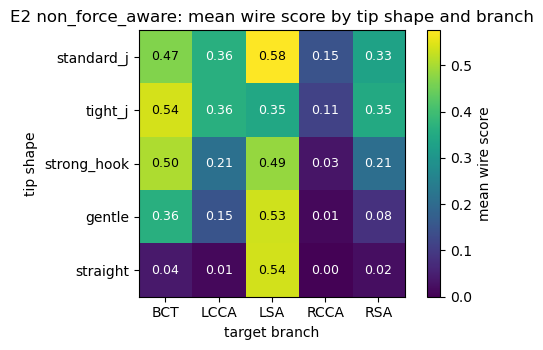

Saved heatmap: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_tip_shape_branch_mean_score_heatmap.png`

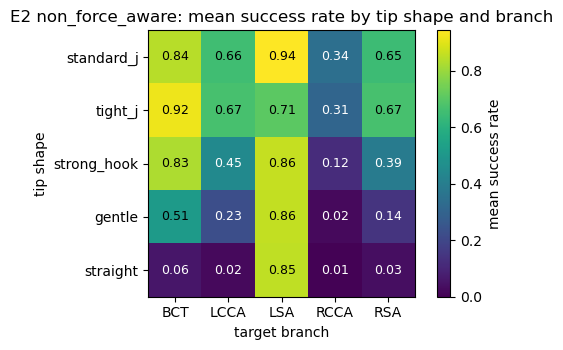

Saved heatmap: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_tip_shape_branch_mean_success_rate_heatmap.png`

In [31]:
# Tip-shape and target-branch effect analysis for score and success rate.
# Categorical factors are tested with a permutation-based two-way effect analysis.
E2_TIP_BRANCH_EFFECT_FAMILY = "non_force_aware"  # options: "non_force_aware", "force_aware"
E2_TIP_BRANCH_PERMUTATIONS = 5000
E2_TIP_BRANCH_PERMUTATION_SEED = 123

score_table_path = e2_bootstrap_output_path(E2_TIP_BRANCH_EFFECT_FAMILY)
if not score_table_path.exists():
    display(Markdown(f"Build the per-anatomy-target score table first: `{score_table_path}`"))
else:
    effect_df = pd.read_csv(score_table_path)
    required_cols = {"wire_shape", "branch", "observed_wire_score", "success_rate"}
    missing_cols = sorted(required_cols - set(effect_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in score table: `" + "`, `".join(missing_cols) + "`."))
    else:
        effect_df = effect_df.copy()
        effect_df["wire_shape"] = effect_df["wire_shape"].astype(str)
        effect_df["branch"] = effect_df["branch"].astype(str)
        effect_df["observed_wire_score"] = pd.to_numeric(effect_df["observed_wire_score"], errors="coerce")
        effect_df["success_rate"] = pd.to_numeric(effect_df["success_rate"], errors="coerce")

        def two_way_effect_sizes(data, value_col, factor_a="wire_shape", factor_b="branch"):
            work = data[[factor_a, factor_b, value_col]].dropna().copy()
            y = work[value_col].to_numpy(dtype=float)
            grand_mean = float(np.mean(y))
            ss_total = float(np.sum((y - grand_mean) ** 2))
            if ss_total == 0:
                return {"tip_shape": 0.0, "branch": 0.0, "interaction": 0.0}

            mean_a = work.groupby(factor_a)[value_col].mean()
            count_a = work.groupby(factor_a)[value_col].size()
            ss_a = float(((mean_a - grand_mean) ** 2 * count_a).sum())

            mean_b = work.groupby(factor_b)[value_col].mean()
            count_b = work.groupby(factor_b)[value_col].size()
            ss_b = float(((mean_b - grand_mean) ** 2 * count_b).sum())

            cell = work.groupby([factor_a, factor_b])[value_col].agg(["mean", "size"]).reset_index()
            ss_cells = float(((cell["mean"] - grand_mean) ** 2 * cell["size"]).sum())
            ss_interaction = max(0.0, ss_cells - ss_a - ss_b)

            return {
                "tip_shape": ss_a / ss_total,
                "branch": ss_b / ss_total,
                "interaction": ss_interaction / ss_total,
            }

        def permutation_effect_test(data, value_col, n_permutations, seed):
            rng = np.random.default_rng(seed)
            work = data[["wire_shape", "branch", value_col]].dropna().copy()
            observed = two_way_effect_sizes(work, value_col)
            permuted_counts = {key: 0 for key in observed}
            values = work[value_col].to_numpy(dtype=float).copy()

            for _ in range(n_permutations):
                shuffled = work.copy()
                shuffled[value_col] = rng.permutation(values)
                permuted = two_way_effect_sizes(shuffled, value_col)
                for key in observed:
                    if permuted[key] >= observed[key]:
                        permuted_counts[key] += 1

            rows = []
            for key, effect_size in observed.items():
                p_value = (permuted_counts[key] + 1) / (n_permutations + 1)
                rows.append({
                    "metric": value_col,
                    "effect": key,
                    "variance_fraction_eta2": effect_size,
                    "permutation_p_value": p_value,
                    "significant_at_0_05": bool(p_value < 0.05),
                    "n_permutations": n_permutations,
                    "n_rows": len(work),
                })
            return pd.DataFrame(rows)

        score_effects = permutation_effect_test(
            effect_df,
            "observed_wire_score",
            E2_TIP_BRANCH_PERMUTATIONS,
            E2_TIP_BRANCH_PERMUTATION_SEED,
        )
        success_effects = permutation_effect_test(
            effect_df,
            "success_rate",
            E2_TIP_BRANCH_PERMUTATIONS,
            E2_TIP_BRANCH_PERMUTATION_SEED + 1,
        )
        tip_branch_effects_df = pd.concat([score_effects, success_effects], ignore_index=True)

        mean_by_shape_branch = (
            effect_df
            .groupby(["wire_shape", "branch"], dropna=False)
            .agg(
                n_candidates=("observed_wire_score", "size"),
                mean_score=("observed_wire_score", "mean"),
                mean_success_rate=("success_rate", "mean"),
                median_score=("observed_wire_score", "median"),
                median_success_rate=("success_rate", "median"),
            )
            .reset_index()
        )

        effects_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_TIP_BRANCH_EFFECT_FAMILY}_tip_shape_branch_permutation_effects.csv"
        means_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_TIP_BRANCH_EFFECT_FAMILY}_tip_shape_branch_mean_score_success.csv"
        tip_branch_effects_df.to_csv(effects_csv, index=False)
        mean_by_shape_branch.to_csv(means_csv, index=False)

        display(Markdown(f"### Tip-shape and target-branch effects: {E2_TIP_BRANCH_EFFECT_FAMILY}"))
        display(Markdown(f"Saved effect table: `{effects_csv}`"))
        display(tip_branch_effects_df.round(5))
        display(Markdown(f"Saved descriptive table: `{means_csv}`"))
        display(mean_by_shape_branch.round(4))

        shape_order = (
            mean_by_shape_branch
            .groupby("wire_shape")["mean_score"]
            .mean()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
        branch_order = sorted(mean_by_shape_branch["branch"].unique())

        for metric_col, title_metric, file_metric in [
            ("mean_score", "mean wire score", "mean_score"),
            ("mean_success_rate", "mean success rate", "mean_success_rate"),
        ]:
            heatmap_df = (
                mean_by_shape_branch
                .pivot(index="wire_shape", columns="branch", values=metric_col)
                .reindex(index=shape_order, columns=branch_order)
            )
            fig, ax = plt.subplots(figsize=(8.0, max(3.6, len(shape_order) * 0.55)))
            im = ax.imshow(heatmap_df.to_numpy(dtype=float), cmap="viridis", vmin=0, vmax=max(0.01, float(np.nanmax(heatmap_df.to_numpy(dtype=float)))))
            ax.set_xticks(np.arange(len(branch_order)))
            ax.set_xticklabels([str(branch).upper() for branch in branch_order])
            ax.set_yticks(np.arange(len(shape_order)))
            ax.set_yticklabels(shape_order)
            ax.set_xlabel("target branch")
            ax.set_ylabel("tip shape")
            ax.set_title(f"E2 {E2_TIP_BRANCH_EFFECT_FAMILY}: {title_metric} by tip shape and branch")

            for row_idx, shape in enumerate(shape_order):
                for col_idx, branch in enumerate(branch_order):
                    value = heatmap_df.loc[shape, branch]
                    text = "" if pd.isna(value) else f"{value:.2f}"
                    ax.text(col_idx, row_idx, text, ha="center", va="center", color="white" if value < 0.45 else "black", fontsize=9)

            cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
            cbar.set_label(title_metric)
            fig.tight_layout()

            figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_TIP_BRANCH_EFFECT_FAMILY}_tip_shape_branch_{file_metric}_heatmap.png"
            figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_TIP_BRANCH_EFFECT_FAMILY}_tip_shape_branch_{file_metric}_heatmap.pdf"
            fig.savefig(figure_png, dpi=200, bbox_inches="tight")
            fig.savefig(figure_pdf, bbox_inches="tight")
            plt.show()
            display(Markdown(f"Saved heatmap: `{figure_png}`"))



### 3.2.9 Paired Force Comparison: Force-Aware vs Non-Force-Aware Standard-J Agents

This analysis compares each force-aware standard-J agent against the corresponding non-force-aware standard-J agent from the same wire family. Trials are matched by anatomy, target, branch, and trial index. Only matched trials where both agents reached the target are included, regardless of whether the force threshold was exceeded. The plotted difference is `force-aware max force - non-force-aware max force`; negative values indicate lower forces for the force-aware agent.


Streaming **1700** matched E2 run folders. Only successful standard-J trials are retained for the force comparison.

processed_runs=100 paired_successful_trials=177,705 latest=Tree_1250__target_004__rsa__end__seedbase_108127
processed_runs=200 paired_successful_trials=351,040 latest=Tree_1469__target_004__rsa__end__seedbase_128127
processed_runs=300 paired_successful_trials=521,983 latest=Tree_1580__target_004__rsa__end__seedbase_145127
processed_runs=400 paired_successful_trials=689,628 latest=Tree_1782__target_004__rsa__end__seedbase_164127
processed_runs=500 paired_successful_trials=851,994 latest=Tree_1956__target_004__rsa__end__seedbase_181127
processed_runs=600 paired_successful_trials=1,015,610 latest=Tree_2134__target_004__rsa__end__seedbase_201127
processed_runs=700 paired_successful_trials=1,181,445 latest=Tree_2308__target_004__rsa__end__seedbase_219127
processed_runs=800 paired_successful_trials=1,355,080 latest=Tree_2508__target_004__rsa__end__seedbase_236127
processed_runs=900 paired_successful_trials=1,521,664 latest=Tree_2683__target_004__rsa__end__seedbase_254127
processed_runs=1000 

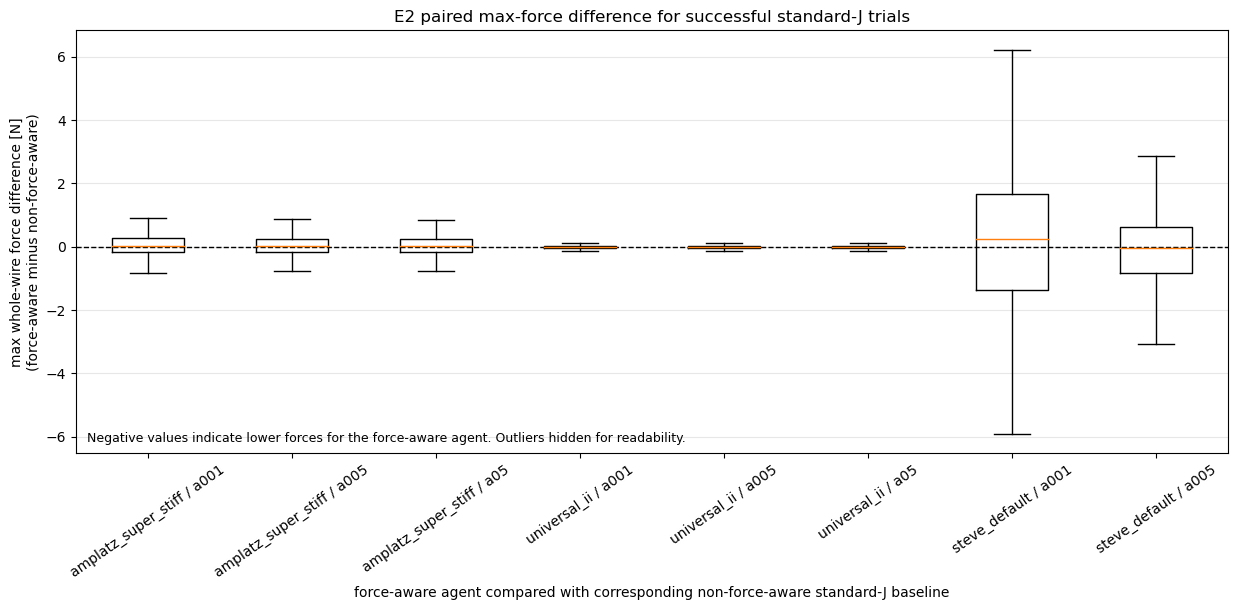

### Paired force-aware vs non-force-aware force comparison

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_detail.csv`

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_summary.csv`

Saved boxplot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_boxplot.png`

,wire_model,force_alpha,n_matched_successful_trials,mean_force_diff_N,median_force_diff_N,mean_tip_force_diff_N,force_aware_lower_force_percent,ci_low_mean_force_diff_N,ci_high_mean_force_diff_N,p_mean_diff_below_zero,significantly_lower_force_95,significantly_higher_force_95
0,amplatz_super_stiff,a001,415373,-0.3936,0.0341,-0.0424,45.3905,-0.5555,-0.2448,1.0000,True,False
1,amplatz_super_stiff,a005,448161,-0.1108,0.0346,0.0165,44.9501,-0.2701,0.0448,0.9232,False,False
2,amplatz_super_stiff,a05,446002,-0.4486,0.0286,-0.0594,45.7854,-0.5913,-0.3127,1.0000,True,False
3,steve_default,a001,153066,0.0887,0.2591,1.5093,44.6886,0.0682,0.1088,0.0000,False,True
4,steve_default,a005,106830,-0.4249,-0.0252,0.2043,51.1748,-0.4422,-0.4076,1.0000,True,False
5,universal_ii,a001,418712,-0.0496,-0.0059,-0.0094,55.9339,-0.0733,-0.0286,1.0000,True,False
6,universal_ii,a005,405125,-0.0278,-0.0041,-0.0172,53.9029,-0.0535,-0.0046,0.9912,True,False
7,universal_ii,a05,421282,-0.0573,-0.0013,-0.0100,51.1876,-0.0805,-0.0358,1.0000,True,False


,anatomy_target_key,branch,wire_model,force_alpha,trial_index,wire_force_force_aware_N,wire_force_non_force_N,wire_force_diff_N,tip_force_force_aware_N,tip_force_non_force_N,tip_force_diff_N,force_aware_lower_wire_force
0,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,0,0.6277,0.3411,0.2866,0.1458,0.2294,-0.0836,False
3,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,1,0.5767,0.2925,0.2842,0.2341,0.0861,0.1480,False
6,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,2,0.4967,0.4356,0.0610,0.1720,0.1011,0.0709,False
9,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,3,0.3947,0.6444,-0.2496,0.2846,0.2714,0.0132,True
11,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,4,0.3823,0.3189,0.0634,0.1258,0.2225,-0.0967,False
13,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,5,0.2218,0.4851,-0.2634,0.0988,0.2373,-0.1385,True
16,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,6,0.3303,0.6378,-0.3075,0.1011,0.1373,-0.0362,True
19,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,7,0.2018,0.4458,-0.2440,0.1910,0.1370,0.0540,True
22,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,8,0.2194,0.2795,-0.0601,0.1020,0.1172,-0.0152,True
25,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,9,0.2682,0.4673,-0.1992,0.2682,0.1061,0.1621,True


In [32]:
# Paired force comparison between force-aware and corresponding non-force-aware standard-J agents.
# This streams per-job trials.csv files instead of loading both full E2 trial caches into memory.
# Negative force difference means the force-aware agent produced lower maximum whole-wire force.
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Keep this cell runnable on its own after the general notebook imports.
# If the notebook setup variables already exist, these assignments leave them unchanged.
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

try:
    E2_NON_FORCE_RESULT_ROOT
except NameError:
    E2_NON_FORCE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_tinyfat_finished_readable_20260515"

try:
    E2_FORCE_AWARE_RESULT_ROOT
except NameError:
    E2_FORCE_AWARE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_force_aware_20260515"

try:
    E2_SCORE_OUTPUT_DIR
except NameError:
    E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def success_to_float(series):
    """Convert bool/string/numeric success values to 1.0 or 0.0."""
    mapped = series.map({
        True: 1.0,
        False: 0.0,
        "true": 1.0,
        "false": 0.0,
        "True": 1.0,
        "False": 0.0,
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)

E2_FORCE_COMPARISON_BOOT_N = 10000
E2_FORCE_COMPARISON_BOOT_SEED = 123
E2_FORCE_COMPARISON_MAX_RUNS = None  # set to a small integer while testing; None processes all matched runs
E2_FORCE_COMPARISON_PROGRESS_EVERY = 100

standard_j_wires = [
    "amplatz_super_stiff/standard_j",
    "universal_ii/standard_j",
    "steve_default/standard_j",
]
needed_cols = [
    "candidate_name",
    "execution_wire",
    "success",
    "trial_index",
    "wire_force_normal_trial_max_N",
    "tip_force_normal_trial_max_N",
]

def e2_run_dirs(root):
    runs_root = root / "runs" / "config_4"
    if not runs_root.exists():
        return {}
    return {run_dir.name: run_dir for run_dir in sorted(runs_root.iterdir()) if (run_dir / "trials.csv").exists()}

def e2_parse_branch_from_run_key(run_key):
    parts = str(run_key).split("__")
    return parts[2] if len(parts) >= 3 else np.nan

def e2_read_small_trial_csv(csv_path):
    return pd.read_csv(csv_path, usecols=lambda col: col in needed_cols)

def e2_prepare_successful_standard_j_non_force(df):
    df = df.loc[df["execution_wire"].isin(standard_j_wires)].copy()
    df["success_float"] = success_to_float(df["success"])
    df = df.loc[df["success_float"].eq(1.0)].copy()
    df["wire_model"] = df["execution_wire"].astype(str).str.split("/").str[0]
    df["wire_force_non_force_N"] = pd.to_numeric(df["wire_force_normal_trial_max_N"], errors="coerce")
    df["tip_force_non_force_N"] = pd.to_numeric(df["tip_force_normal_trial_max_N"], errors="coerce")
    return df[["wire_model", "trial_index", "wire_force_non_force_N", "tip_force_non_force_N"]]

def e2_prepare_successful_standard_j_force_aware(df):
    df = df.loc[df["execution_wire"].isin(standard_j_wires)].copy()
    df["success_float"] = success_to_float(df["success"])
    df = df.loc[df["success_float"].eq(1.0)].copy()
    df["wire_model"] = df["execution_wire"].astype(str).str.split("/").str[0]
    df["force_alpha"] = df["candidate_name"].astype(str).str.extract(r"_(a\d+)_force_aware$")[0]
    df["force_alpha"] = df["force_alpha"].fillna("unknown")
    df["wire_force_force_aware_N"] = pd.to_numeric(df["wire_force_normal_trial_max_N"], errors="coerce")
    df["tip_force_force_aware_N"] = pd.to_numeric(df["tip_force_normal_trial_max_N"], errors="coerce")
    return df[[
        "wire_model",
        "force_alpha",
        "trial_index",
        "wire_force_force_aware_N",
        "tip_force_force_aware_N",
    ]]

def e2_bootstrap_mean_ci(values, n_boot=10000, seed=123):
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return pd.Series({
            "ci_low_mean_force_diff_N": np.nan,
            "ci_high_mean_force_diff_N": np.nan,
            "p_mean_diff_below_zero": np.nan,
        })
    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)
    for boot_idx in range(n_boot):
        boot_means[boot_idx] = rng.choice(values, size=len(values), replace=True).mean()
    return pd.Series({
        "ci_low_mean_force_diff_N": float(np.quantile(boot_means, 0.025)),
        "ci_high_mean_force_diff_N": float(np.quantile(boot_means, 0.975)),
        "p_mean_diff_below_zero": float((boot_means < 0).mean()),
    })

non_force_runs = e2_run_dirs(E2_NON_FORCE_RESULT_ROOT)
force_aware_runs = e2_run_dirs(E2_FORCE_AWARE_RESULT_ROOT)
matched_run_keys = sorted(set(non_force_runs) & set(force_aware_runs))
if E2_FORCE_COMPARISON_MAX_RUNS is not None:
    matched_run_keys = matched_run_keys[:E2_FORCE_COMPARISON_MAX_RUNS]

if not matched_run_keys:
    display(Markdown("No matching force-aware and non-force-aware run folders with `trials.csv` were found."))
else:
    display(Markdown(
        f"Streaming **{len(matched_run_keys)}** matched E2 run folders. "
        "Only successful standard-J trials are retained for the force comparison."
    ))

    paired_parts = []
    skipped_runs = 0
    for run_number, run_key in enumerate(matched_run_keys, start=1):
        try:
            non_force_df = e2_read_small_trial_csv(non_force_runs[run_key] / "trials.csv")
            force_aware_df = e2_read_small_trial_csv(force_aware_runs[run_key] / "trials.csv")
            non_force_standard_j = e2_prepare_successful_standard_j_non_force(non_force_df)
            force_aware_standard_j = e2_prepare_successful_standard_j_force_aware(force_aware_df)
            paired = force_aware_standard_j.merge(
                non_force_standard_j,
                on=["wire_model", "trial_index"],
                how="inner",
            )
        except Exception as exc:
            skipped_runs += 1
            if skipped_runs <= 10:
                print(f"skipping {run_key}: {exc}")
            continue

        if paired.empty:
            continue

        paired["anatomy_target_key"] = run_key
        paired["branch"] = e2_parse_branch_from_run_key(run_key)
        paired["wire_force_diff_N"] = paired["wire_force_force_aware_N"] - paired["wire_force_non_force_N"]
        paired["tip_force_diff_N"] = paired["tip_force_force_aware_N"] - paired["tip_force_non_force_N"]
        paired["force_aware_lower_wire_force"] = paired["wire_force_diff_N"].lt(0)
        paired = paired[[
            "anatomy_target_key",
            "branch",
            "wire_model",
            "force_alpha",
            "trial_index",
            "wire_force_force_aware_N",
            "wire_force_non_force_N",
            "wire_force_diff_N",
            "tip_force_force_aware_N",
            "tip_force_non_force_N",
            "tip_force_diff_N",
            "force_aware_lower_wire_force",
        ]]
        paired_parts.append(paired)

        if run_number % E2_FORCE_COMPARISON_PROGRESS_EVERY == 0:
            rows_so_far = sum(len(part) for part in paired_parts)
            print(f"processed_runs={run_number} paired_successful_trials={rows_so_far:,} latest={run_key}")

    if not paired_parts:
        display(Markdown("No matched successful standard-J trials were found."))
    else:
        force_diff_df = pd.concat(paired_parts, ignore_index=True)
        force_diff_df = force_diff_df.sort_values(["wire_model", "force_alpha", "anatomy_target_key", "trial_index"])

        detail_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_detail.csv"
        force_diff_df.to_csv(detail_csv, index=False)

        summary = (
            force_diff_df
            .groupby(["wire_model", "force_alpha"], dropna=False)
            .agg(
                n_matched_successful_trials=("wire_force_diff_N", "count"),
                mean_force_diff_N=("wire_force_diff_N", "mean"),
                median_force_diff_N=("wire_force_diff_N", "median"),
                mean_tip_force_diff_N=("tip_force_diff_N", "mean"),
                force_aware_lower_force_percent=("force_aware_lower_wire_force", lambda s: 100.0 * float(s.mean())),
            )
            .reset_index()
        )
        ci_rows = (
            force_diff_df
            .groupby(["wire_model", "force_alpha"], dropna=False)["wire_force_diff_N"]
            .apply(lambda values: e2_bootstrap_mean_ci(
                values,
                n_boot=E2_FORCE_COMPARISON_BOOT_N,
                seed=E2_FORCE_COMPARISON_BOOT_SEED,
            ))
            .unstack()
            .reset_index()
        )
        summary = summary.merge(ci_rows, on=["wire_model", "force_alpha"], how="left")
        summary["significantly_lower_force_95"] = summary["ci_high_mean_force_diff_N"].lt(0)
        summary["significantly_higher_force_95"] = summary["ci_low_mean_force_diff_N"].gt(0)
        summary = summary.sort_values(["wire_model", "force_alpha"])

        summary_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_summary.csv"
        summary.to_csv(summary_csv, index=False)

        plot_df = force_diff_df.copy()
        alpha_order = ["a001", "a005", "a05", "unknown"]
        wire_order = ["amplatz_super_stiff", "universal_ii", "steve_default"]
        plot_df["plot_label"] = plot_df["wire_model"] + " / " + plot_df["force_alpha"]
        label_order = [
            f"{wire_model} / {alpha}"
            for wire_model in wire_order
            for alpha in alpha_order
            if ((plot_df["wire_model"].eq(wire_model)) & (plot_df["force_alpha"].eq(alpha))).any()
        ]
        data = [plot_df.loc[plot_df["plot_label"].eq(label), "wire_force_diff_N"].dropna().to_numpy() for label in label_order]

        fig, ax = plt.subplots(figsize=(12.5, 6.2))
        ax.boxplot(data, labels=label_order, showfliers=False)
        ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
        ax.set_title("E2 paired max-force difference for successful standard-J trials")
        ax.set_xlabel("force-aware agent compared with corresponding non-force-aware standard-J baseline")
        ax.set_ylabel("max whole-wire force difference [N]\n(force-aware minus non-force-aware)")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(axis="y", alpha=0.3)
        ax.text(
            0.01,
            0.02,
            "Negative values indicate lower forces for the force-aware agent. Outliers hidden for readability.",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
        )
        fig.tight_layout()
        boxplot_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_boxplot.png"
        boxplot_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_force_diff_boxplot.pdf"
        fig.savefig(boxplot_png, dpi=200, bbox_inches="tight")
        fig.savefig(boxplot_pdf, bbox_inches="tight")
        plt.show()

        display(Markdown("### Paired force-aware vs non-force-aware force comparison"))
        display(Markdown(f"Saved detail table: `{detail_csv}`"))
        display(Markdown(f"Saved summary table: `{summary_csv}`"))
        display(Markdown(f"Saved boxplot: `{boxplot_png}`"))
        display(summary.round(4))
        display(force_diff_df.head(20).round(4))


### 3.2.10 Paired Score Comparison: Force-Aware vs Non-Force-Aware Standard-J Agents

This section compares the E2 wire scores of the force-aware standard-J agents against the corresponding non-force-aware standard-J agent from the same wire family. The comparison is paired by anatomy-target group, so each difference is computed within the same anatomy and target. The bootstrap confidence interval is computed over anatomy-target groups with replacement. Positive values indicate that the force-aware agent has a higher score than the non-force-aware baseline.


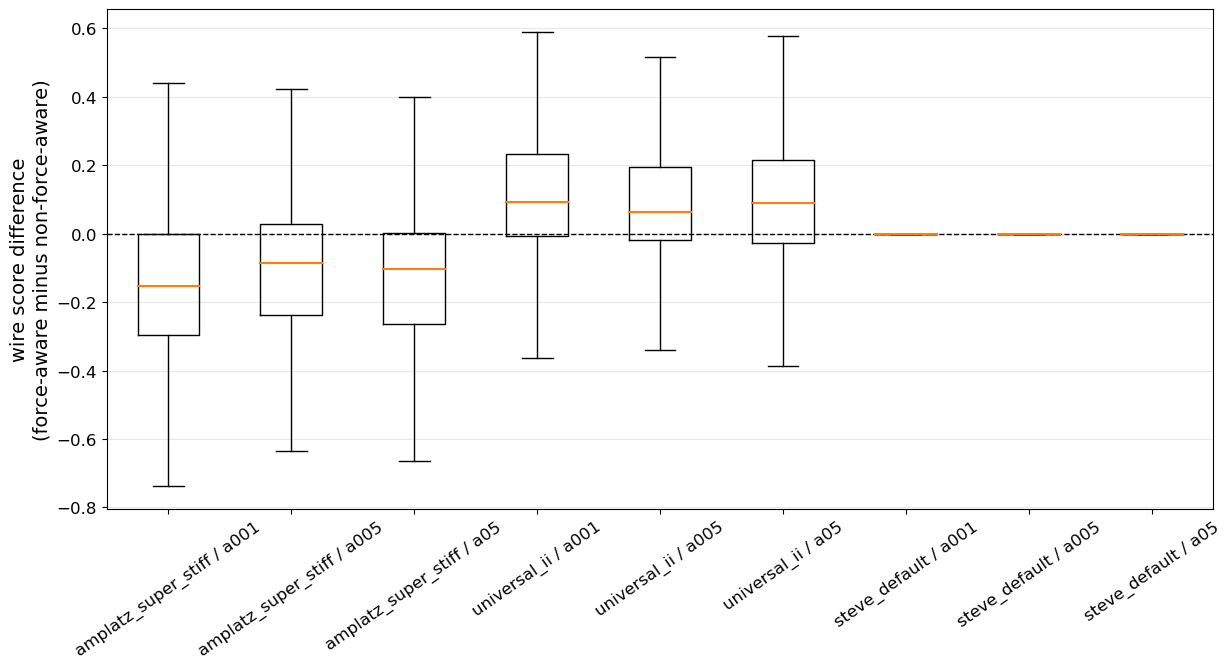

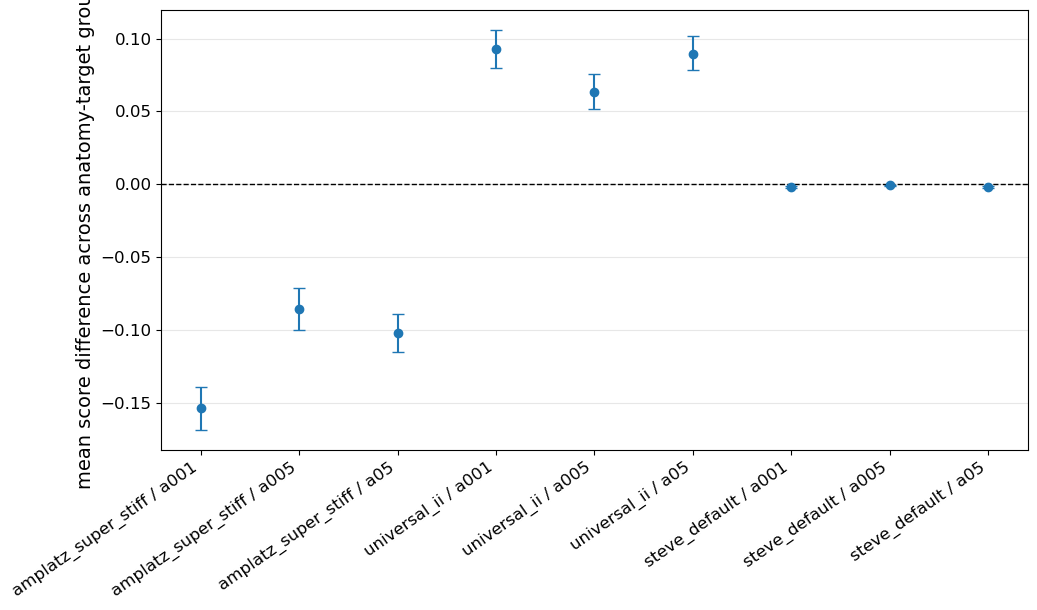

### Paired force-aware vs non-force-aware score comparison

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_score_diff_detail.csv`

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_score_diff_summary.csv`

Saved boxplot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_score_diff_boxplot.png`

Saved mean-difference CI plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_score_diff_mean_ci.png`

,wire_model,force_alpha,n_anatomy_targets,mean_score_diff,median_score_diff,min_score_diff,max_score_diff,mean_efficiency_component_diff,mean_safety_component_diff,mean_valid_rate_diff,mean_success_rate_diff,mean_wire_force_diff_N,force_aware_higher_score_percent,ci_low_mean_score_diff,ci_high_mean_score_diff,p_mean_score_diff_above_zero,significantly_higher_score_95,significantly_lower_score_95
0,amplatz_super_stiff,a001,1700,-0.1536,-0.0761,-0.9494,0.8248,-0.0789,-0.0747,-0.1526,-0.1509,-0.5835,24.7647,-0.1683,-0.1390,0.0000,False,True
1,amplatz_super_stiff,a005,1700,-0.0854,-0.0172,-0.9089,0.9132,-0.0388,-0.0466,-0.0863,-0.0828,1.0078,37.9412,-0.1001,-0.0708,0.0000,False,True
2,amplatz_super_stiff,a05,1700,-0.1021,-0.0272,-0.8324,0.7551,-0.0495,-0.0526,-0.1048,-0.1039,0.8962,26.7059,-0.1150,-0.0890,0.0000,False,True
3,steve_default,a001,1700,-0.0016,0.0000,-0.4525,0.0298,-0.0015,-0.0001,-0.0034,-0.5670,-31.1004,0.1176,-0.0027,-0.0008,0.0000,False,True
4,steve_default,a005,1700,-0.0006,0.0000,-0.3591,0.1269,-0.0005,-0.0001,-0.0013,-0.6258,-32.0316,0.7647,-0.0012,-0.0002,0.0017,False,True
5,steve_default,a05,1700,-0.0017,0.0000,-0.4619,0.0000,-0.0016,-0.0002,-0.0036,-0.7543,-33.5767,0.0000,-0.0028,-0.0009,0.0000,False,True
6,universal_ii,a001,1700,0.0926,0.0445,-0.9360,0.9273,0.0452,0.0475,0.0951,0.0951,-0.0626,64.4118,0.0800,0.1059,1.0000,True,False
7,universal_ii,a005,1700,0.0637,0.0175,-0.9051,0.9236,0.0321,0.0316,0.0632,0.0631,0.0276,59.0588,0.0518,0.0758,1.0000,True,False
8,universal_ii,a05,1700,0.0896,0.0362,-0.9288,0.8502,0.0377,0.0519,0.1040,0.1039,-0.1242,59.8235,0.0782,0.1015,1.0000,True,False


,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,wire_model,force_alpha,force_aware_candidate_key,force_aware_candidate_name,force_aware_execution_wire,...,non_force_valid_rate,non_force_success_rate,non_force_mean_wire_force_max_N,score_diff,efficiency_component_diff,safety_component_diff,valid_rate_diff,success_rate_diff,mean_wire_force_diff_N,plot_label
0,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a001,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,...,0.988,0.990,0.4609,0.0510,0.0355,0.0155,0.002,0.000,-0.1155,amplatz_super_stiff / a001
1,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a005,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff_standard_j_a005_force_aware,amplatz_super_stiff/standard_j,...,0.988,0.990,0.4609,-0.0219,0.0252,-0.0471,-0.004,0.008,0.2158,amplatz_super_stiff / a005
2,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a05,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff_standard_j_a05_force_aware,amplatz_super_stiff/standard_j,...,0.988,0.990,0.4609,-0.1596,-0.0651,-0.0945,-0.220,-0.220,-0.0045,amplatz_super_stiff / a05
3,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a001,force_aware::steve_default/standard_j::a001,steve_default_standard_j_a001_force_aware,steve_default/standard_j,...,0.000,0.644,4.9113,0.0000,0.0000,0.0000,0.000,-0.644,-3.2965,steve_default / a001
4,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a005,force_aware::steve_default/standard_j::a005,steve_default_standard_j_a005_force_aware,steve_default/standard_j,...,0.000,0.644,4.9113,0.0000,0.0000,0.0000,0.000,-0.644,-4.3932,steve_default / a005
5,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a05,force_aware::steve_default/standard_j::a05,steve_default_standard_j_a05_force_aware,steve_default/standard_j,...,0.000,0.644,4.9113,0.0000,0.0000,0.0000,0.000,-0.644,-4.9113,steve_default / a05
6,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a001,force_aware::universal_ii/standard_j::a001,universal_ii_standard_j_a001_force_aware,universal_ii/standard_j,...,0.582,0.582,0.0592,0.4149,0.2068,0.2080,0.416,0.416,-0.0105,universal_ii / a001
7,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a005,force_aware::universal_ii/standard_j::a005,universal_ii_standard_j_a005_force_aware,universal_ii/standard_j,...,0.582,0.582,0.0592,0.3338,0.1512,0.1826,0.366,0.366,0.0154,universal_ii / a005
8,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a05,force_aware::universal_ii/standard_j::a05,universal_ii_standard_j_a05_force_aware,universal_ii/standard_j,...,0.582,0.582,0.0592,-0.4071,-0.1885,-0.2186,-0.438,-0.438,0.0285,universal_ii / a05
9,Tree_03__target_001__lcca,Tree_03,0,1,lcca,amplatz_super_stiff,a001,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,...,0.998,1.000,0.4227,-0.0237,-0.0077,-0.0160,-0.002,-0.002,0.1083,amplatz_super_stiff / a001


In [37]:
# Paired score comparison between force-aware and corresponding non-force-aware standard-J agents.
# Positive score difference means the force-aware agent scored higher than the non-force-aware baseline.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

try:
    E2_SCORE_OUTPUT_DIR
except NameError:
    E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E2_SCORE_DIFF_BOOT_N = 10000
E2_SCORE_DIFF_BOOT_SEED = 123

non_force_score_path = E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv"
force_aware_score_path = E2_SCORE_OUTPUT_DIR / "e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv"

missing_paths = [path for path in [non_force_score_path, force_aware_score_path] if not path.exists()]
if missing_paths:
    display(Markdown("Build the E2 bootstrap score tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    non_force_scores = pd.read_csv(non_force_score_path)
    force_aware_scores = pd.read_csv(force_aware_score_path)

    score_cols = [
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "wire_model",
        "wire_shape",
        "force_alpha",
        "candidate_key",
        "candidate_name",
        "execution_wire",
        "observed_wire_score",
        "observed_efficiency_component",
        "observed_safety_component",
        "valid_rate",
        "success_rate",
        "mean_wire_force_max_N",
    ]

    baseline = (
        non_force_scores
        .loc[
            non_force_scores["wire_shape"].eq("standard_j"),
            [col for col in score_cols if col in non_force_scores.columns],
        ]
        .copy()
    )
    baseline = baseline.rename(columns={
        "candidate_key": "non_force_candidate_key",
        "candidate_name": "non_force_candidate_name",
        "execution_wire": "non_force_execution_wire",
        "observed_wire_score": "non_force_score",
        "observed_efficiency_component": "non_force_efficiency_component",
        "observed_safety_component": "non_force_safety_component",
        "valid_rate": "non_force_valid_rate",
        "success_rate": "non_force_success_rate",
        "mean_wire_force_max_N": "non_force_mean_wire_force_max_N",
    })
    baseline = baseline.drop(columns=["wire_shape", "force_alpha"], errors="ignore")

    force_aware_standard_j = (
        force_aware_scores
        .loc[
            force_aware_scores["wire_shape"].eq("standard_j"),
            [col for col in score_cols if col in force_aware_scores.columns],
        ]
        .copy()
    )
    force_aware_standard_j = force_aware_standard_j.rename(columns={
        "candidate_key": "force_aware_candidate_key",
        "candidate_name": "force_aware_candidate_name",
        "execution_wire": "force_aware_execution_wire",
        "observed_wire_score": "force_aware_score",
        "observed_efficiency_component": "force_aware_efficiency_component",
        "observed_safety_component": "force_aware_safety_component",
        "valid_rate": "force_aware_valid_rate",
        "success_rate": "force_aware_success_rate",
        "mean_wire_force_max_N": "force_aware_mean_wire_force_max_N",
    })
    force_aware_standard_j = force_aware_standard_j.drop(columns=["wire_shape"], errors="ignore")

    paired_score_diff_df = force_aware_standard_j.merge(
        baseline,
        on=["anatomy_target_key", "anatomy_id", "anatomy_index", "target_index", "branch", "wire_model"],
        how="inner",
    )

    paired_score_diff_df["score_diff"] = paired_score_diff_df["force_aware_score"] - paired_score_diff_df["non_force_score"]
    paired_score_diff_df["efficiency_component_diff"] = paired_score_diff_df["force_aware_efficiency_component"] - paired_score_diff_df["non_force_efficiency_component"]
    paired_score_diff_df["safety_component_diff"] = paired_score_diff_df["force_aware_safety_component"] - paired_score_diff_df["non_force_safety_component"]
    paired_score_diff_df["valid_rate_diff"] = paired_score_diff_df["force_aware_valid_rate"] - paired_score_diff_df["non_force_valid_rate"]
    paired_score_diff_df["success_rate_diff"] = paired_score_diff_df["force_aware_success_rate"] - paired_score_diff_df["non_force_success_rate"]
    paired_score_diff_df["mean_wire_force_diff_N"] = paired_score_diff_df["force_aware_mean_wire_force_max_N"] - paired_score_diff_df["non_force_mean_wire_force_max_N"]

    def bootstrap_mean_diff_ci(values, n_boot=10000, seed=123):
        values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
        if len(values) == 0:
            return pd.Series({
                "ci_low_mean_score_diff": np.nan,
                "ci_high_mean_score_diff": np.nan,
                "p_mean_score_diff_above_zero": np.nan,
            })
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_boot, dtype=float)
        for boot_idx in range(n_boot):
            boot_sample = rng.choice(values, size=len(values), replace=True)
            boot_means[boot_idx] = boot_sample.mean()
        return pd.Series({
            "ci_low_mean_score_diff": float(np.quantile(boot_means, 0.025)),
            "ci_high_mean_score_diff": float(np.quantile(boot_means, 0.975)),
            "p_mean_score_diff_above_zero": float((boot_means > 0).mean()),
        })

    score_diff_summary = (
        paired_score_diff_df
        .groupby(["wire_model", "force_alpha"], dropna=False)
        .agg(
            n_anatomy_targets=("score_diff", "count"),
            mean_score_diff=("score_diff", "mean"),
            median_score_diff=("score_diff", "median"),
            min_score_diff=("score_diff", "min"),
            max_score_diff=("score_diff", "max"),
            mean_efficiency_component_diff=("efficiency_component_diff", "mean"),
            mean_safety_component_diff=("safety_component_diff", "mean"),
            mean_valid_rate_diff=("valid_rate_diff", "mean"),
            mean_success_rate_diff=("success_rate_diff", "mean"),
            mean_wire_force_diff_N=("mean_wire_force_diff_N", "mean"),
            force_aware_higher_score_percent=("score_diff", lambda s: 100.0 * float((s > 0).mean())),
        )
        .reset_index()
    )
    score_diff_ci = (
        paired_score_diff_df
        .groupby(["wire_model", "force_alpha"], dropna=False)["score_diff"]
        .apply(lambda values: bootstrap_mean_diff_ci(
            values,
            n_boot=E2_SCORE_DIFF_BOOT_N,
            seed=E2_SCORE_DIFF_BOOT_SEED,
        ))
        .unstack()
        .reset_index()
    )
    score_diff_summary = score_diff_summary.merge(score_diff_ci, on=["wire_model", "force_alpha"], how="left")
    score_diff_summary["significantly_higher_score_95"] = score_diff_summary["ci_low_mean_score_diff"].gt(0)
    score_diff_summary["significantly_lower_score_95"] = score_diff_summary["ci_high_mean_score_diff"].lt(0)
    score_diff_summary = score_diff_summary.sort_values(["wire_model", "force_alpha"])

    detail_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_detail.csv"
    summary_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_summary.csv"
    paired_score_diff_df.to_csv(detail_csv, index=False)
    score_diff_summary.to_csv(summary_csv, index=False)

    alpha_order = ["a001", "a005", "a05", "unknown"]
    wire_order = ["amplatz_super_stiff", "universal_ii", "steve_default"]
    paired_score_diff_df["plot_label"] = paired_score_diff_df["wire_model"] + " / " + paired_score_diff_df["force_alpha"].astype(str)
    label_order = [
        f"{wire_model} / {alpha}"
        for wire_model in wire_order
        for alpha in alpha_order
        if ((paired_score_diff_df["wire_model"].eq(wire_model)) & (paired_score_diff_df["force_alpha"].astype(str).eq(alpha))).any()
    ]

    box_data = [
        paired_score_diff_df.loc[paired_score_diff_df["plot_label"].eq(label), "score_diff"].dropna().to_numpy()
        for label in label_order
    ]
    fig, ax = plt.subplots(figsize=(12.5, 6.8))
    ax.boxplot(
        box_data,
        labels=label_order,
        showfliers=False,
        showmeans=True,
        meanline=True,
        meanprops={"color": "#ff7f0e", "linewidth": 1.5, "linestyle": "-"},
        medianprops={"color": "none", "linewidth": 0.0},
    )
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_ylabel("wire score difference\n(force-aware minus non-force-aware)", fontsize=14)
    ax.tick_params(axis="x", rotation=35, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(axis="y", alpha=0.3)
    #ax.text(
    #    0.01,
    #    0.02,
    #    "Positive values indicate higher E2 score for the force-aware agent. Outliers hidden for readability.",
    #    transform=ax.transAxes,
    #    ha="left",
    #    va="bottom",
    #    fontsize=9,
    #)
    fig.tight_layout()
    boxplot_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_boxplot.png"
    boxplot_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_boxplot.pdf"
    fig.savefig(boxplot_png, dpi=200, bbox_inches="tight")
    fig.savefig(boxplot_pdf, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10.5, 6.2))
    plot_summary = score_diff_summary.copy()
    plot_summary["plot_label"] = plot_summary["wire_model"] + " / " + plot_summary["force_alpha"].astype(str)
    plot_summary = plot_summary.set_index("plot_label").reindex(label_order).reset_index()
    yerr = np.vstack([
        plot_summary["mean_score_diff"] - plot_summary["ci_low_mean_score_diff"],
        plot_summary["ci_high_mean_score_diff"] - plot_summary["mean_score_diff"],
    ])
    ax.errorbar(
        x=np.arange(len(plot_summary)),
        y=plot_summary["mean_score_diff"],
        yerr=yerr,
        fmt="o",
        capsize=4,
        color="tab:blue",
    )
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_xticks(np.arange(len(plot_summary)))
    ax.set_xticklabels(plot_summary["plot_label"], rotation=35, ha="right", fontsize=12)
    ax.set_ylabel("mean score difference across anatomy-target groups", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    ci_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_mean_ci.png"
    ci_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_score_diff_mean_ci.pdf"
    fig.savefig(ci_png, dpi=200, bbox_inches="tight")
    fig.savefig(ci_pdf, bbox_inches="tight")
    plt.show()

    display(Markdown("### Paired force-aware vs non-force-aware score comparison"))
    display(Markdown(f"Saved detail table: `{detail_csv}`"))
    display(Markdown(f"Saved summary table: `{summary_csv}`"))
    display(Markdown(f"Saved boxplot: `{boxplot_png}`"))
    display(Markdown(f"Saved mean-difference CI plot: `{ci_png}`"))
    display(score_diff_summary.round(4))
    display(paired_score_diff_df.head(20).round(4))


### 3.2.11 Paired Success-Rate Comparison: Force-Aware vs Non-Force-Aware Standard-J Agents

This section compares only the success rate, independent of the E2 score and independent of whether a trial exceeded the force threshold. The force-aware standard-J agents are paired with the corresponding non-force-aware standard-J baseline from the same wire family and anatomy-target group. Positive values indicate a higher success rate for the force-aware agent.


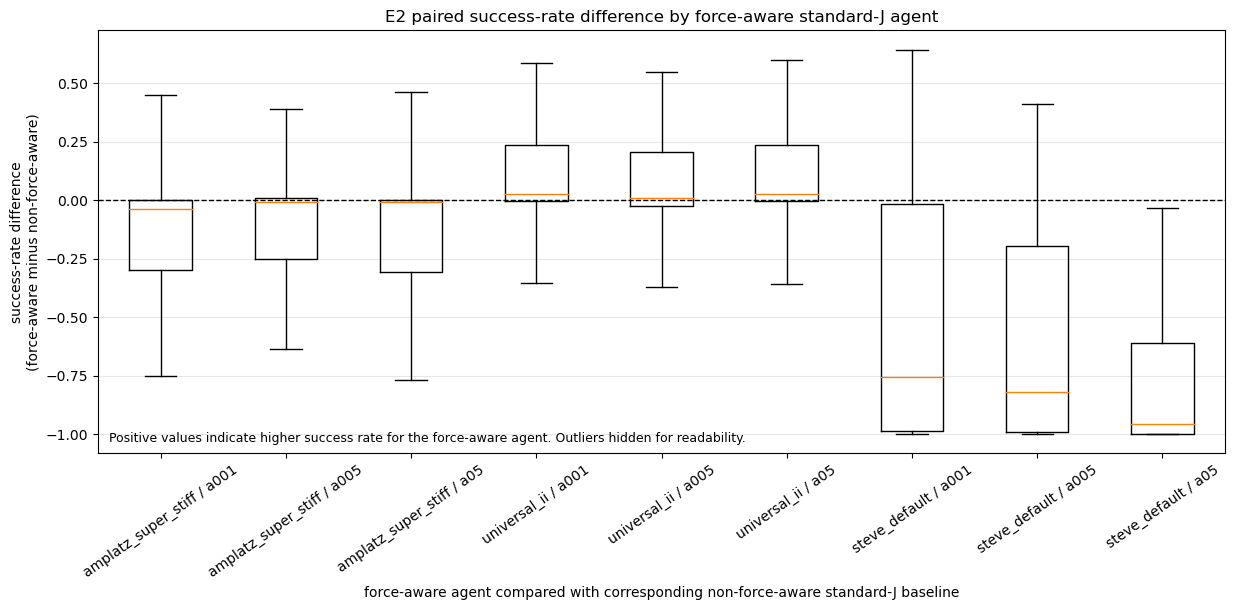

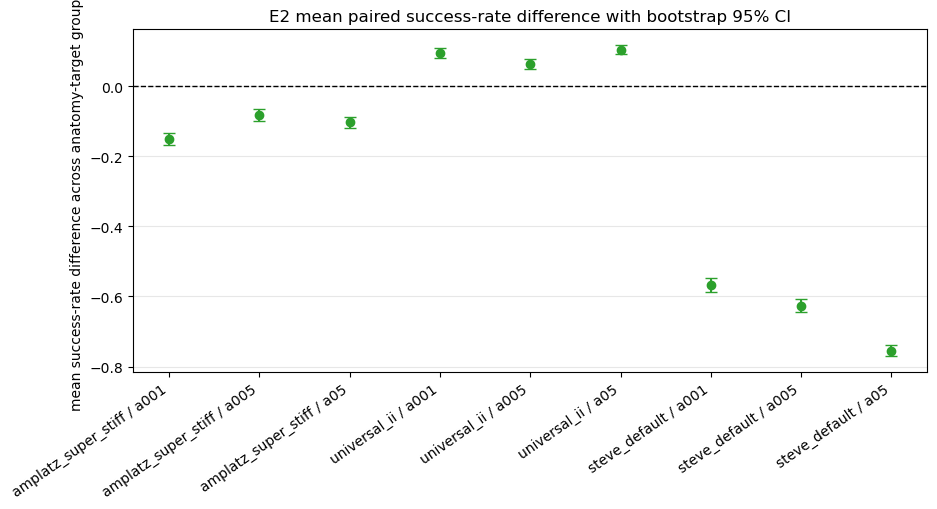

### Paired force-aware vs non-force-aware success-rate comparison

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_detail.csv`

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_summary.csv`

Saved boxplot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_boxplot.png`

Saved mean-difference CI plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_mean_ci.png`

,wire_model,force_alpha,n_anatomy_targets,mean_success_rate_force_aware,mean_success_rate_non_force,mean_success_rate_diff,median_success_rate_diff,min_success_rate_diff,max_success_rate_diff,force_aware_higher_success_percent,force_aware_equal_success_percent,force_aware_lower_success_percent,ci_low_mean_success_rate_diff,ci_high_mean_success_rate_diff,p_mean_success_rate_diff_above_zero,significantly_higher_success_95,significantly_lower_success_95
0,amplatz_super_stiff,a001,1700,0.5691,0.7199,-0.1509,-0.037,-1.000,1.000,23.5882,7.9412,68.4706,-0.1678,-0.1336,0.0,False,True
1,amplatz_super_stiff,a005,1700,0.6372,0.7199,-0.0828,-0.006,-1.000,1.000,27.0588,18.8235,54.1176,-0.1003,-0.0651,0.0,False,True
2,amplatz_super_stiff,a05,1700,0.6161,0.7199,-0.1039,-0.008,-1.000,1.000,23.4118,20.5882,56.0000,-0.1204,-0.0874,0.0,False,True
3,steve_default,a001,1700,0.1873,0.7543,-0.5670,-0.755,-1.000,0.644,10.4706,8.4706,81.0588,-0.5876,-0.5460,0.0,False,True
4,steve_default,a005,1700,0.1285,0.7543,-0.6258,-0.819,-1.000,0.410,4.3529,6.5294,89.1176,-0.6449,-0.6061,0.0,False,True
5,steve_default,a05,1700,0.0000,0.7543,-0.7543,-0.957,-1.000,0.000,0.0000,3.2941,96.7059,-0.7705,-0.7379,0.0,False,True
6,universal_ii,a001,1700,0.6811,0.5860,0.0951,0.028,-1.000,0.986,57.7059,15.7647,26.5294,0.0810,0.1097,1.0,True,False
7,universal_ii,a005,1700,0.6491,0.5860,0.0631,0.008,-0.998,0.998,52.0588,16.8235,31.1176,0.0497,0.0764,1.0,True,False
8,universal_ii,a05,1700,0.6899,0.5860,0.1039,0.026,-1.000,0.948,57.5294,16.0000,26.4706,0.0912,0.1172,1.0,True,False


,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,wire_model,force_alpha,force_aware_candidate_key,force_aware_candidate_name,force_aware_execution_wire,force_aware_success_rate,force_aware_n_trials_available,non_force_candidate_key,non_force_candidate_name,non_force_execution_wire,non_force_success_rate,non_force_n_trials_available,success_rate_diff,plot_label
0,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a001,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,0.990,500,non_force_aware::amplatz_super_stiff/standard_j,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,0.990,500,0.000,amplatz_super_stiff / a001
1,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a005,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff_standard_j_a005_force_aware,amplatz_super_stiff/standard_j,0.998,500,non_force_aware::amplatz_super_stiff/standard_j,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,0.990,500,0.008,amplatz_super_stiff / a005
2,Tree_03__target_000__bct,Tree_03,0,0,bct,amplatz_super_stiff,a05,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff_standard_j_a05_force_aware,amplatz_super_stiff/standard_j,0.770,500,non_force_aware::amplatz_super_stiff/standard_j,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,0.990,500,-0.220,amplatz_super_stiff / a05
3,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a001,force_aware::steve_default/standard_j::a001,steve_default_standard_j_a001_force_aware,steve_default/standard_j,0.000,500,non_force_aware::steve_default/standard_j,archvar_steve_standard_j_best,steve_default/standard_j,0.644,500,-0.644,steve_default / a001
4,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a005,force_aware::steve_default/standard_j::a005,steve_default_standard_j_a005_force_aware,steve_default/standard_j,0.000,500,non_force_aware::steve_default/standard_j,archvar_steve_standard_j_best,steve_default/standard_j,0.644,500,-0.644,steve_default / a005
5,Tree_03__target_000__bct,Tree_03,0,0,bct,steve_default,a05,force_aware::steve_default/standard_j::a05,steve_default_standard_j_a05_force_aware,steve_default/standard_j,0.000,500,non_force_aware::steve_default/standard_j,archvar_steve_standard_j_best,steve_default/standard_j,0.644,500,-0.644,steve_default / a05
6,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a001,force_aware::universal_ii/standard_j::a001,universal_ii_standard_j_a001_force_aware,universal_ii/standard_j,0.998,500,non_force_aware::universal_ii/standard_j,archvar_universalii_standard_j_best,universal_ii/standard_j,0.582,500,0.416,universal_ii / a001
7,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a005,force_aware::universal_ii/standard_j::a005,universal_ii_standard_j_a005_force_aware,universal_ii/standard_j,0.948,500,non_force_aware::universal_ii/standard_j,archvar_universalii_standard_j_best,universal_ii/standard_j,0.582,500,0.366,universal_ii / a005
8,Tree_03__target_000__bct,Tree_03,0,0,bct,universal_ii,a05,force_aware::universal_ii/standard_j::a05,universal_ii_standard_j_a05_force_aware,universal_ii/standard_j,0.144,500,non_force_aware::universal_ii/standard_j,archvar_universalii_standard_j_best,universal_ii/standard_j,0.582,500,-0.438,universal_ii / a05
9,Tree_03__target_001__lcca,Tree_03,0,1,lcca,amplatz_super_stiff,a001,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff_standard_j_a001_force_aware,amplatz_super_stiff/standard_j,0.998,500,non_force_aware::amplatz_super_stiff/standard_j,archvar_amplatz_standard_j_best,amplatz_super_stiff/standard_j,1.000,500,-0.002,amplatz_super_stiff / a001


In [34]:
# Paired success-rate comparison between force-aware and corresponding non-force-aware standard-J agents.
# This uses only success_rate from the existing score tables; score, force penalty, and efficiency do not enter.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

try:
    E2_SCORE_OUTPUT_DIR
except NameError:
    E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E2_SUCCESS_DIFF_BOOT_N = 10000
E2_SUCCESS_DIFF_BOOT_SEED = 123

non_force_score_path = E2_SCORE_OUTPUT_DIR / "e2_non_force_aware_wire_score_bootstrap_ci_k500_b1000.csv"
force_aware_score_path = E2_SCORE_OUTPUT_DIR / "e2_force_aware_wire_score_bootstrap_ci_k500_b1000.csv"

missing_paths = [path for path in [non_force_score_path, force_aware_score_path] if not path.exists()]
if missing_paths:
    display(Markdown("Build the E2 bootstrap score tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    non_force_scores = pd.read_csv(non_force_score_path)
    force_aware_scores = pd.read_csv(force_aware_score_path)

    keep_cols = [
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "wire_model",
        "wire_shape",
        "force_alpha",
        "candidate_key",
        "candidate_name",
        "execution_wire",
        "success_rate",
        "n_trials_available",
    ]

    baseline_success = (
        non_force_scores
        .loc[
            non_force_scores["wire_shape"].eq("standard_j"),
            [col for col in keep_cols if col in non_force_scores.columns],
        ]
        .copy()
        .rename(columns={
            "candidate_key": "non_force_candidate_key",
            "candidate_name": "non_force_candidate_name",
            "execution_wire": "non_force_execution_wire",
            "success_rate": "non_force_success_rate",
            "n_trials_available": "non_force_n_trials_available",
        })
        .drop(columns=["wire_shape", "force_alpha"], errors="ignore")
    )

    force_aware_success = (
        force_aware_scores
        .loc[
            force_aware_scores["wire_shape"].eq("standard_j"),
            [col for col in keep_cols if col in force_aware_scores.columns],
        ]
        .copy()
        .rename(columns={
            "candidate_key": "force_aware_candidate_key",
            "candidate_name": "force_aware_candidate_name",
            "execution_wire": "force_aware_execution_wire",
            "success_rate": "force_aware_success_rate",
            "n_trials_available": "force_aware_n_trials_available",
        })
        .drop(columns=["wire_shape"], errors="ignore")
    )

    paired_success_diff_df = force_aware_success.merge(
        baseline_success,
        on=["anatomy_target_key", "anatomy_id", "anatomy_index", "target_index", "branch", "wire_model"],
        how="inner",
    )
    paired_success_diff_df["success_rate_diff"] = (
        paired_success_diff_df["force_aware_success_rate"]
        - paired_success_diff_df["non_force_success_rate"]
    )

    def bootstrap_mean_ci(values, n_boot=10000, seed=123):
        values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
        if len(values) == 0:
            return pd.Series({
                "ci_low_mean_success_rate_diff": np.nan,
                "ci_high_mean_success_rate_diff": np.nan,
                "p_mean_success_rate_diff_above_zero": np.nan,
            })
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_boot, dtype=float)
        for boot_idx in range(n_boot):
            boot_means[boot_idx] = rng.choice(values, size=len(values), replace=True).mean()
        return pd.Series({
            "ci_low_mean_success_rate_diff": float(np.quantile(boot_means, 0.025)),
            "ci_high_mean_success_rate_diff": float(np.quantile(boot_means, 0.975)),
            "p_mean_success_rate_diff_above_zero": float((boot_means > 0).mean()),
        })

    success_diff_summary = (
        paired_success_diff_df
        .groupby(["wire_model", "force_alpha"], dropna=False)
        .agg(
            n_anatomy_targets=("success_rate_diff", "count"),
            mean_success_rate_force_aware=("force_aware_success_rate", "mean"),
            mean_success_rate_non_force=("non_force_success_rate", "mean"),
            mean_success_rate_diff=("success_rate_diff", "mean"),
            median_success_rate_diff=("success_rate_diff", "median"),
            min_success_rate_diff=("success_rate_diff", "min"),
            max_success_rate_diff=("success_rate_diff", "max"),
            force_aware_higher_success_percent=("success_rate_diff", lambda s: 100.0 * float((s > 0).mean())),
            force_aware_equal_success_percent=("success_rate_diff", lambda s: 100.0 * float((s == 0).mean())),
            force_aware_lower_success_percent=("success_rate_diff", lambda s: 100.0 * float((s < 0).mean())),
        )
        .reset_index()
    )

    success_diff_ci = (
        paired_success_diff_df
        .groupby(["wire_model", "force_alpha"], dropna=False)["success_rate_diff"]
        .apply(lambda values: bootstrap_mean_ci(
            values,
            n_boot=E2_SUCCESS_DIFF_BOOT_N,
            seed=E2_SUCCESS_DIFF_BOOT_SEED,
        ))
        .unstack()
        .reset_index()
    )
    success_diff_summary = success_diff_summary.merge(success_diff_ci, on=["wire_model", "force_alpha"], how="left")
    success_diff_summary["significantly_higher_success_95"] = success_diff_summary["ci_low_mean_success_rate_diff"].gt(0)
    success_diff_summary["significantly_lower_success_95"] = success_diff_summary["ci_high_mean_success_rate_diff"].lt(0)
    success_diff_summary = success_diff_summary.sort_values(["wire_model", "force_alpha"])

    detail_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_detail.csv"
    summary_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_summary.csv"
    paired_success_diff_df.to_csv(detail_csv, index=False)
    success_diff_summary.to_csv(summary_csv, index=False)

    alpha_order = ["a001", "a005", "a05", "unknown"]
    wire_order = ["amplatz_super_stiff", "universal_ii", "steve_default"]
    paired_success_diff_df["plot_label"] = paired_success_diff_df["wire_model"] + " / " + paired_success_diff_df["force_alpha"].astype(str)
    label_order = [
        f"{wire_model} / {alpha}"
        for wire_model in wire_order
        for alpha in alpha_order
        if ((paired_success_diff_df["wire_model"].eq(wire_model)) & (paired_success_diff_df["force_alpha"].astype(str).eq(alpha))).any()
    ]

    box_data = [
        paired_success_diff_df.loc[paired_success_diff_df["plot_label"].eq(label), "success_rate_diff"].dropna().to_numpy()
        for label in label_order
    ]
    fig, ax = plt.subplots(figsize=(12.5, 6.2))
    ax.boxplot(box_data, labels=label_order, showfliers=False)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_title("E2 paired success-rate difference by force-aware standard-J agent")
    ax.set_xlabel("force-aware agent compared with corresponding non-force-aware standard-J baseline")
    ax.set_ylabel("success-rate difference\n(force-aware minus non-force-aware)")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.3)
    ax.text(
        0.01,
        0.02,
        "Positive values indicate higher success rate for the force-aware agent. Outliers hidden for readability.",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
    )
    fig.tight_layout()
    boxplot_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_boxplot.png"
    boxplot_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_boxplot.pdf"
    fig.savefig(boxplot_png, dpi=200, bbox_inches="tight")
    fig.savefig(boxplot_pdf, bbox_inches="tight")
    plt.show()

    plot_summary = success_diff_summary.copy()
    plot_summary["plot_label"] = plot_summary["wire_model"] + " / " + plot_summary["force_alpha"].astype(str)
    plot_summary = plot_summary.set_index("plot_label").reindex(label_order).reset_index()
    yerr = np.vstack([
        plot_summary["mean_success_rate_diff"] - plot_summary["ci_low_mean_success_rate_diff"],
        plot_summary["ci_high_mean_success_rate_diff"] - plot_summary["mean_success_rate_diff"],
    ])

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    ax.errorbar(
        x=np.arange(len(plot_summary)),
        y=plot_summary["mean_success_rate_diff"],
        yerr=yerr,
        fmt="o",
        capsize=4,
        color="tab:green",
    )
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_xticks(np.arange(len(plot_summary)))
    ax.set_xticklabels(plot_summary["plot_label"], rotation=35, ha="right")
    ax.set_title("E2 mean paired success-rate difference with bootstrap 95% CI")
    ax.set_ylabel("mean success-rate difference across anatomy-target groups")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    ci_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_mean_ci.png"
    ci_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_success_rate_diff_mean_ci.pdf"
    fig.savefig(ci_png, dpi=200, bbox_inches="tight")
    fig.savefig(ci_pdf, bbox_inches="tight")
    plt.show()

    display(Markdown("### Paired force-aware vs non-force-aware success-rate comparison"))
    display(Markdown(f"Saved detail table: `{detail_csv}`"))
    display(Markdown(f"Saved summary table: `{summary_csv}`"))
    display(Markdown(f"Saved boxplot: `{boxplot_png}`"))
    display(Markdown(f"Saved mean-difference CI plot: `{ci_png}`"))
    display(success_diff_summary.round(4))
    display(paired_success_diff_df.head(20).round(4))


### 3.2.12 Paired Step-Count Comparison for Successful Standard-J Trials

This section compares the number of simulation steps needed to reach the target. It uses only trials where both the force-aware standard-J agent and the corresponding non-force-aware standard-J baseline from the same wire family were successful. Trials are matched within the same anatomy-target job by wire family and trial index. Negative values indicate that the force-aware agent reached the target in fewer steps.


Streaming **1700** matched E2 run folders. Only trials where both agents succeeded are retained for the step-count comparison.

processed_runs=100 paired_successful_trials=177,705 latest=Tree_1250__target_004__rsa__end__seedbase_108127
processed_runs=200 paired_successful_trials=351,040 latest=Tree_1469__target_004__rsa__end__seedbase_128127
processed_runs=300 paired_successful_trials=521,983 latest=Tree_1580__target_004__rsa__end__seedbase_145127
processed_runs=400 paired_successful_trials=689,628 latest=Tree_1782__target_004__rsa__end__seedbase_164127
processed_runs=500 paired_successful_trials=851,994 latest=Tree_1956__target_004__rsa__end__seedbase_181127
processed_runs=600 paired_successful_trials=1,015,610 latest=Tree_2134__target_004__rsa__end__seedbase_201127
processed_runs=700 paired_successful_trials=1,181,445 latest=Tree_2308__target_004__rsa__end__seedbase_219127
processed_runs=800 paired_successful_trials=1,355,080 latest=Tree_2508__target_004__rsa__end__seedbase_236127
processed_runs=900 paired_successful_trials=1,521,664 latest=Tree_2683__target_004__rsa__end__seedbase_254127
processed_runs=1000 

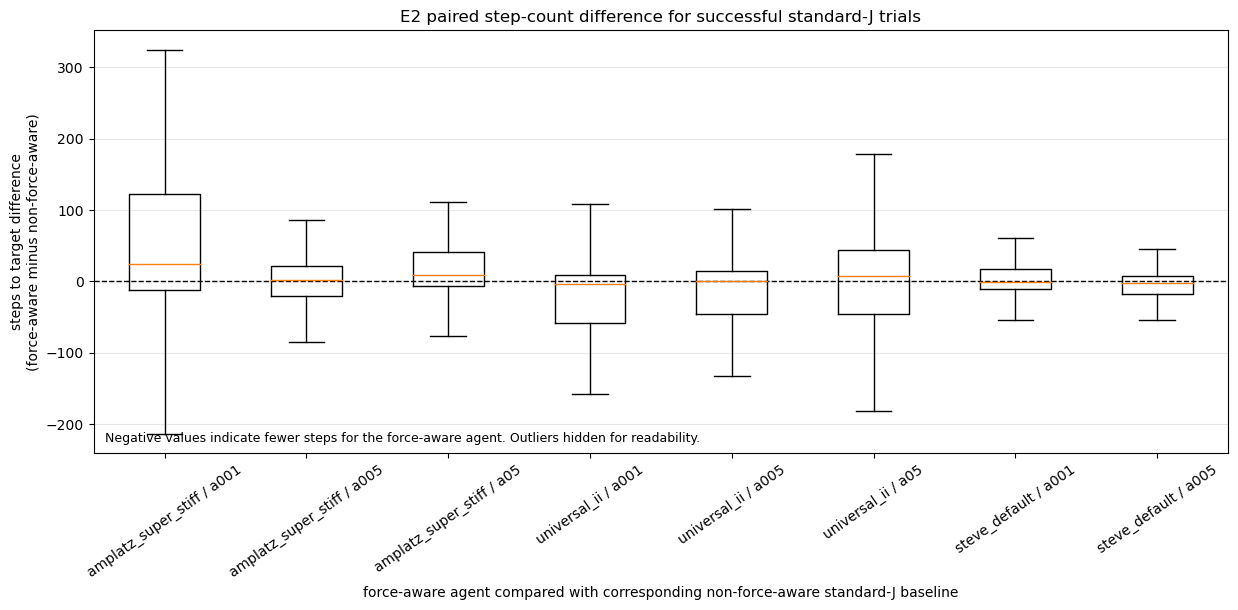

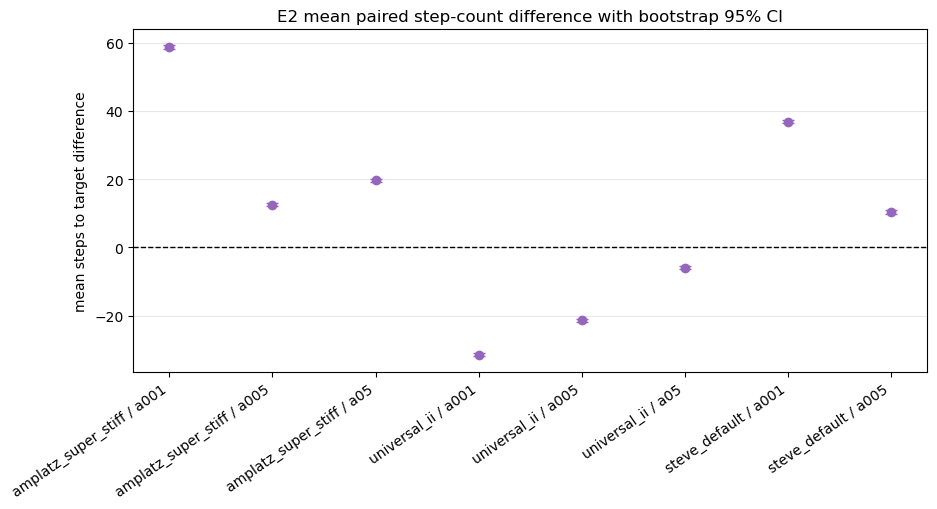

### Paired step-count comparison for successful standard-J trials

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_detail.csv`

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_summary.csv`

Saved boxplot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_boxplot.png`

Saved mean-difference CI plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_mean_ci.png`

,wire_model,force_alpha,n_matched_successful_trials,mean_steps_force_aware,mean_steps_non_force,mean_step_diff,median_step_diff,min_step_diff,max_step_diff,force_aware_fewer_steps_percent,ci_low_mean_step_diff,ci_high_mean_step_diff,p_mean_step_diff_below_zero,significantly_fewer_steps_95,significantly_more_steps_95
0,amplatz_super_stiff,a001,415373,202.9108,144.0708,58.8400,25.0,-739.0,770.0,32.4648,58.3142,59.3870,0.0,False,True
1,amplatz_super_stiff,a005,448161,151.6927,139.2128,12.4799,2.0,-754.0,762.0,40.9478,12.0468,12.9138,0.0,False,True
2,amplatz_super_stiff,a05,446002,155.5878,135.9495,19.6383,9.0,-755.0,764.0,28.2062,19.2638,20.0105,0.0,False,True
3,steve_default,a001,153066,126.4898,89.5724,36.9175,-1.0,-749.0,756.0,52.6714,36.3544,37.4895,0.0,False,True
4,steve_default,a005,106830,99.7909,89.3435,10.4473,-2.0,-741.0,757.0,53.3923,9.8533,11.0596,0.0,False,True
5,universal_ii,a001,418712,126.4817,158.0066,-31.5249,-4.0,-770.0,763.0,53.5561,-31.9496,-31.0951,1.0,True,False
6,universal_ii,a005,405125,131.9130,153.2244,-21.3114,0.0,-763.0,764.0,49.9029,-21.7469,-20.8902,1.0,True,False
7,universal_ii,a05,421282,152.9767,159.0105,-6.0338,7.0,-762.0,762.0,43.2193,-6.4860,-5.5814,1.0,True,False


,anatomy_target_key,branch,wire_model,force_alpha,trial_index,steps_force_aware,steps_non_force,step_diff,force_aware_fewer_steps,plot_label
0,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,0,365.0,254.0,111.0,False,amplatz_super_stiff / a001
3,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,1,388.0,66.0,322.0,False,amplatz_super_stiff / a001
6,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,2,67.0,172.0,-105.0,True,amplatz_super_stiff / a001
9,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,3,57.0,206.0,-149.0,True,amplatz_super_stiff / a001
11,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,4,68.0,260.0,-192.0,True,amplatz_super_stiff / a001
13,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,5,61.0,121.0,-60.0,True,amplatz_super_stiff / a001
16,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,6,67.0,123.0,-56.0,True,amplatz_super_stiff / a001
19,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,7,64.0,67.0,-3.0,True,amplatz_super_stiff / a001
22,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,8,61.0,100.0,-39.0,True,amplatz_super_stiff / a001
25,Tree_03__target_000__bct__end__seedbase_123,bct,amplatz_super_stiff,a001,9,58.0,215.0,-157.0,True,amplatz_super_stiff / a001


In [35]:
# Paired step-count comparison for successful standard-J trials.
# Negative step difference means the force-aware agent reached the target in fewer steps.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

try:
    E2_NON_FORCE_RESULT_ROOT
except NameError:
    E2_NON_FORCE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_tinyfat_finished_readable_20260515"

try:
    E2_FORCE_AWARE_RESULT_ROOT
except NameError:
    E2_FORCE_AWARE_RESULT_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e2_force_aware_20260515"

try:
    E2_SCORE_OUTPUT_DIR
except NameError:
    E2_SCORE_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e2_clean_analysis"
E2_SCORE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

E2_STEP_COMPARISON_BOOT_N = 10000
E2_STEP_COMPARISON_BOOT_SEED = 123
E2_STEP_COMPARISON_MAX_RUNS = None  # set to a small integer while testing; None processes all matched runs
E2_STEP_COMPARISON_PROGRESS_EVERY = 100

standard_j_wires = [
    "amplatz_super_stiff/standard_j",
    "universal_ii/standard_j",
    "steve_default/standard_j",
]
needed_cols = [
    "candidate_name",
    "execution_wire",
    "success",
    "trial_index",
    "steps_total",
    "steps_to_success",
]

def success_to_float(series):
    mapped = series.map({
        True: 1.0,
        False: 0.0,
        "true": 1.0,
        "false": 0.0,
        "True": 1.0,
        "False": 0.0,
    })
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)

def e2_run_dirs(root):
    runs_root = root / "runs" / "config_4"
    if not runs_root.exists():
        return {}
    return {run_dir.name: run_dir for run_dir in sorted(runs_root.iterdir()) if (run_dir / "trials.csv").exists()}

def e2_parse_branch_from_run_key(run_key):
    parts = str(run_key).split("__")
    return parts[2] if len(parts) >= 3 else np.nan

def e2_read_small_trial_csv(csv_path):
    return pd.read_csv(csv_path, usecols=lambda col: col in needed_cols)

def steps_column(df):
    # steps_to_success is the direct quantity; steps_total is equivalent for successful trials in these tables.
    if "steps_to_success" in df.columns:
        return pd.to_numeric(df["steps_to_success"], errors="coerce")
    return pd.to_numeric(df["steps_total"], errors="coerce")

def prepare_successful_non_force_steps(df):
    df = df.loc[df["execution_wire"].isin(standard_j_wires)].copy()
    df["success_float"] = success_to_float(df["success"])
    df = df.loc[df["success_float"].eq(1.0)].copy()
    df["wire_model"] = df["execution_wire"].astype(str).str.split("/").str[0]
    df["steps_non_force"] = steps_column(df)
    return df[["wire_model", "trial_index", "steps_non_force"]]

def prepare_successful_force_aware_steps(df):
    df = df.loc[df["execution_wire"].isin(standard_j_wires)].copy()
    df["success_float"] = success_to_float(df["success"])
    df = df.loc[df["success_float"].eq(1.0)].copy()
    df["wire_model"] = df["execution_wire"].astype(str).str.split("/").str[0]
    df["force_alpha"] = df["candidate_name"].astype(str).str.extract(r"_(a\d+)_force_aware$")[0].fillna("unknown")
    df["steps_force_aware"] = steps_column(df)
    return df[["wire_model", "force_alpha", "trial_index", "steps_force_aware"]]

def bootstrap_mean_ci(values, n_boot=10000, seed=123):
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return pd.Series({
            "ci_low_mean_step_diff": np.nan,
            "ci_high_mean_step_diff": np.nan,
            "p_mean_step_diff_below_zero": np.nan,
        })
    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)
    for boot_idx in range(n_boot):
        boot_means[boot_idx] = rng.choice(values, size=len(values), replace=True).mean()
    return pd.Series({
        "ci_low_mean_step_diff": float(np.quantile(boot_means, 0.025)),
        "ci_high_mean_step_diff": float(np.quantile(boot_means, 0.975)),
        "p_mean_step_diff_below_zero": float((boot_means < 0).mean()),
    })

non_force_runs = e2_run_dirs(E2_NON_FORCE_RESULT_ROOT)
force_aware_runs = e2_run_dirs(E2_FORCE_AWARE_RESULT_ROOT)
matched_run_keys = sorted(set(non_force_runs) & set(force_aware_runs))
if E2_STEP_COMPARISON_MAX_RUNS is not None:
    matched_run_keys = matched_run_keys[:E2_STEP_COMPARISON_MAX_RUNS]

if not matched_run_keys:
    display(Markdown("No matching force-aware and non-force-aware run folders with `trials.csv` were found."))
else:
    display(Markdown(
        f"Streaming **{len(matched_run_keys)}** matched E2 run folders. "
        "Only trials where both agents succeeded are retained for the step-count comparison."
    ))

    paired_parts = []
    skipped_runs = 0
    for run_number, run_key in enumerate(matched_run_keys, start=1):
        try:
            non_force_steps = prepare_successful_non_force_steps(e2_read_small_trial_csv(non_force_runs[run_key] / "trials.csv"))
            force_aware_steps = prepare_successful_force_aware_steps(e2_read_small_trial_csv(force_aware_runs[run_key] / "trials.csv"))
            paired = force_aware_steps.merge(
                non_force_steps,
                on=["wire_model", "trial_index"],
                how="inner",
            )
        except Exception as exc:
            skipped_runs += 1
            if skipped_runs <= 10:
                print(f"skipping {run_key}: {exc}")
            continue

        if paired.empty:
            continue

        paired["anatomy_target_key"] = run_key
        paired["branch"] = e2_parse_branch_from_run_key(run_key)
        paired["step_diff"] = paired["steps_force_aware"] - paired["steps_non_force"]
        paired["force_aware_fewer_steps"] = paired["step_diff"].lt(0)
        paired = paired[[
            "anatomy_target_key",
            "branch",
            "wire_model",
            "force_alpha",
            "trial_index",
            "steps_force_aware",
            "steps_non_force",
            "step_diff",
            "force_aware_fewer_steps",
        ]]
        paired_parts.append(paired)

        if run_number % E2_STEP_COMPARISON_PROGRESS_EVERY == 0:
            rows_so_far = sum(len(part) for part in paired_parts)
            print(f"processed_runs={run_number} paired_successful_trials={rows_so_far:,} latest={run_key}")

    if not paired_parts:
        display(Markdown("No matched successful standard-J trials were found."))
    else:
        step_diff_df = pd.concat(paired_parts, ignore_index=True)
        step_diff_df = step_diff_df.sort_values(["wire_model", "force_alpha", "anatomy_target_key", "trial_index"])

        step_diff_summary = (
            step_diff_df
            .groupby(["wire_model", "force_alpha"], dropna=False)
            .agg(
                n_matched_successful_trials=("step_diff", "count"),
                mean_steps_force_aware=("steps_force_aware", "mean"),
                mean_steps_non_force=("steps_non_force", "mean"),
                mean_step_diff=("step_diff", "mean"),
                median_step_diff=("step_diff", "median"),
                min_step_diff=("step_diff", "min"),
                max_step_diff=("step_diff", "max"),
                force_aware_fewer_steps_percent=("force_aware_fewer_steps", lambda s: 100.0 * float(s.mean())),
            )
            .reset_index()
        )
        step_diff_ci = (
            step_diff_df
            .groupby(["wire_model", "force_alpha"], dropna=False)["step_diff"]
            .apply(lambda values: bootstrap_mean_ci(
                values,
                n_boot=E2_STEP_COMPARISON_BOOT_N,
                seed=E2_STEP_COMPARISON_BOOT_SEED,
            ))
            .unstack()
            .reset_index()
        )
        step_diff_summary = step_diff_summary.merge(step_diff_ci, on=["wire_model", "force_alpha"], how="left")
        step_diff_summary["significantly_fewer_steps_95"] = step_diff_summary["ci_high_mean_step_diff"].lt(0)
        step_diff_summary["significantly_more_steps_95"] = step_diff_summary["ci_low_mean_step_diff"].gt(0)
        step_diff_summary = step_diff_summary.sort_values(["wire_model", "force_alpha"])

        detail_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_detail.csv"
        summary_csv = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_summary.csv"
        step_diff_df.to_csv(detail_csv, index=False)
        step_diff_summary.to_csv(summary_csv, index=False)

        alpha_order = ["a001", "a005", "a05", "unknown"]
        wire_order = ["amplatz_super_stiff", "universal_ii", "steve_default"]
        step_diff_df["plot_label"] = step_diff_df["wire_model"] + " / " + step_diff_df["force_alpha"].astype(str)
        label_order = [
            f"{wire_model} / {alpha}"
            for wire_model in wire_order
            for alpha in alpha_order
            if ((step_diff_df["wire_model"].eq(wire_model)) & (step_diff_df["force_alpha"].astype(str).eq(alpha))).any()
        ]

        box_data = [
            step_diff_df.loc[step_diff_df["plot_label"].eq(label), "step_diff"].dropna().to_numpy()
            for label in label_order
        ]
        fig, ax = plt.subplots(figsize=(12.5, 6.2))
        ax.boxplot(box_data, labels=label_order, showfliers=False)
        ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
        ax.set_title("E2 paired step-count difference for successful standard-J trials")
        ax.set_xlabel("force-aware agent compared with corresponding non-force-aware standard-J baseline")
        ax.set_ylabel("steps to target difference\n(force-aware minus non-force-aware)")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(axis="y", alpha=0.3)
        ax.text(
            0.01,
            0.02,
            "Negative values indicate fewer steps for the force-aware agent. Outliers hidden for readability.",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
        )
        fig.tight_layout()
        boxplot_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_boxplot.png"
        boxplot_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_boxplot.pdf"
        fig.savefig(boxplot_png, dpi=200, bbox_inches="tight")
        fig.savefig(boxplot_pdf, bbox_inches="tight")
        plt.show()

        plot_summary = step_diff_summary.copy()
        plot_summary["plot_label"] = plot_summary["wire_model"] + " / " + plot_summary["force_alpha"].astype(str)
        plot_summary = plot_summary.set_index("plot_label").reindex(label_order).reset_index()
        yerr = np.vstack([
            plot_summary["mean_step_diff"] - plot_summary["ci_low_mean_step_diff"],
            plot_summary["ci_high_mean_step_diff"] - plot_summary["mean_step_diff"],
        ])

        fig, ax = plt.subplots(figsize=(9.5, 5.2))
        ax.errorbar(
            x=np.arange(len(plot_summary)),
            y=plot_summary["mean_step_diff"],
            yerr=yerr,
            fmt="o",
            capsize=4,
            color="tab:purple",
        )
        ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
        ax.set_xticks(np.arange(len(plot_summary)))
        ax.set_xticklabels(plot_summary["plot_label"], rotation=35, ha="right")
        ax.set_title("E2 mean paired step-count difference with bootstrap 95% CI")
        ax.set_ylabel("mean steps to target difference")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        ci_png = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_mean_ci.png"
        ci_pdf = E2_SCORE_OUTPUT_DIR / "e2_force_aware_vs_non_force_standard_j_paired_successful_step_diff_mean_ci.pdf"
        fig.savefig(ci_png, dpi=200, bbox_inches="tight")
        fig.savefig(ci_pdf, bbox_inches="tight")
        plt.show()

        display(Markdown("### Paired step-count comparison for successful standard-J trials"))
        display(Markdown(f"Saved detail table: `{detail_csv}`"))
        display(Markdown(f"Saved summary table: `{summary_csv}`"))
        display(Markdown(f"Saved boxplot: `{boxplot_png}`"))
        display(Markdown(f"Saved mean-difference CI plot: `{ci_png}`"))
        display(step_diff_summary.round(4))
        display(step_diff_df.head(20).round(4))


### 3.2.13 Force-Aware Effect Decomposition Plot

This compact plot combines the main drivers of the force-aware score comparison. Each row is one force-aware standard-J agent compared with the corresponding non-force-aware standard-J baseline from the same wire family. Values are always computed as force-aware minus non-force-aware. The success-rate column uses anatomy-target paired success-rate differences. The force and step columns use anatomy-target groups with matched successful trials for both agents; differences are averaged within each anatomy-target first and then bootstrapped across anatomy-targets. Green indicates a beneficial change for the force-aware agent: higher success rate, lower maximum normal force, or fewer steps to success. Brackets show 95% bootstrap confidence intervals.


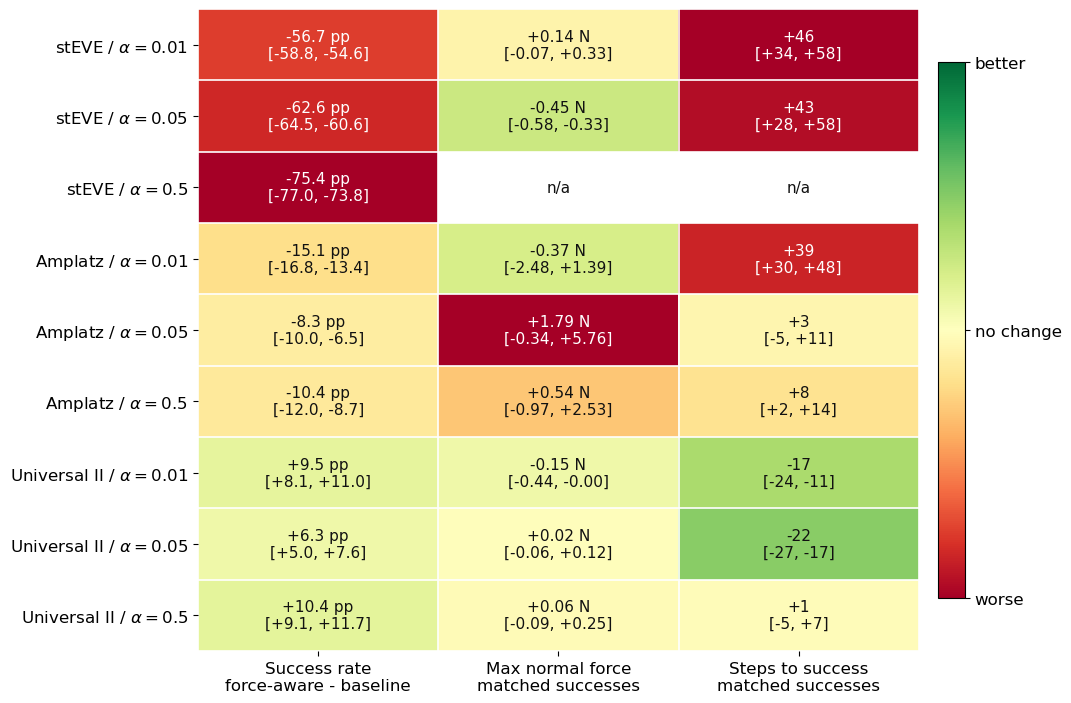

### Force-aware effect decomposition

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_effect_decomposition_heatmap.png`

Saved table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_vs_non_force_standard_j_effect_decomposition_table.csv`

,agent,success_pp,success_ci_low_pp,success_ci_high_pp,force_N,force_ci_low_N,force_ci_high_N,steps,steps_ci_low,steps_ci_high
0,stEVE / $\alpha=0.01$,-56.7,-58.8,-54.6,0.14,-0.07,0.33,46.0,34.0,58.0
1,stEVE / $\alpha=0.05$,-62.6,-64.5,-60.6,-0.45,-0.58,-0.33,43.0,28.0,58.0
2,stEVE / $\alpha=0.5$,-75.4,-77.0,-73.8,NaN,NaN,NaN,NaN,NaN,NaN
3,Amplatz / $\alpha=0.01$,-15.1,-16.8,-13.4,-0.37,-2.48,1.39,39.0,30.0,48.0
4,Amplatz / $\alpha=0.05$,-8.3,-10.0,-6.5,1.79,-0.34,5.76,3.0,-5.0,11.0
5,Amplatz / $\alpha=0.5$,-10.4,-12.0,-8.7,0.54,-0.97,2.53,8.0,2.0,14.0
6,Universal II / $\alpha=0.01$,9.5,8.1,11.0,-0.15,-0.44,-0.00,-17.0,-24.0,-11.0
7,Universal II / $\alpha=0.05$,6.3,5.0,7.6,0.02,-0.06,0.12,-22.0,-27.0,-17.0
8,Universal II / $\alpha=0.5$,10.4,9.1,11.7,0.06,-0.09,0.25,1.0,-5.0,7.0


In [36]:
# E2 force-aware effect decomposition plot.
#
# This cell intentionally reuses the already written paired-summary/detail CSV files.
# It is therefore fast to rerun and does not repeat the heavy trial aggregation.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm

try:
    output_dir = Path(E2_SCORE_OUTPUT_DIR)
except NameError:
    output_dir = Path("results/master_thesis/e2_clean_analysis")

prefix = "e2_force_aware_vs_non_force_standard_j"
success_summary_path = output_dir / f"{prefix}_paired_success_rate_diff_summary.csv"
force_detail_path = output_dir / f"{prefix}_paired_successful_force_diff_detail.csv"
step_detail_path = output_dir / f"{prefix}_paired_successful_step_diff_detail.csv"

success_summary = pd.read_csv(success_summary_path)
force_detail = pd.read_csv(force_detail_path)
step_detail = pd.read_csv(step_detail_path)


def bootstrap_mean_ci(values: np.ndarray, *, repeats: int = 5000, seed: int = 20260530):
    """Return a percentile bootstrap CI for the mean of scenario-level values."""

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    sample_indices = rng.integers(0, values.size, size=(repeats, values.size))
    sample_means = values[sample_indices].mean(axis=1)
    return tuple(np.percentile(sample_means, [2.5, 97.5]))


def summarize_matched_success_detail(
    detail: pd.DataFrame,
    *,
    value_column: str,
    mean_column: str,
    ci_low_column: str,
    ci_high_column: str,
    count_prefix: str,
) -> pd.DataFrame:
    """Average matched successful trials within anatomy-targets, then bootstrap targets."""

    by_target = (
        detail
        .groupby(["wire_model", "force_alpha", "anatomy_target_key"], as_index=False)
        .agg(
            target_mean=(value_column, "mean"),
            matched_successful_trials=(value_column, "size"),
        )
    )

    rows = []
    for (wire_model, force_alpha), group in by_target.groupby(["wire_model", "force_alpha"]):
        target_means = group["target_mean"].to_numpy(dtype=float)
        ci_low, ci_high = bootstrap_mean_ci(target_means)
        rows.append(
            {
                "wire_model": wire_model,
                "force_alpha": force_alpha,
                mean_column: float(np.nanmean(target_means)),
                ci_low_column: ci_low,
                ci_high_column: ci_high,
                f"n_{count_prefix}_anatomy_targets": int(group["anatomy_target_key"].nunique()),
                f"n_{count_prefix}_trials": int(group["matched_successful_trials"].sum()),
            }
        )
    return pd.DataFrame(rows)


# Success-rate changes are already anatomy-target summaries from the paired
# success-rate comparison. Convert the mean and CI to percentage points.
success_for_plot = success_summary[
    [
        "wire_model",
        "force_alpha",
        "mean_success_rate_diff",
        "ci_low_mean_success_rate_diff",
        "ci_high_mean_success_rate_diff",
        "n_anatomy_targets",
    ]
].copy()
success_for_plot["success_pp"] = 100.0 * success_for_plot["mean_success_rate_diff"]
success_for_plot["success_ci_low_pp"] = 100.0 * success_for_plot["ci_low_mean_success_rate_diff"]
success_for_plot["success_ci_high_pp"] = 100.0 * success_for_plot["ci_high_mean_success_rate_diff"]

# Force and step changes use only matched successful trials. Each anatomy-target
# is averaged first; the displayed CI bootstraps those anatomy-target means.
force_for_plot = summarize_matched_success_detail(
    force_detail,
    value_column="wire_force_diff_N",
    mean_column="force_N",
    ci_low_column="force_ci_low_N",
    ci_high_column="force_ci_high_N",
    count_prefix="force_matched_successful",
)
step_for_plot = summarize_matched_success_detail(
    step_detail,
    value_column="step_diff",
    mean_column="steps",
    ci_low_column="steps_ci_low",
    ci_high_column="steps_ci_high",
    count_prefix="step_matched_successful",
)

decomposition = (
    success_for_plot
    .merge(force_for_plot, on=["wire_model", "force_alpha"], how="left", validate="one_to_one")
    .merge(step_for_plot, on=["wire_model", "force_alpha"], how="left", validate="one_to_one")
)

wire_labels = {
    "steve_default": "stEVE",
    "amplatz_super_stiff": "Amplatz",
    "universal_ii": "Universal II",
}
wire_order = ["steve_default", "amplatz_super_stiff", "universal_ii"]
alpha_order = ["a001", "a005", "a05"]
alpha_labels = {
    "a001": r"$\alpha=0.01$",
    "a005": r"$\alpha=0.05$",
    "a05": r"$\alpha=0.5$",
}

decomposition["wire_order"] = decomposition["wire_model"].map(
    {wire: i for i, wire in enumerate(wire_order)}
)
decomposition["alpha_order"] = decomposition["force_alpha"].map(
    {alpha: i for i, alpha in enumerate(alpha_order)}
)
decomposition = decomposition.sort_values(["wire_order", "alpha_order"]).reset_index(drop=True)

decomposition_plot = pd.DataFrame(
    {
        "agent": decomposition.apply(
            lambda row: f"{wire_labels.get(row['wire_model'], row['wire_model'])} / "
            f"{alpha_labels.get(row['force_alpha'], row['force_alpha'])}",
            axis=1,
        ),
        "success_pp": decomposition["success_pp"],
        "success_ci_low_pp": decomposition["success_ci_low_pp"],
        "success_ci_high_pp": decomposition["success_ci_high_pp"],
        "force_N": decomposition["force_N"],
        "force_ci_low_N": decomposition["force_ci_low_N"],
        "force_ci_high_N": decomposition["force_ci_high_N"],
        "steps": decomposition["steps"],
        "steps_ci_low": decomposition["steps_ci_low"],
        "steps_ci_high": decomposition["steps_ci_high"],
        "n_success_anatomy_targets": decomposition["n_anatomy_targets"],
        "n_force_matched_successful_anatomy_targets": decomposition["n_force_matched_successful_anatomy_targets"],
        "n_force_matched_successful_trials": decomposition["n_force_matched_successful_trials"],
        "n_step_matched_successful_anatomy_targets": decomposition["n_step_matched_successful_anatomy_targets"],
        "n_step_matched_successful_trials": decomposition["n_step_matched_successful_trials"],
    }
)

# Color values encode interpretation, not units. Positive means better for the
# force-aware agent. Success is better when it increases; force and steps are
# better when they decrease. Each metric is normalized independently.
color_values = np.column_stack(
    [
        decomposition_plot["success_pp"].to_numpy(dtype=float),
        -decomposition_plot["force_N"].to_numpy(dtype=float),
        -decomposition_plot["steps"].to_numpy(dtype=float),
    ]
)
column_scale = np.nanmax(np.abs(color_values), axis=0)
column_scale[~np.isfinite(column_scale) | (column_scale == 0.0)] = 1.0
color_values = color_values / column_scale

metrics = [
    ("success_pp", "Success rate\nforce-aware - baseline"),
    ("force_N", "Max normal force\nmatched successes"),
    ("steps", "Steps to success\nmatched successes"),
]


def format_decomposition_value(row: pd.Series, metric: str) -> str:
    value = float(row[metric])
    if not np.isfinite(value):
        return "n/a"
    if metric == "success_pp":
        ci_low = float(row["success_ci_low_pp"])
        ci_high = float(row["success_ci_high_pp"])
        return f"{value:+.1f} pp\n[{ci_low:+.1f}, {ci_high:+.1f}]"
    if metric == "force_N":
        ci_low = float(row["force_ci_low_N"])
        ci_high = float(row["force_ci_high_N"])
        return f"{value:+.2f} N\n[{ci_low:+.2f}, {ci_high:+.2f}]"
    if metric == "steps":
        ci_low = float(row["steps_ci_low"])
        ci_high = float(row["steps_ci_high"])
        return f"{value:+.0f}\n[{ci_low:+.0f}, {ci_high:+.0f}]"
    raise ValueError(metric)

fig, ax = plt.subplots(figsize=(10.8, 7.2))
image = ax.imshow(
    color_values,
    aspect="auto",
    cmap="RdYlGn",
    norm=TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0),
)

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels([label for _metric, label in metrics], fontsize=12)
ax.set_yticks(np.arange(len(decomposition_plot)))
ax.set_yticklabels(decomposition_plot["agent"], fontsize=12)
ax.tick_params(axis="both", labelsize=12)

ax.set_xticks(np.arange(-0.5, len(metrics), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(decomposition_plot), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

for row_index, row in decomposition_plot.iterrows():
    for col_index, (metric, _label) in enumerate(metrics):
        cell_strength = float(color_values[row_index, col_index])
        text_color = "white" if abs(cell_strength) >= 0.72 else "#111111"
        ax.text(
            col_index,
            row_index,
            format_decomposition_value(row, metric),
            ha="center",
            va="center",
            fontsize=11,
            linespacing=1.15,
            color=text_color,
        )

# Title intentionally omitted for thesis figure layout.
#ax.set_xlabel(
#    "Green means beneficial for the force-aware agent; red means worse. Brackets show 95% bootstrap CI.",
#    fontsize=10,
#    labelpad=12,
#)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.025)
colorbar.set_ticks([-1.0, 0.0, 1.0])
colorbar.set_ticklabels(["worse", "no change", "better"])
colorbar.ax.tick_params(labelsize=12)

fig.tight_layout()

figure_png = output_dir / f"{prefix}_effect_decomposition_heatmap.png"
figure_pdf = output_dir / f"{prefix}_effect_decomposition_heatmap.pdf"
table_csv = output_dir / f"{prefix}_effect_decomposition_table.csv"

fig.savefig(figure_png, dpi=220, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
decomposition_plot.to_csv(table_csv, index=False)
plt.show()

display(Markdown("### Force-aware effect decomposition"))
display(Markdown(f"Saved figure: `{figure_png}`"))
display(Markdown(f"Saved table: `{table_csv}`"))
display(
    decomposition_plot[
        [
            "agent",
            "success_pp",
            "success_ci_low_pp",
            "success_ci_high_pp",
            "force_N",
            "force_ci_low_N",
            "force_ci_high_N",
            "steps",
            "steps_ci_low",
            "steps_ci_high",
        ]
    ].round(
        {
            "success_pp": 1,
            "success_ci_low_pp": 1,
            "success_ci_high_pp": 1,
            "force_N": 2,
            "force_ci_low_N": 2,
            "force_ci_high_N": 2,
            "steps": 0,
            "steps_ci_low": 0,
            "steps_ci_high": 0,
        }
    )
)


In [13]:
trial_df = load_e2_trial_combined()

## 3.3 Pairwise Bootstrap Difference and Top-1 Cluster Size

This analysis is family-specific and does not mix force-aware with non-force-aware candidates. For every anatomy-target group, it compares all candidate pairs with a matched bootstrap over `trial_index` values. The score difference is

`difference = score(candidate_a) - score(candidate_b)`.

For the observed Top-1 candidate in an anatomy-target group, every other candidate is checked against the paired bootstrap confidence interval. If the 95% confidence interval of `Top-1 - competitor` contains zero, that competitor is treated as statistically not clearly separated from the Top-1. The Top-1 cluster size is therefore:

`1 + number of competitors whose Top-1 difference CI contains zero`.


In [43]:
import itertools


def e2_pairwise_output_path(training_family: str) -> Path:
    return E2_SCORE_OUTPUT_DIR / f"e2_{training_family}_pairwise_score_diff_ci_k{E2_BOOTSTRAP_K}_b{E2_BOOTSTRAP_N}.csv"


def e2_top1_cluster_output_path(training_family: str) -> Path:
    return E2_SCORE_OUTPUT_DIR / f"e2_{training_family}_top1_cluster_size_k{E2_BOOTSTRAP_K}_b{E2_BOOTSTRAP_N}.csv"


def _bootstrap_score_from_sample(score_contribution: np.ndarray, sample_idx: np.ndarray) -> np.ndarray:
    return score_contribution[sample_idx].mean(axis=1)


def build_e2_pairwise_bootstrap_diff(training_family: str, rebuild: bool = False):
    pairwise_path = e2_pairwise_output_path(training_family)
    cluster_path = e2_top1_cluster_output_path(training_family)
    if pairwise_path.exists() and cluster_path.exists() and not rebuild:
        print(f"Loading existing pairwise table: {pairwise_path}")
        print(f"Loading existing cluster table: {cluster_path}")
        return pd.read_csv(pairwise_path), pd.read_csv(cluster_path)

    print(f"Loading trial cache for {training_family}...")
    family_trials = load_e2_trial_family(training_family)
    print(f"loaded rows: {len(family_trials):,}")

    keep_cols = [
        "training_family",
        "source_e2_array_index",
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
        "candidate_key",
        "candidate_name",
        "execution_wire",
        "wire_model",
        "wire_shape",
        "force_alpha",
        "trial_index",
        "success",
        "steps_total",
        "wire_force_normal_trial_max_N",
    ]
    scored = e2_score_trials(family_trials[[col for col in keep_cols if col in family_trials.columns]].copy())
    del family_trials
    scored["trial_index"] = pd.to_numeric(scored["trial_index"], errors="coerce").astype("Int64")

    rng = np.random.default_rng(E2_BOOTSTRAP_SEED)
    pairwise_rows = []
    cluster_rows = []

    target_group_cols = [
        "training_family",
        "source_e2_array_index",
        "anatomy_target_key",
        "anatomy_id",
        "anatomy_index",
        "target_index",
        "branch",
    ]

    grouped_targets = list(scored.groupby(target_group_cols, dropna=False, sort=False))
    print(f"processing {len(grouped_targets):,} anatomy-target groups with B={E2_BOOTSTRAP_N}, k={E2_BOOTSTRAP_K}")

    for target_index, (target_key, target_df) in enumerate(grouped_targets, start=1):
        target_meta = dict(zip(target_group_cols, target_key))
        candidate_scores = (
            target_df.groupby(["candidate_key", "candidate_name", "execution_wire", "wire_model", "wire_shape", "force_alpha"], dropna=False)
            .agg(
                observed_wire_score=("score_contribution", "mean"),
                valid_rate=("valid_for_score", "mean"),
                n_trials=("trial_index", "size"),
            )
            .reset_index()
        )
        if len(candidate_scores) < 2:
            continue

        top_row = candidate_scores.sort_values("observed_wire_score", ascending=False).iloc[0]
        top_candidate_key = top_row["candidate_key"]
        candidate_lookup = candidate_scores.set_index("candidate_key")
        candidate_keys = candidate_scores["candidate_key"].tolist()

        top1_cluster_candidate_keys = {top_candidate_key}
        top1_compared_candidates = 0
        top1_uncertain_competitors = 0
        top1_min_ci_low = np.inf

        for candidate_a, candidate_b in itertools.combinations(candidate_keys, 2):
            cols = ["trial_index", "score_contribution"]
            a = target_df.loc[target_df["candidate_key"].eq(candidate_a), cols].rename(columns={"score_contribution": "score_a"})
            b = target_df.loc[target_df["candidate_key"].eq(candidate_b), cols].rename(columns={"score_contribution": "score_b"})
            paired = a.merge(b, on="trial_index", how="inner").dropna().sort_values("trial_index")
            n_matched = len(paired)
            if n_matched < E2_BOOTSTRAP_K:
                continue

            sample_idx = rng.integers(0, n_matched, size=(E2_BOOTSTRAP_N, E2_BOOTSTRAP_K))
            score_a = _bootstrap_score_from_sample(paired["score_a"].to_numpy(dtype=float), sample_idx)
            score_b = _bootstrap_score_from_sample(paired["score_b"].to_numpy(dtype=float), sample_idx)
            diff = score_a - score_b
            ci_low, ci_high = np.quantile(diff, [0.025, 0.975])
            ci_contains_zero = bool(ci_low <= 0 <= ci_high)

            score_a_observed = float(candidate_lookup.loc[candidate_a, "observed_wire_score"])
            score_b_observed = float(candidate_lookup.loc[candidate_b, "observed_wire_score"])
            row = dict(target_meta)
            row.update(
                {
                    "candidate_a": candidate_a,
                    "candidate_b": candidate_b,
                    "execution_wire_a": candidate_lookup.loc[candidate_a, "execution_wire"],
                    "execution_wire_b": candidate_lookup.loc[candidate_b, "execution_wire"],
                    "force_alpha_a": candidate_lookup.loc[candidate_a, "force_alpha"],
                    "force_alpha_b": candidate_lookup.loc[candidate_b, "force_alpha"],
                    "observed_score_a": score_a_observed,
                    "observed_score_b": score_b_observed,
                    "observed_diff_a_minus_b": score_a_observed - score_b_observed,
                    "bootstrap_mean_diff_a_minus_b": float(diff.mean()),
                    "ci_low_diff_a_minus_b": float(ci_low),
                    "ci_high_diff_a_minus_b": float(ci_high),
                    "ci_half_width_diff": float((ci_high - ci_low) / 2.0),
                    "p_a_greater_b": float((diff > 0).mean()),
                    "ci_contains_zero": ci_contains_zero,
                    "n_matched_trials": int(n_matched),
                    "k": int(E2_BOOTSTRAP_K),
                    "n_boot": int(E2_BOOTSTRAP_N),
                    "bootstrap_pairing": "matched_trial_index",
                }
            )
            pairwise_rows.append(row)

            if candidate_a == top_candidate_key or candidate_b == top_candidate_key:
                top1_compared_candidates += 1
                if candidate_a == top_candidate_key:
                    top1_ci_low = float(ci_low)
                    competitor = candidate_b
                    top1_ci_contains_zero = ci_contains_zero
                else:
                    top1_ci_low = float(-ci_high)
                    competitor = candidate_a
                    top1_ci_contains_zero = bool((-ci_high) <= 0 <= (-ci_low))

                top1_min_ci_low = min(top1_min_ci_low, top1_ci_low)
                if top1_ci_contains_zero:
                    top1_cluster_candidate_keys.add(competitor)
                    top1_uncertain_competitors += 1

        cluster_row = dict(target_meta)
        cluster_row.update(
            {
                "top1_candidate_key": top_candidate_key,
                "top1_execution_wire": top_row["execution_wire"],
                "top1_force_alpha": top_row["force_alpha"],
                "top1_observed_score": float(top_row["observed_wire_score"]),
                "n_candidates": int(len(candidate_scores)),
                "top1_compared_candidates": int(top1_compared_candidates),
                "top1_uncertain_competitors": int(top1_uncertain_competitors),
                "top1_cluster_size": int(len(top1_cluster_candidate_keys)),
                "top1_cluster_fraction": float(len(top1_cluster_candidate_keys) / len(candidate_scores)),
                "top1_cluster_percent": float(100.0 * len(top1_cluster_candidate_keys) / len(candidate_scores)),
                "top1_min_ci_low_vs_competitors": float(top1_min_ci_low) if np.isfinite(top1_min_ci_low) else np.nan,
                "top1_cluster_candidate_keys": " | ".join(sorted(top1_cluster_candidate_keys)),
                "k": int(E2_BOOTSTRAP_K),
                "n_boot": int(E2_BOOTSTRAP_N),
            }
        )
        cluster_rows.append(cluster_row)

        if target_index % 100 == 0:
            print(f"processed anatomy-targets: {target_index:,}/{len(grouped_targets):,}")

    pairwise_df = pd.DataFrame(pairwise_rows)
    cluster_df = pd.DataFrame(cluster_rows)
    pairwise_df.to_csv(pairwise_path, index=False)
    cluster_df.to_csv(cluster_path, index=False)
    print(f"saved pairwise: {pairwise_path}")
    print(f"saved clusters: {cluster_path}")
    display(cluster_df["top1_cluster_size"].value_counts().sort_index().rename("anatomy_target_count").to_frame())
    return pairwise_df, cluster_df


In [44]:
# Build pairwise difference CIs and Top-1 cluster sizes for one family at a time.
# This can take a while, especially for non_force_aware because it has 15 candidates per anatomy-target.
E2_PAIRWISE_FAMILY_TO_BUILD = "force_aware"  # options: "force_aware", "non_force_aware"
E2_REBUILD_PAIRWISE = False

e2_pairwise_diff_df, e2_top1_cluster_df = build_e2_pairwise_bootstrap_diff(
    E2_PAIRWISE_FAMILY_TO_BUILD,
    rebuild=E2_REBUILD_PAIRWISE,
)

display(e2_pairwise_diff_df.head(20).round(4))
display(e2_top1_cluster_df.head(20).round(4))


Loading existing pairwise table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_pairwise_score_diff_ci_k500_b1000.csv
Loading existing cluster table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_force_aware_top1_cluster_size_k500_b1000.csv


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,candidate_a,candidate_b,execution_wire_a,...,bootstrap_mean_diff_a_minus_b,ci_low_diff_a_minus_b,ci_high_diff_a_minus_b,ci_half_width_diff,p_a_greater_b,ci_contains_zero,n_matched_trials,k,n_boot,bootstrap_pairing
0,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff/standard_j,...,0.0734,0.0570,0.0900,0.0165,1.000,False,500,500,1000,matched_trial_index
1,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff/standard_j,...,0.2101,0.1752,0.2452,0.0350,1.000,False,500,500,1000,matched_trial_index
2,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::steve_default/standard_j::a001,amplatz_super_stiff/standard_j,...,0.9188,0.9085,0.9278,0.0097,1.000,False,500,500,1000,matched_trial_index
3,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::steve_default/standard_j::a005,amplatz_super_stiff/standard_j,...,0.9188,0.9080,0.9276,0.0098,1.000,False,500,500,1000,matched_trial_index
4,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::steve_default/standard_j::a05,amplatz_super_stiff/standard_j,...,0.9189,0.9084,0.9283,0.0099,1.000,False,500,500,1000,matched_trial_index
5,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::universal_ii/standard_j::a001,amplatz_super_stiff/standard_j,...,-0.0395,-0.0507,-0.0292,0.0107,0.000,False,500,500,1000,matched_trial_index
6,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::universal_ii/standard_j::a005,amplatz_super_stiff/standard_j,...,0.0417,0.0217,0.0642,0.0213,1.000,False,500,500,1000,matched_trial_index
7,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a001,force_aware::universal_ii/standard_j::a05,amplatz_super_stiff/standard_j,...,0.7825,0.7505,0.8136,0.0315,1.000,False,500,500,1000,matched_trial_index
8,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a005,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff/standard_j,...,0.1377,0.0988,0.1774,0.0393,1.000,False,500,500,1000,matched_trial_index
9,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::amplatz_super_stiff/standard_j::a005,force_aware::steve_default/standard_j::a001,amplatz_super_stiff/standard_j,...,0.8459,0.8325,0.8588,0.0131,1.000,False,500,500,1000,matched_trial_index


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,top1_candidate_key,top1_execution_wire,top1_force_alpha,...,n_candidates,top1_compared_candidates,top1_uncertain_competitors,top1_cluster_size,top1_cluster_fraction,top1_cluster_percent,top1_min_ci_low_vs_competitors,top1_cluster_candidate_keys,k,n_boot
0,force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,force_aware::universal_ii/standard_j::a001,universal_ii/standard_j,a001,...,9,8,0,1,0.1111,11.1111,0.0292,force_aware::universal_ii/standard_j::a001,500,1000
1,force_aware,1,Tree_03__target_001__lcca,Tree_03,0,1,lcca,force_aware::universal_ii/standard_j::a001,universal_ii/standard_j,a001,...,9,8,0,1,0.1111,11.1111,0.0064,force_aware::universal_ii/standard_j::a001,500,1000
2,force_aware,2,Tree_03__target_002__lsa,Tree_03,0,2,lsa,force_aware::universal_ii/standard_j::a001,universal_ii/standard_j,a001,...,9,8,2,3,0.3333,33.3333,-0.0064,force_aware::universal_ii/standard_j::a001 | f...,500,1000
3,force_aware,3,Tree_03__target_003__rcca,Tree_03,0,3,rcca,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff/standard_j,a001,...,9,8,0,1,0.1111,11.1111,0.0104,force_aware::amplatz_super_stiff/standard_j::a001,500,1000
4,force_aware,4,Tree_03__target_004__rsa,Tree_03,0,4,rsa,force_aware::universal_ii/standard_j::a05,universal_ii/standard_j,a05,...,9,8,1,2,0.2222,22.2222,-0.0127,force_aware::universal_ii/standard_j::a005 | f...,500,1000
5,force_aware,5,Tree_24__target_000__bct,Tree_24,1,0,bct,force_aware::universal_ii/standard_j::a005,universal_ii/standard_j,a005,...,9,8,1,2,0.2222,22.2222,-0.0055,force_aware::universal_ii/standard_j::a001 | f...,500,1000
6,force_aware,6,Tree_24__target_001__lcca,Tree_24,1,1,lcca,force_aware::universal_ii/standard_j::a001,universal_ii/standard_j,a001,...,9,8,0,1,0.1111,11.1111,0.0217,force_aware::universal_ii/standard_j::a001,500,1000
7,force_aware,7,Tree_24__target_002__lsa,Tree_24,1,2,lsa,force_aware::universal_ii/standard_j::a001,universal_ii/standard_j,a001,...,9,8,1,2,0.2222,22.2222,-0.0106,force_aware::universal_ii/standard_j::a001 | f...,500,1000
8,force_aware,8,Tree_24__target_003__rcca,Tree_24,1,3,rcca,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff/standard_j,a005,...,9,8,0,1,0.1111,11.1111,0.2058,force_aware::amplatz_super_stiff/standard_j::a005,500,1000
9,force_aware,9,Tree_24__target_004__rsa,Tree_24,1,4,rsa,force_aware::universal_ii/standard_j::a05,universal_ii/standard_j,a05,...,9,8,1,2,0.2222,22.2222,-0.0148,force_aware::universal_ii/standard_j::a001 | f...,500,1000


In [45]:
# Build pairwise difference CIs and Top-1 cluster sizes for one family at a time.
# This can take a while, especially for non_force_aware because it has 15 candidates per anatomy-target.
E2_PAIRWISE_FAMILY_TO_BUILD = "non_force_aware"  # options: "force_aware", "non_force_aware"
E2_REBUILD_PAIRWISE = False

e2_pairwise_diff_df, e2_top1_cluster_df = build_e2_pairwise_bootstrap_diff(
    E2_PAIRWISE_FAMILY_TO_BUILD,
    rebuild=E2_REBUILD_PAIRWISE,
)

display(e2_pairwise_diff_df.head(20).round(4))
display(e2_top1_cluster_df.head(20).round(4))


Loading existing pairwise table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_pairwise_score_diff_ci_k500_b1000.csv
Loading existing cluster table: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_cluster_size_k500_b1000.csv


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,candidate_a,candidate_b,execution_wire_a,...,bootstrap_mean_diff_a_minus_b,ci_low_diff_a_minus_b,ci_high_diff_a_minus_b,ci_half_width_diff,p_a_greater_b,ci_contains_zero,n_matched_trials,k,n_boot,bootstrap_pairing
0,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/gentle,...,0.0013,-0.0180,0.0186,0.0183,0.563,True,500,500,1000,matched_trial_index
1,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::amplatz_super_stiff/straight,amplatz_super_stiff/gentle,...,0.6924,0.6594,0.7228,0.0317,1.000,False,500,500,1000,matched_trial_index
2,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::amplatz_super_stiff/strong_hook,amplatz_super_stiff/gentle,...,0.0236,0.0003,0.0452,0.0224,0.978,False,500,500,1000,matched_trial_index
3,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::amplatz_super_stiff/tight_j,amplatz_super_stiff/gentle,...,0.0186,0.0013,0.0358,0.0172,0.987,False,500,500,1000,matched_trial_index
4,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::steve_default/gentle,amplatz_super_stiff/gentle,...,0.8692,0.8539,0.8838,0.0149,1.000,False,500,500,1000,matched_trial_index
5,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::steve_default/standard_j,amplatz_super_stiff/gentle,...,0.8699,0.8534,0.8834,0.0150,1.000,False,500,500,1000,matched_trial_index
6,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::steve_default/straight,amplatz_super_stiff/gentle,...,0.8698,0.8552,0.8838,0.0143,1.000,False,500,500,1000,matched_trial_index
7,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::steve_default/strong_hook,amplatz_super_stiff/gentle,...,0.8698,0.8542,0.8844,0.0151,1.000,False,500,500,1000,matched_trial_index
8,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::steve_default/tight_j,amplatz_super_stiff/gentle,...,0.8698,0.8556,0.8844,0.0144,1.000,False,500,500,1000,matched_trial_index
9,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::amplatz_super_stiff/gentle,non_force_aware::universal_ii/gentle,amplatz_super_stiff/gentle,...,-0.0681,-0.0834,-0.0541,0.0147,0.000,False,500,500,1000,matched_trial_index


,training_family,source_e2_array_index,anatomy_target_key,anatomy_id,anatomy_index,target_index,branch,top1_candidate_key,top1_execution_wire,top1_force_alpha,...,n_candidates,top1_compared_candidates,top1_uncertain_competitors,top1_cluster_size,top1_cluster_fraction,top1_cluster_percent,top1_min_ci_low_vs_competitors,top1_cluster_candidate_keys,k,n_boot
0,non_force_aware,0,Tree_03__target_000__bct,Tree_03,0,0,bct,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0215,non_force_aware::universal_ii/tight_j,500,1000
1,non_force_aware,1,Tree_03__target_001__lcca,Tree_03,0,1,lcca,non_force_aware::universal_ii/standard_j,universal_ii/standard_j,NaN,...,15,14,1,2,0.1333,13.3333,-0.0034,non_force_aware::universal_ii/standard_j | non...,500,1000
2,non_force_aware,2,Tree_03__target_002__lsa,Tree_03,0,2,lsa,non_force_aware::universal_ii/standard_j,universal_ii/standard_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0204,non_force_aware::universal_ii/standard_j,500,1000
3,non_force_aware,3,Tree_03__target_003__rcca,Tree_03,0,3,rcca,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,NaN,...,15,14,0,1,0.0667,6.6667,0.1024,non_force_aware::universal_ii/tight_j,500,1000
4,non_force_aware,4,Tree_03__target_004__rsa,Tree_03,0,4,rsa,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0439,non_force_aware::universal_ii/tight_j,500,1000
5,non_force_aware,5,Tree_24__target_000__bct,Tree_24,1,0,bct,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0127,non_force_aware::universal_ii/tight_j,500,1000
6,non_force_aware,6,Tree_24__target_001__lcca,Tree_24,1,1,lcca,non_force_aware::universal_ii/tight_j,universal_ii/tight_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0416,non_force_aware::universal_ii/tight_j,500,1000
7,non_force_aware,7,Tree_24__target_002__lsa,Tree_24,1,2,lsa,non_force_aware::universal_ii/straight,universal_ii/straight,NaN,...,15,14,0,1,0.0667,6.6667,0.0151,non_force_aware::universal_ii/straight,500,1000
8,non_force_aware,8,Tree_24__target_003__rcca,Tree_24,1,3,rcca,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,...,15,14,0,1,0.0667,6.6667,0.1027,non_force_aware::amplatz_super_stiff/standard_j,500,1000
9,non_force_aware,9,Tree_24__target_004__rsa,Tree_24,1,4,rsa,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,...,15,14,0,1,0.0667,6.6667,0.0719,non_force_aware::amplatz_super_stiff/standard_j,500,1000


### Top-1 cluster-size distribution: non_force_aware

,top1_cluster_size,anatomy_target_count,percent
0,1,1280,75.294
1,2,332,19.529
2,3,51,3.000
3,4,7,0.412
4,5,1,0.059
5,15,29,1.706


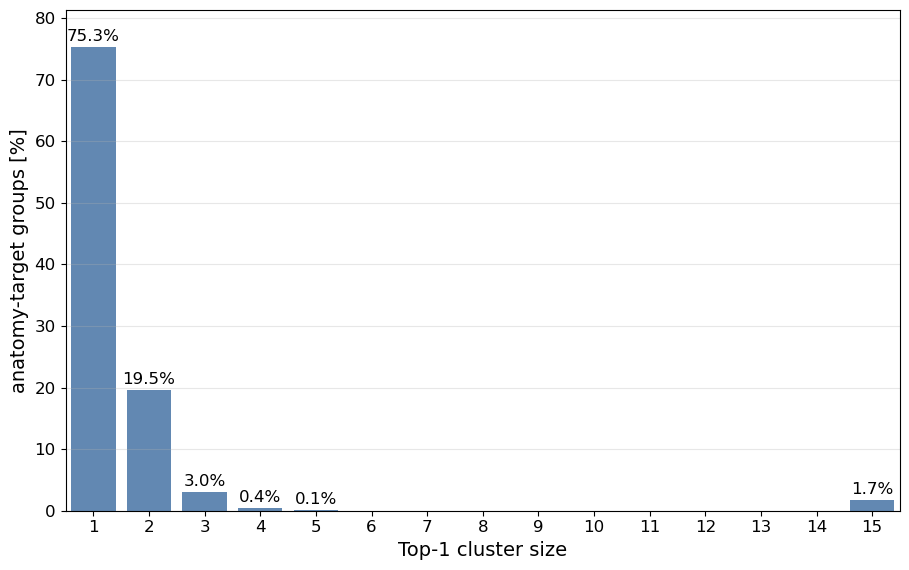

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_cluster_size_distribution.png`

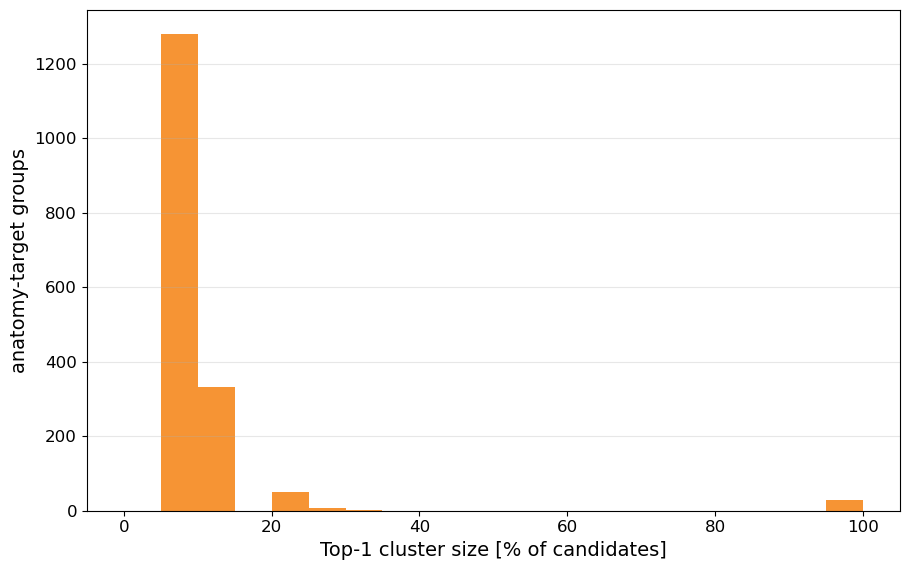

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_cluster_size_relative_distribution.png`

In [46]:
# Visualize the Top-1 cluster-size distribution for one family.
E2_CLUSTER_PLOT_FAMILY = "non_force_aware"  # options: "force_aware", "non_force_aware"

cluster_path = e2_top1_cluster_output_path(E2_CLUSTER_PLOT_FAMILY)
if not cluster_path.exists():
    display(Markdown(f"Build the pairwise table first: `{cluster_path}`"))
else:
    cluster_df = pd.read_csv(cluster_path)
    cluster_distribution = (
        cluster_df["top1_cluster_size"]
        .value_counts()
        .sort_index()
        .rename_axis("top1_cluster_size")
        .reset_index(name="anatomy_target_count")
    )
    cluster_distribution["percent"] = 100.0 * cluster_distribution["anatomy_target_count"] / cluster_distribution["anatomy_target_count"].sum()

    display(Markdown(f"### Top-1 cluster-size distribution: {E2_CLUSTER_PLOT_FAMILY}"))
    display(cluster_distribution.round(3))

    cluster_size_ticks = np.arange(1, 16)

    fig, ax = plt.subplots(figsize=(9.2, 5.8))
    ax.bar(cluster_distribution["top1_cluster_size"], cluster_distribution["percent"], color="#4C78A8", alpha=0.88)
    for _, row in cluster_distribution.iterrows():
        ax.text(row["top1_cluster_size"], row["percent"] + 0.5, f"{row['percent']:.1f}%", ha="center", va="bottom", fontsize=12)
    ax.set_xlabel("Top-1 cluster size", fontsize=14)
    ax.set_ylabel("anatomy-target groups [%]", fontsize=14)
    ax.set_xticks(cluster_size_ticks)
    ax.set_xlim(0.5, 15.5)
    ax.tick_params(axis="both", labelsize=12)
    ax.set_ylim(0, max(5.0, float(cluster_distribution["percent"].max()) + 6.0))
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_CLUSTER_PLOT_FAMILY}_top1_cluster_size_distribution.png"
    figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_CLUSTER_PLOT_FAMILY}_top1_cluster_size_distribution.pdf"
    fig.savefig(figure_png, dpi=200, bbox_inches="tight")
    fig.savefig(figure_pdf, bbox_inches="tight")
    plt.show()
    display(Markdown(f"Saved figure: `{figure_png}`"))

    fig, ax = plt.subplots(figsize=(9.2, 5.8))
    ax.hist(cluster_df["top1_cluster_percent"], bins=np.arange(0, 105, 5), color="#F58518", alpha=0.88)
    ax.set_xlabel("Top-1 cluster size [% of candidates]", fontsize=14)
    ax.set_ylabel("anatomy-target groups", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    figure_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_CLUSTER_PLOT_FAMILY}_top1_cluster_size_relative_distribution.png"
    figure_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_CLUSTER_PLOT_FAMILY}_top1_cluster_size_relative_distribution.pdf"
    fig.savefig(figure_png, dpi=200, bbox_inches="tight")
    fig.savefig(figure_pdf, bbox_inches="tight")
    plt.show()
    display(Markdown(f"Saved figure: `{figure_png}`"))



### 3.3.1 Top-1 Cluster-Size Distribution by Target Branch

This table breaks down the Top-1 cluster-size distribution per target branch. Percentages are normalized within each branch, so every branch row sums to 100%.


### Top-1 cluster-size distribution by target branch: non_force_aware

Saved table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_cluster_size_by_branch.csv`

,target_branch,cluster_size_1,cluster_size_2,cluster_size_3,cluster_size_4,cluster_size_5,cluster_size_15,total_anatomy_targets,cluster_size_1_percent,cluster_size_2_percent,cluster_size_3_percent,cluster_size_4_percent,cluster_size_5_percent,cluster_size_15_percent
0,bct,216,106,16,1,0,1,340,63.529,31.176,4.706,0.294,0.000,0.294
1,lcca,256,59,8,1,1,15,340,75.294,17.353,2.353,0.294,0.294,4.412
2,lsa,304,29,6,0,0,1,340,89.412,8.529,1.765,0.000,0.000,0.294
3,rcca,239,77,11,4,0,9,340,70.294,22.647,3.235,1.176,0.000,2.647
4,rsa,265,61,10,1,0,3,340,77.941,17.941,2.941,0.294,0.000,0.882


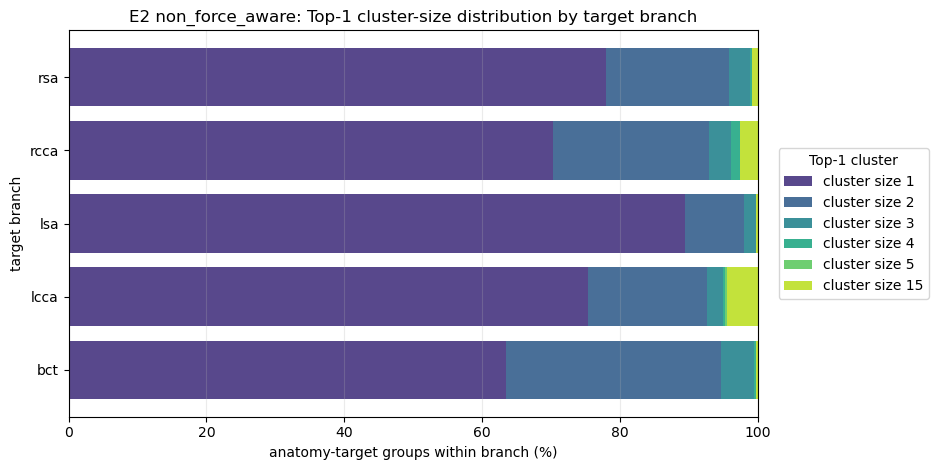

Saved figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_cluster_size_by_branch.png`

In [46]:
# Top-1 cluster-size distribution per target branch.
# This uses the cluster table produced in section 3.3 and does not rebuild the bootstrap.
E2_BRANCH_CLUSTER_PLOT_FAMILY = E2_CLUSTER_PLOT_FAMILY if "E2_CLUSTER_PLOT_FAMILY" in globals() else "force_aware"

cluster_path = e2_top1_cluster_output_path(E2_BRANCH_CLUSTER_PLOT_FAMILY)
if not cluster_path.exists():
    display(Markdown(f"Build the pairwise table first: `{cluster_path}`"))
else:
    cluster_df = pd.read_csv(cluster_path)
    if "branch" not in cluster_df.columns:
        display(Markdown(f"The cluster table has no `branch` column: `{cluster_path}`"))
    else:
        branch_cluster_counts = pd.crosstab(
            cluster_df["branch"].fillna("unknown"),
            cluster_df["top1_cluster_size"].astype(int),
        ).sort_index()
        branch_cluster_counts.index.name = "target_branch"
        branch_cluster_counts.columns = [f"cluster_size_{col}" for col in branch_cluster_counts.columns]
        branch_cluster_counts["total_anatomy_targets"] = branch_cluster_counts.sum(axis=1)

        cluster_size_columns = [col for col in branch_cluster_counts.columns if col.startswith("cluster_size_")]
        branch_cluster_percent = branch_cluster_counts[cluster_size_columns].div(
            branch_cluster_counts["total_anatomy_targets"], axis=0
        ) * 100.0
        branch_cluster_percent.columns = [col.replace("cluster_size_", "cluster_size_") + "_percent" for col in branch_cluster_percent.columns]

        branch_cluster_distribution = pd.concat(
            [branch_cluster_counts, branch_cluster_percent],
            axis=1,
        ).reset_index()

        branch_cluster_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_CLUSTER_PLOT_FAMILY}_top1_cluster_size_by_branch.csv"
        branch_cluster_distribution.to_csv(branch_cluster_csv, index=False)

        display(Markdown(f"### Top-1 cluster-size distribution by target branch: {E2_BRANCH_CLUSTER_PLOT_FAMILY}"))
        display(Markdown(f"Saved table: `{branch_cluster_csv}`"))
        display(branch_cluster_distribution.round(3))

        percent_for_plot = branch_cluster_percent.copy()
        percent_for_plot.columns = [col.replace("cluster_size_", "").replace("_percent", "") for col in percent_for_plot.columns]

        fig, ax = plt.subplots(figsize=(9.5, 4.8))
        left = np.zeros(len(percent_for_plot))
        colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(percent_for_plot.columns)))
        for color, cluster_size in zip(colors, percent_for_plot.columns):
            values = percent_for_plot[cluster_size].to_numpy()
            ax.barh(percent_for_plot.index, values, left=left, label=f"cluster size {cluster_size}", color=color, alpha=0.9)
            left += values

        ax.set_xlabel("anatomy-target groups within branch (%)")
        ax.set_ylabel("target branch")
        ax.set_xlim(0, 100)
        ax.set_title(f"E2 {E2_BRANCH_CLUSTER_PLOT_FAMILY}: Top-1 cluster-size distribution by target branch")
        ax.legend(title="Top-1 cluster", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
        ax.grid(axis="x", alpha=0.25)
        fig.tight_layout()

        branch_cluster_png = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_CLUSTER_PLOT_FAMILY}_top1_cluster_size_by_branch.png"
        branch_cluster_pdf = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_CLUSTER_PLOT_FAMILY}_top1_cluster_size_by_branch.pdf"
        fig.savefig(branch_cluster_png, dpi=200, bbox_inches="tight")
        fig.savefig(branch_cluster_pdf, bbox_inches="tight")
        plt.show()

        display(Markdown(f"Saved figure: `{branch_cluster_png}`"))



### 3.3.2 Bootstrap Comparison of Target Branches

This cell bootstraps anatomy-target groups within each target branch to quantify whether the branch-wise Top-1 ambiguity differs beyond sampling uncertainty. It reports confidence intervals for each branch and pairwise branch differences.


In [57]:
# Bootstrap branch differences in Top-1 ambiguity.
# Metric 1: clear_top1_rate = percentage of anatomy-target groups with cluster size 1.
# Metric 2: mean_cluster_size = average number of candidates not clearly separated from Top-1.
E2_BRANCH_BOOTSTRAP_FAMILY = E2_BRANCH_CLUSTER_PLOT_FAMILY if "E2_BRANCH_CLUSTER_PLOT_FAMILY" in globals() else "non_force_aware"
E2_BRANCH_BOOTSTRAP_N = 10000
E2_BRANCH_BOOTSTRAP_SEED = 123

cluster_path = e2_top1_cluster_output_path(E2_BRANCH_BOOTSTRAP_FAMILY)
if not cluster_path.exists():
    display(Markdown(f"Build the Top-1 cluster table first: `{cluster_path}`"))
else:
    cluster_df = pd.read_csv(cluster_path)
    required_cols = {"branch", "top1_cluster_size"}
    missing_cols = sorted(required_cols - set(cluster_df.columns))
    if missing_cols:
        display(Markdown("Missing columns in cluster table: `" + "`, `".join(missing_cols) + "`."))
    else:
        rng = np.random.default_rng(E2_BRANCH_BOOTSTRAP_SEED)
        branches = sorted(cluster_df["branch"].dropna().unique())
        branch_bootstrap = {}
        branch_summary_rows = []

        for branch in branches:
            branch_values = cluster_df.loc[cluster_df["branch"].eq(branch), "top1_cluster_size"].to_numpy(dtype=float)
            if len(branch_values) == 0:
                continue
            sample_idx = rng.integers(0, len(branch_values), size=(E2_BRANCH_BOOTSTRAP_N, len(branch_values)))
            sampled = branch_values[sample_idx]
            clear_top1_rate = (sampled == 1).mean(axis=1) * 100.0
            mean_cluster_size = sampled.mean(axis=1)
            branch_bootstrap[branch] = {
                "clear_top1_rate": clear_top1_rate,
                "mean_cluster_size": mean_cluster_size,
            }
            branch_summary_rows.append({
                "branch": branch,
                "n_anatomy_targets": int(len(branch_values)),
                "observed_clear_top1_rate_percent": float((branch_values == 1).mean() * 100.0),
                "clear_top1_rate_ci_low": float(np.quantile(clear_top1_rate, 0.025)),
                "clear_top1_rate_ci_high": float(np.quantile(clear_top1_rate, 0.975)),
                "observed_mean_cluster_size": float(branch_values.mean()),
                "mean_cluster_size_ci_low": float(np.quantile(mean_cluster_size, 0.025)),
                "mean_cluster_size_ci_high": float(np.quantile(mean_cluster_size, 0.975)),
            })

        branch_bootstrap_summary = pd.DataFrame(branch_summary_rows).sort_values("branch")

        pairwise_rows = []
        for branch_a, branch_b in itertools.combinations(branches, 2):
            if branch_a not in branch_bootstrap or branch_b not in branch_bootstrap:
                continue
            for metric in ["clear_top1_rate", "mean_cluster_size"]:
                diff = branch_bootstrap[branch_a][metric] - branch_bootstrap[branch_b][metric]
                ci_low = float(np.quantile(diff, 0.025))
                ci_high = float(np.quantile(diff, 0.975))
                pairwise_rows.append({
                    "branch_a": branch_a,
                    "branch_b": branch_b,
                    "metric": metric,
                    "observed_difference_a_minus_b": float(
                        branch_bootstrap_summary.loc[branch_bootstrap_summary["branch"].eq(branch_a), f"observed_{metric}" + ("_percent" if metric == "clear_top1_rate" else "")].iloc[0]
                        - branch_bootstrap_summary.loc[branch_bootstrap_summary["branch"].eq(branch_b), f"observed_{metric}" + ("_percent" if metric == "clear_top1_rate" else "")].iloc[0]
                    ),
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "ci_contains_zero": bool(ci_low <= 0 <= ci_high),
                    "significant_at_95_percent": bool(ci_high < 0 or ci_low > 0),
                })

        branch_pairwise_diff = pd.DataFrame(pairwise_rows).sort_values(["metric", "branch_a", "branch_b"])

        summary_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_BOOTSTRAP_FAMILY}_top1_branch_bootstrap_summary.csv"
        pairwise_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_BRANCH_BOOTSTRAP_FAMILY}_top1_branch_bootstrap_pairwise_differences.csv"
        branch_bootstrap_summary.to_csv(summary_csv, index=False)
        branch_pairwise_diff.to_csv(pairwise_csv, index=False)

        display(Markdown(f"### Branch bootstrap summary: {E2_BRANCH_BOOTSTRAP_FAMILY}"))
        display(Markdown(f"Saved summary table: `{summary_csv}`"))
        display(branch_bootstrap_summary.round(3))

        display(Markdown("### Pairwise branch differences"))
        display(Markdown(f"Saved pairwise table: `{pairwise_csv}`"))
        display(branch_pairwise_diff.round(3))

        significant_pairs = branch_pairwise_diff.loc[branch_pairwise_diff["significant_at_95_percent"]]
        display(Markdown(
            f"Significant pairwise branch differences at 95% CI: **{len(significant_pairs)}** "
            f"of **{len(branch_pairwise_diff)}** comparisons."
        ))



### Branch bootstrap summary: non_force_aware

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_branch_bootstrap_summary.csv`

,branch,n_anatomy_targets,observed_clear_top1_rate_percent,clear_top1_rate_ci_low,clear_top1_rate_ci_high,observed_mean_cluster_size,mean_cluster_size_ci_low,mean_cluster_size_ci_high
0,bct,340,63.529,58.235,68.529,1.456,1.371,1.571
1,lcca,340,75.294,70.588,79.706,1.859,1.571,2.177
2,lsa,340,89.412,86.176,92.647,1.162,1.091,1.265
3,rcca,340,70.294,65.294,75.000,1.697,1.474,1.956
4,rsa,340,77.941,73.529,82.353,1.371,1.244,1.535


### Pairwise branch differences

Saved pairwise table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_branch_bootstrap_pairwise_differences.csv`

,branch_a,branch_b,metric,observed_difference_a_minus_b,ci_low,ci_high,ci_contains_zero,significant_at_95_percent
0,bct,lcca,clear_top1_rate,-11.765,-18.529,-5.000,False,True
2,bct,lsa,clear_top1_rate,-25.882,-32.059,-20.000,False,True
4,bct,rcca,clear_top1_rate,-6.765,-13.824,0.294,True,False
6,bct,rsa,clear_top1_rate,-14.412,-21.176,-7.647,False,True
8,lcca,lsa,clear_top1_rate,-14.118,-19.706,-8.529,False,True
10,lcca,rcca,clear_top1_rate,5.000,-1.765,11.765,True,False
12,lcca,rsa,clear_top1_rate,-2.647,-8.824,3.529,True,False
14,lsa,rcca,clear_top1_rate,19.118,13.529,25.000,False,True
16,lsa,rsa,clear_top1_rate,11.471,6.169,17.059,False,True
18,rcca,rsa,clear_top1_rate,-7.647,-14.118,-1.176,False,True


Significant pairwise branch differences at 95% CI: **14** of **20** comparisons.

### 3.3.2 Inspect Fully Ambiguous Top-1 Cases

This cell identifies anatomy-target groups where the Top-1 cluster contains all candidates. These are cases where the observed best wire is not clearly separated from any alternative under the paired bootstrap score-difference confidence intervals.


In [56]:
# Inspect anatomy-target groups where all candidates are in the Top-1 cluster.
# For non_force_aware this corresponds to cluster size 15; for force_aware it corresponds to cluster size 9.
E2_AMBIGUOUS_CLUSTER_FAMILY = E2_CLUSTER_PLOT_FAMILY if "E2_CLUSTER_PLOT_FAMILY" in globals() else "non_force_aware"
E2_AMBIGUOUS_CLUSTER_SIZE = None  # None means use the maximum cluster size present in the table.
E2_AMBIGUOUS_DETAIL_LIMIT = 10

cluster_path = e2_top1_cluster_output_path(E2_AMBIGUOUS_CLUSTER_FAMILY)
pairwise_path = e2_pairwise_output_path(E2_AMBIGUOUS_CLUSTER_FAMILY)
score_path = e2_bootstrap_output_path(E2_AMBIGUOUS_CLUSTER_FAMILY)

missing_paths = [path for path in [cluster_path, pairwise_path, score_path] if not path.exists()]
if missing_paths:
    display(Markdown("Build the required E2 tables first. Missing: `" + "`, `".join(str(path) for path in missing_paths) + "`."))
else:
    cluster_df = pd.read_csv(cluster_path)
    pairwise_df = pd.read_csv(pairwise_path)
    score_df = pd.read_csv(score_path)

    inspect_cluster_size = int(E2_AMBIGUOUS_CLUSTER_SIZE or cluster_df["top1_cluster_size"].max())
    ambiguous_df = (
        cluster_df.loc[cluster_df["top1_cluster_size"].eq(inspect_cluster_size)]
        .sort_values(["branch", "anatomy_target_key"])
        .reset_index(drop=True)
    )

    display(Markdown(
        f"### Fully ambiguous Top-1 cases: {E2_AMBIGUOUS_CLUSTER_FAMILY}, cluster size {inspect_cluster_size}"
    ))
    display(Markdown(
        f"Found **{len(ambiguous_df)}** anatomy-target groups "
        f"({100.0 * len(ambiguous_df) / len(cluster_df):.2f}% of {len(cluster_df)} groups)."
    ))

    overview_cols = [
        "source_e2_array_index",
        "anatomy_target_key",
        "branch",
        "top1_candidate_key",
        "top1_execution_wire",
        "top1_force_alpha",
        "top1_observed_score",
        "top1_cluster_size",
        "top1_cluster_candidate_keys",
    ]
    overview_cols = [col for col in overview_cols if col in ambiguous_df.columns]
    display(ambiguous_df[overview_cols].head(E2_AMBIGUOUS_DETAIL_LIMIT).round(4))

    ambiguous_keys = set(ambiguous_df["anatomy_target_key"])
    ambiguous_scores = score_df.loc[score_df["anatomy_target_key"].isin(ambiguous_keys)].copy()
    score_spread = (
        ambiguous_scores
        .groupby(["anatomy_target_key", "branch"], dropna=False)
        .agg(
            n_candidates=("candidate_key", "nunique"),
            max_score=("observed_wire_score", "max"),
            min_score=("observed_wire_score", "min"),
            score_range=("observed_wire_score", lambda s: float(s.max() - s.min())),
            mean_score=("observed_wire_score", "mean"),
            max_valid_rate=("valid_rate", "max"),
            min_valid_rate=("valid_rate", "min"),
            valid_rate_range=("valid_rate", lambda s: float(s.max() - s.min())),
            mean_valid_rate=("valid_rate", "mean"),
        )
        .reset_index()
        .sort_values(["score_range", "mean_valid_rate"], ascending=[True, True])
    )

    display(Markdown("### Score and valid-rate spread inside these groups"))
    display(score_spread.head(E2_AMBIGUOUS_DETAIL_LIMIT).round(4))

    all_zero_score_mask = score_spread["max_score"].eq(0.0) & score_spread["min_score"].eq(0.0)
    all_zero_valid_mask = score_spread["max_valid_rate"].eq(0.0) & score_spread["min_valid_rate"].eq(0.0)
    zero_summary = pd.DataFrame([
        {
            "condition": "all candidate wire scores are 0.0",
            "anatomy_target_count": int(all_zero_score_mask.sum()),
            "percent_of_full_cluster_cases": 100.0 * float(all_zero_score_mask.mean()) if len(score_spread) else np.nan,
        },
        {
            "condition": "all candidate valid-trial rates are 0.0",
            "anatomy_target_count": int(all_zero_valid_mask.sum()),
            "percent_of_full_cluster_cases": 100.0 * float(all_zero_valid_mask.mean()) if len(score_spread) else np.nan,
        },
        {
            "condition": "both all scores and all valid-trial rates are 0.0",
            "anatomy_target_count": int((all_zero_score_mask & all_zero_valid_mask).sum()),
            "percent_of_full_cluster_cases": 100.0 * float((all_zero_score_mask & all_zero_valid_mask).mean()) if len(score_spread) else np.nan,
        },
    ])
    display(Markdown("### Zero-score contribution to full Top-1 clusters"))
    display(zero_summary.round(3))

    zero_case_cols = [
        "anatomy_target_key",
        "branch",
        "n_candidates",
        "max_score",
        "min_score",
        "mean_score",
        "max_valid_rate",
        "min_valid_rate",
        "mean_valid_rate",
    ]
    zero_case_cols = [col for col in zero_case_cols if col in score_spread.columns]
    display(Markdown("Full-cluster cases where all candidate scores are 0.0:"))
    display(score_spread.loc[all_zero_score_mask, zero_case_cols].head(E2_AMBIGUOUS_DETAIL_LIMIT).round(4))

    top1_map = ambiguous_df.set_index("anatomy_target_key")["top1_candidate_key"].to_dict()
    top1_pairwise_rows = []
    for anatomy_target_key, top1_candidate in top1_map.items():
        rows = pairwise_df.loc[
            pairwise_df["anatomy_target_key"].eq(anatomy_target_key)
            & (
                pairwise_df["candidate_a"].eq(top1_candidate)
                | pairwise_df["candidate_b"].eq(top1_candidate)
            )
        ].copy()
        if rows.empty:
            continue

        rows["competitor_candidate_key"] = np.where(
            rows["candidate_a"].eq(top1_candidate),
            rows["candidate_b"],
            rows["candidate_a"],
        )
        rows["top1_minus_competitor_observed_diff"] = np.where(
            rows["candidate_a"].eq(top1_candidate),
            rows["observed_diff_a_minus_b"],
            -rows["observed_diff_a_minus_b"],
        )
        rows["top1_minus_competitor_ci_low"] = np.where(
            rows["candidate_a"].eq(top1_candidate),
            rows["ci_low_diff_a_minus_b"],
            -rows["ci_high_diff_a_minus_b"],
        )
        rows["top1_minus_competitor_ci_high"] = np.where(
            rows["candidate_a"].eq(top1_candidate),
            rows["ci_high_diff_a_minus_b"],
            -rows["ci_low_diff_a_minus_b"],
        )
        rows["top1_ci_contains_zero"] = rows["top1_minus_competitor_ci_low"].le(0) & rows["top1_minus_competitor_ci_high"].ge(0)
        top1_pairwise_rows.append(rows)

    if top1_pairwise_rows:
        top1_pairwise_df = pd.concat(top1_pairwise_rows, ignore_index=True)
        top1_pairwise_export_cols = [
            "anatomy_target_key",
            "branch",
            "competitor_candidate_key",
            "top1_minus_competitor_observed_diff",
            "top1_minus_competitor_ci_low",
            "top1_minus_competitor_ci_high",
            "top1_ci_contains_zero",
            "n_matched_trials",
        ]
        top1_pairwise_export_cols = [col for col in top1_pairwise_export_cols if col in top1_pairwise_df.columns]

        detail_csv = E2_SCORE_OUTPUT_DIR / f"e2_{E2_AMBIGUOUS_CLUSTER_FAMILY}_top1_full_cluster_inspection.csv"
        top1_pairwise_df[top1_pairwise_export_cols].to_csv(detail_csv, index=False)

        display(Markdown("### Top-1 pairwise confidence intervals for these groups"))
        display(Markdown(f"Saved detail table: `{detail_csv}`"))
        display(
            top1_pairwise_df[top1_pairwise_export_cols]
            .sort_values(["anatomy_target_key", "top1_minus_competitor_observed_diff"])
            .head(E2_AMBIGUOUS_DETAIL_LIMIT * 5)
            .round(4)
        )
    else:
        display(Markdown("No Top-1 pairwise rows found for the selected ambiguous cases."))




### Fully ambiguous Top-1 cases: non_force_aware, cluster size 15

Found **29** anatomy-target groups (1.71% of 1700 groups).

,source_e2_array_index,anatomy_target_key,branch,top1_candidate_key,top1_execution_wire,top1_force_alpha,top1_observed_score,top1_cluster_size,top1_cluster_candidate_keys
0,1520,Tree_3109__target_000__bct,bct,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff/standard_j,NaN,0.0013,15,non_force_aware::amplatz_super_stiff/gentle | ...
1,506,Tree_1150__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
2,636,Tree_1467__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
3,786,Tree_1737__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
4,826,Tree_1797__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
5,81,Tree_192__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
6,896,Tree_1937__target_001__lcca,lcca,non_force_aware::universal_ii/straight,universal_ii/straight,NaN,0.0018,15,non_force_aware::amplatz_super_stiff/gentle | ...
7,1026,Tree_2172__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
8,1121,Tree_2359__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...
9,1231,Tree_2589__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/gentle,amplatz_super_stiff/gentle,NaN,0.0000,15,non_force_aware::amplatz_super_stiff/gentle | ...


### Score and valid-rate spread inside these groups

,anatomy_target_key,branch,n_candidates,max_score,min_score,score_range,mean_score,max_valid_rate,min_valid_rate,valid_rate_range,mean_valid_rate
0,Tree_1150__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Tree_1467__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tree_1737__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Tree_1797__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Tree_192__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,Tree_2172__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Tree_2359__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,Tree_2589__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,Tree_3035__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23,Tree_3318__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


...

Full-cluster cases where all candidate scores are 0.0:

,anatomy_target_key,branch,n_candidates,max_score,min_score,mean_score,max_valid_rate,min_valid_rate,mean_valid_rate
0,Tree_1150__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
4,Tree_1467__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
6,Tree_1737__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
7,Tree_1797__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
8,Tree_192__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
10,Tree_2172__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
11,Tree_2359__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
12,Tree_2589__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
16,Tree_3035__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0
23,Tree_3318__target_001__lcca,lcca,15,0.0,0.0,0.0,0.0,0.0,0.0


### Top-1 pairwise confidence intervals for these groups

Saved detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e2_clean_analysis/e2_non_force_aware_top1_full_cluster_inspection.csv`

,anatomy_target_key,branch,competitor_candidate_key,top1_minus_competitor_observed_diff,top1_minus_competitor_ci_low,top1_minus_competitor_ci_high,top1_ci_contains_zero,n_matched_trials
14,Tree_1150__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/standard_j,0.0000,0.0000,0.0000,True,500
15,Tree_1150__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/straight,0.0000,0.0000,0.0000,True,500
16,Tree_1150__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/strong_hook,0.0000,0.0000,0.0000,True,500
17,Tree_1150__target_001__lcca,lcca,non_force_aware::amplatz_super_stiff/tight_j,0.0000,0.0000,0.0000,True,500
18,Tree_1150__target_001__lcca,lcca,non_force_aware::steve_default/gentle,0.0000,0.0000,0.0000,True,500
19,Tree_1150__target_001__lcca,lcca,non_force_aware::steve_default/standard_j,0.0000,0.0000,0.0000,True,500
20,Tree_1150__target_001__lcca,lcca,non_force_aware::steve_default/straight,0.0000,0.0000,0.0000,True,500
21,Tree_1150__target_001__lcca,lcca,non_force_aware::steve_default/strong_hook,0.0000,0.0000,0.0000,True,500
22,Tree_1150__target_001__lcca,lcca,non_force_aware::steve_default/tight_j,0.0000,0.0000,0.0000,True,500
23,Tree_1150__target_001__lcca,lcca,non_force_aware::universal_ii/gentle,0.0000,0.0000,0.0000,True,500


## 4. First Sanity Checks

These checks use both `summary_df` and the big `trial_df`. `summary_df` validates the synced job-level aggregates, while `trial_df` validates the actual per-trial distribution used for analysis.


In [14]:
if summary_df.empty:
    display(Markdown("No `summary_df` rows loaded. Check the E2 result roots and whether run folders were synced."))
else:
    by_branch = (
        summary_df.groupby(["training_family", "branch"], dropna=False)
        .agg(
            jobs=("source_e2_array_index", "nunique"),
            summary_rows=("candidate_name", "size"),
            mean_success_rate=("success_rate", "mean"),
            mean_score=("score_mean", "mean"),
            mean_force_max_N=("wire_force_normal_trial_max_mean_N", "mean"),
        )
        .reset_index()
        .sort_values(["training_family", "branch"])
    )
    by_candidate = (
        summary_df.groupby(["training_family", "candidate_key", "wire_model", "wire_shape", "force_alpha"], dropna=False)
        .agg(
            jobs=("source_e2_array_index", "nunique"),
            mean_success_rate=("success_rate", "mean"),
            mean_candidate_score=("candidate_score_final", "mean"),
            mean_force_max_N=("wire_force_normal_trial_max_mean_N", "mean"),
        )
        .reset_index()
        .sort_values(["training_family", "mean_candidate_score", "mean_success_rate"], ascending=[True, False, False])
    )

    display(Markdown("### Coverage by branch and training family"))
    display(by_branch)
    display(Markdown("### Aggregate candidate ranking on the matched E2 subset"))
    display(by_candidate)


### Coverage by branch and training family

,training_family,branch,jobs,summary_rows,mean_success_rate,mean_score,mean_force_max_N
0,force_aware,bct,340,3060,0.579282,0.594542,3.131834
1,force_aware,lcca,340,3060,0.372741,0.454152,0.869208
2,force_aware,lsa,340,3060,0.762735,0.701979,1.429149
3,force_aware,rcca,340,3060,0.247348,0.369300,2.969525
4,force_aware,rsa,340,3060,0.348025,0.436177,3.438802
5,non_force_aware,bct,340,5100,0.632178,0.604244,16.874671
6,non_force_aware,lcca,340,5100,0.404684,0.449520,5.091412
7,non_force_aware,lsa,340,5100,0.844318,0.756647,3.189092
8,non_force_aware,rcca,340,5100,0.160038,0.299274,20.429834
9,non_force_aware,rsa,340,5100,0.377487,0.446134,18.695953


### Aggregate candidate ranking on the matched E2 subset

,training_family,candidate_key,wire_model,wire_shape,force_alpha,jobs,mean_success_rate,mean_candidate_score,mean_force_max_N
8,force_aware,force_aware::universal_ii/standard_j::a05,universal_ii,standard_j,a05,1700,0.689921,0.637446,0.638110
6,force_aware,force_aware::universal_ii/standard_j::a001,universal_ii,standard_j,a001,1700,0.681060,0.636972,0.699752
7,force_aware,force_aware::universal_ii/standard_j::a005,universal_ii,standard_j,a005,1700,0.649093,0.607102,0.789896
1,force_aware,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff,standard_j,a005,1700,0.637169,0.561192,5.621044
2,force_aware,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff,standard_j,a05,1700,0.616052,0.543199,5.509442
0,force_aware,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff,standard_j,a001,1700,0.569058,0.492327,4.029829
4,force_aware,force_aware::steve_default/standard_j::a005,steve_default,standard_j,a005,1700,0.128539,0.001720,1.545032
3,force_aware,force_aware::steve_default/standard_j::a001,steve_default,standard_j,a001,1700,0.187346,0.000182,2.476229
5,force_aware,force_aware::steve_default/standard_j::a05,steve_default,standard_j,a05,1700,0.000000,0.000000,0.000000
10,non_force_aware,non_force_aware::amplatz_super_stiff/standard_j,amplatz_super_stiff,standard_j,NaN,1700,0.719940,0.646030,4.613289


### 4.1 Trial-Level Sanity Checks

These checks confirm that the big cached `trial_df` has the expected row counts and the expected per-job/per-wire trial structure.


In [15]:
if trial_df is None:
    display(Markdown("""`trial_df` is not loaded by default. For this sanity check, first run one of:

```python
trial_df = load_e2_trial_family('non_force_aware')
# or
trial_df = load_e2_trial_family('force_aware')
# or, only if RAM is sufficient:
trial_df = load_e2_trial_combined()
```"""))
else:
    trial_job_counts = (
        trial_df.groupby(["training_family", "source_e2_array_index"], dropna=False)
        .agg(
            trial_rows=("trial_index", "size"),
            candidate_keys=("candidate_key", "nunique"),
            execution_wires=("execution_wire", "nunique"),
            successes=("success", "sum"),
            mean_steps=("steps_total", "mean"),
            max_wire_force_N=("wire_force_normal_trial_max_N", "max"),
        )
        .reset_index()
    )

    trial_wire_counts = (
        trial_df.groupby(["training_family", "candidate_key", "end_reason"], dropna=False)
        .size()
        .rename("trials")
        .reset_index()
        .sort_values(["training_family", "candidate_key", "trials"], ascending=[True, True, False])
    )

    display(trial_job_counts.groupby("training_family").describe(include="all"))
    display(trial_wire_counts.head(50))


source_e2_array_index                                         \
                                count   mean         std  min     25%    50%   
training_family                                                                
force_aware                    1700.0  849.5  490.892045  0.0  424.75  849.5   
non_force_aware                1700.0  849.5  490.892045  0.0  424.75  849.5   

                                 trial_rows          ...  mean_steps  \
                     75%     max      count    mean  ...         75%   
training_family                                      ...               
force_aware      1274.25  1699.0     1700.0  4500.0  ...  601.101833   
non_force_aware  1274.25  1699.0     1700.0  7500.0  ...  569.639833   

                            max_wire_force_N                           \
                        max            count        mean          std   
training_family                                                         
force_aware      828.000000           1700.0  142.759326  2846.765984   
non_force_aware  823.557467           1700.0  461.188861  9146.808719   

                                                                            
                       min        25%        50%        75%            max  
training_family                                                             
force_aware       1.802415   3.395166   4.634318   8.902267   83554.418120  
non_force_aware  17.048443  35.236670  44.404246  62.384874  257148.233053  

[2 rows x 56 columns]

,training_family,candidate_key,end_reason,trials
2,force_aware,force_aware::amplatz_super_stiff/standard_j::a001,target_reached,483699
0,force_aware,force_aware::amplatz_super_stiff/standard_j::a001,max_steps,257441
3,force_aware,force_aware::amplatz_super_stiff/standard_j::a001,vessel_end,108848
1,force_aware,force_aware::amplatz_super_stiff/standard_j::a001,max_steps+vessel_end,12
6,force_aware,force_aware::amplatz_super_stiff/standard_j::a005,target_reached,541594
4,force_aware,force_aware::amplatz_super_stiff/standard_j::a005,max_steps,224665
7,force_aware,force_aware::amplatz_super_stiff/standard_j::a005,vessel_end,83717
5,force_aware,force_aware::amplatz_super_stiff/standard_j::a005,max_steps+vessel_end,24
10,force_aware,force_aware::amplatz_super_stiff/standard_j::a05,target_reached,523644
8,force_aware,force_aware::amplatz_super_stiff/standard_j::a05,max_steps,281179


## 5. Steps to Success by Target Branch

This section uses `trial_df` directly. It keeps only successful trials and summarizes how many interaction steps were needed to reach the target for each target branch. The table reports trial counts, success rate over all trials in the branch, and distribution statistics of `steps_total` among successful trials.


### Steps to success summary table by training family and target branch

,training_family,branch,n_trials,n_success_trials,mean_steps_total,p95_steps_total,p99_steps_total,min_steps_total,max_steps_total,success_rate
0,force_aware,bct,1530000,886302,139.73,345.00,628.00,53,828,0.579
1,force_aware,lcca,1530000,570294,195.79,558.35,759.00,54,828,0.373
2,force_aware,lsa,1530000,1166985,123.66,364.00,604.00,43,828,0.763
3,force_aware,rcca,1530000,378442,272.85,658.00,790.00,65,828,0.247
4,force_aware,rsa,1530000,532479,208.08,575.00,762.00,65,828,0.348
5,non_force_aware,bct,2550000,1612053,164.06,447.00,713.00,48,828,0.632
6,non_force_aware,lcca,2550000,1031943,195.08,566.00,761.00,48,828,0.405
7,non_force_aware,lsa,2550000,2153010,119.36,334.00,655.00,42,828,0.844
8,non_force_aware,rcca,2550000,408098,275.87,669.00,791.00,64,828,0.160
9,non_force_aware,rsa,2550000,962593,182.24,501.00,739.00,62,828,0.377


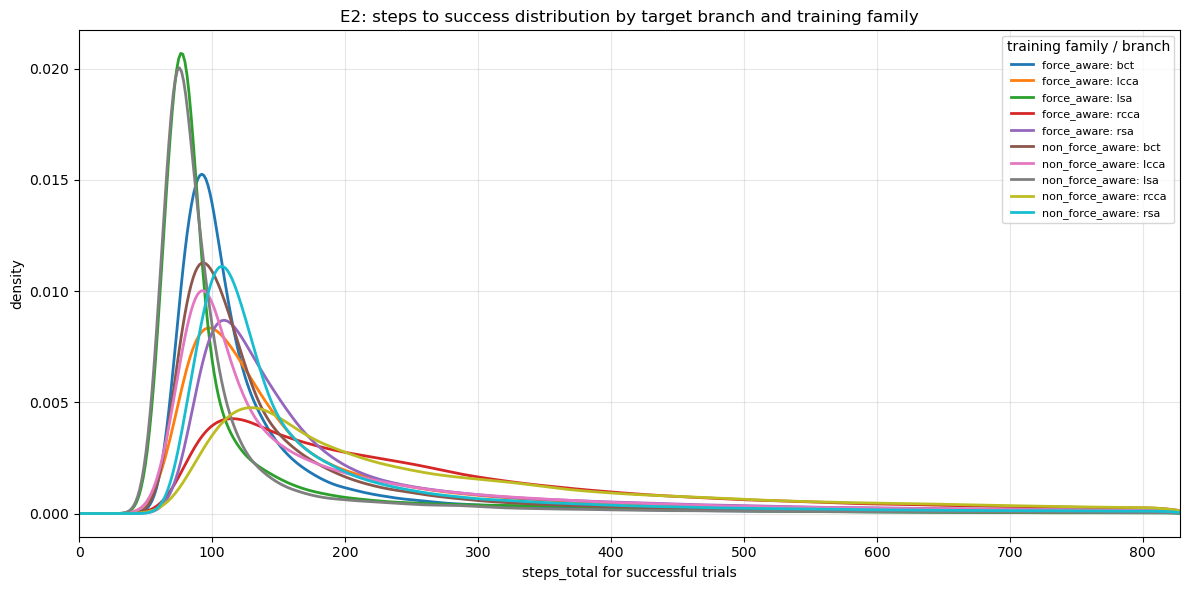

In [16]:
import matplotlib.pyplot as plt

if trial_df is None:
    display(Markdown("Load a trial table first with `load_e2_trial_family(...)` or `load_e2_trial_combined()` to run this section."))
else:
    successful_trials = trial_df[trial_df["success"].astype(bool)].copy()

    branch_step_summary = (
        trial_df.groupby(["training_family", "branch"], dropna=False)
        .agg(
            n_trials=("steps_total", "size"),
            n_success_trials=("success", lambda s: int(s.astype(bool).sum())),
        )
        .reset_index()
    )

    success_step_stats = (
        successful_trials.groupby(["training_family", "branch"], dropna=False)["steps_total"]
        .agg(
            mean_steps_total="mean",
            p95_steps_total=lambda s: s.quantile(0.95),
            p99_steps_total=lambda s: s.quantile(0.99),
            min_steps_total="min",
            max_steps_total="max",
        )
        .reset_index()
    )

    branch_step_summary = branch_step_summary.merge(success_step_stats, on=["training_family", "branch"], how="left")
    branch_step_summary["success_rate"] = branch_step_summary["n_success_trials"] / branch_step_summary["n_trials"]
    branch_step_summary = branch_step_summary.sort_values(["training_family", "branch"])

    display(Markdown("### Steps to success summary table by training family and target branch"))
    display(branch_step_summary.style.format({
        "success_rate": "{:.3f}",
        "mean_steps_total": "{:.2f}",
        "p95_steps_total": "{:.2f}",
        "p99_steps_total": "{:.2f}",
        "min_steps_total": "{:.0f}",
        "max_steps_total": "{:.0f}",
    }))

    fig, ax = plt.subplots(figsize=(12, 6))
    for (training_family, branch), df_branch in successful_trials.groupby(["training_family", "branch"], dropna=False):
        steps = df_branch["steps_total"].dropna()
        if steps.empty:
            continue
        steps.plot(kind="density", ax=ax, linewidth=2, label=f"{training_family}: {branch}")

    ax.set_title("E2: steps to success distribution by target branch and training family")
    ax.set_xlabel("steps_total for successful trials")
    ax.set_ylabel("density")
    ax.set_xlim(left=0, right=float(trial_df["max_episode_steps"].max()))
    ax.grid(True, alpha=0.3)
    ax.legend(title="training family / branch", fontsize=8)
    plt.tight_layout()
    plt.show()


## 6. Tip Shape vs Target Branch Success Rate

This checks whether tip shape and target branch interact. The most direct display is a `branch x tip-shape` success-rate matrix, plus a normalized lift matrix. The lift matrix subtracts each branch's average success rate, so it highlights which shapes perform unusually well or badly for a branch rather than only showing that some branches are globally easier.

Use this as descriptive evidence, not causal proof: the current synced subset is incomplete and different anatomies are not yet fully balanced across all 1000 planned cases.


### Branch x tip-shape success-rate matrices by training family

#### force_aware

wire_shape,standard_j
branch,
bct,0.579
lcca,0.373
lsa,0.763
rcca,0.247
rsa,0.348


Trial counts behind each cell

wire_shape,standard_j
branch,
bct,1530000
lcca,1530000
lsa,1530000
rcca,1530000
rsa,1530000


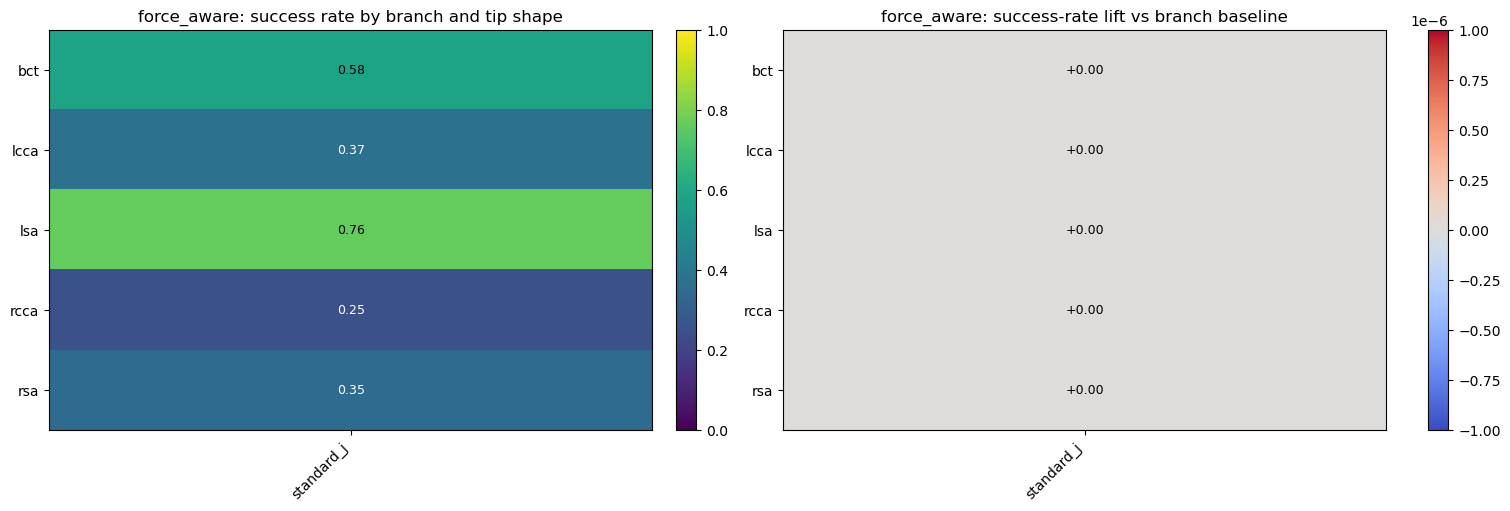

#### non_force_aware

wire_shape,gentle,standard_j,straight,strong_hook,tight_j
branch,,,,,
bct,0.515,0.842,0.057,0.826,0.922
lcca,0.226,0.656,0.024,0.449,0.669
lsa,0.857,0.944,0.853,0.860,0.708
rcca,0.022,0.344,0.005,0.120,0.310
rsa,0.144,0.648,0.034,0.392,0.669


Trial counts behind each cell

wire_shape,gentle,standard_j,straight,strong_hook,tight_j
branch,,,,,
bct,510000,510000,510000,510000,510000
lcca,510000,510000,510000,510000,510000
lsa,510000,510000,510000,510000,510000
rcca,510000,510000,510000,510000,510000
rsa,510000,510000,510000,510000,510000


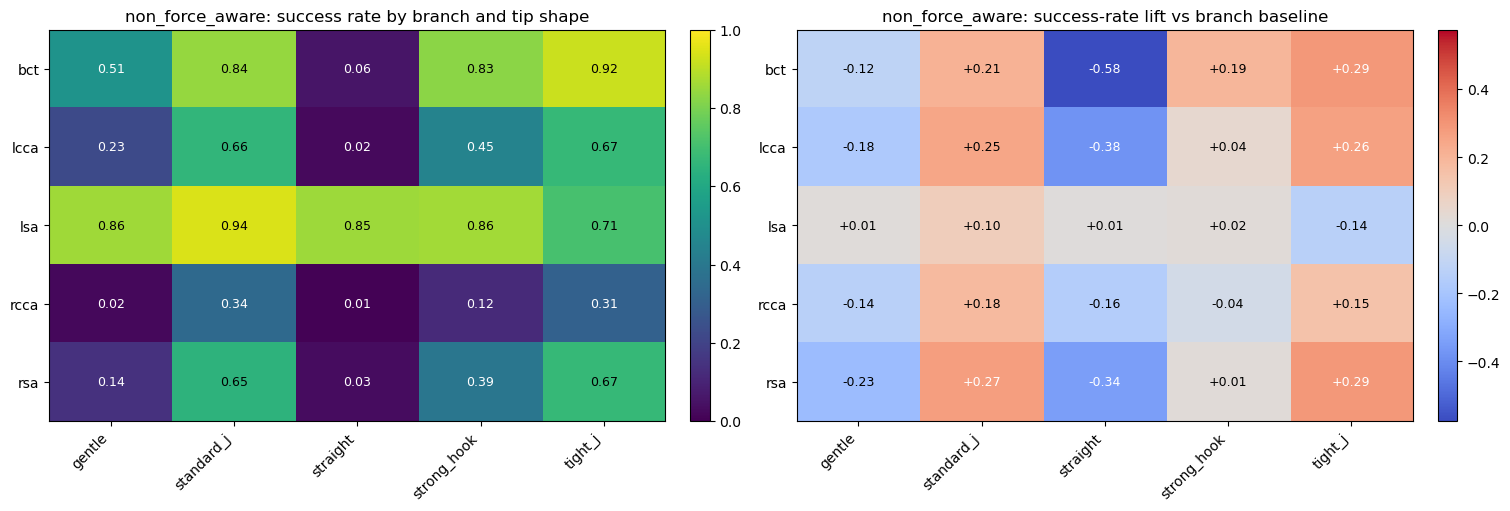

In [17]:
import matplotlib.pyplot as plt

if trial_df is None:
    display(Markdown("Load a trial table first with `load_e2_trial_family(...)` or `load_e2_trial_combined()` to run this section."))
else:
    shape_branch_success = (
        trial_df.groupby(["training_family", "branch", "wire_shape"], dropna=False)
        .agg(
            n_trials=("success", "size"),
            n_success_trials=("success", lambda s: int(s.astype(bool).sum())),
            success_rate=("success", lambda s: float(s.astype(bool).mean())),
            mean_steps_total_success=("steps_total", lambda s: float(s[trial_df.loc[s.index, "success"].astype(bool)].mean())),
            mean_wire_force_max_N=("wire_force_normal_trial_max_N", "mean"),
        )
        .reset_index()
    )

    display(Markdown("### Branch x tip-shape success-rate matrices by training family"))
    for training_family, family_df in shape_branch_success.groupby("training_family", dropna=False):
        success_matrix = family_df.pivot(index="branch", columns="wire_shape", values="success_rate").sort_index()
        trial_count_matrix = family_df.pivot(index="branch", columns="wire_shape", values="n_trials").reindex_like(success_matrix)
        branch_baseline = trial_df.loc[trial_df["training_family"].eq(training_family)].groupby("branch")["success"].apply(lambda s: float(s.astype(bool).mean()))
        shape_success_lift = success_matrix.sub(branch_baseline, axis=0)

        display(Markdown(f"#### {training_family}"))
        display(success_matrix.style.format("{:.3f}").background_gradient(cmap="viridis", axis=None))
        display(Markdown("Trial counts behind each cell"))
        display(trial_count_matrix.astype("Int64"))

        fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
        im0 = axes[0].imshow(success_matrix.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        axes[0].set_title(f"{training_family}: success rate by branch and tip shape")
        axes[0].set_xticks(range(success_matrix.shape[1]), success_matrix.columns, rotation=45, ha="right")
        axes[0].set_yticks(range(success_matrix.shape[0]), success_matrix.index)
        for i in range(success_matrix.shape[0]):
            for j in range(success_matrix.shape[1]):
                value = success_matrix.iloc[i, j]
                if pd.notna(value):
                    axes[0].text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value < 0.55 else "black", fontsize=9)
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        max_abs_lift = float(np.nanmax(np.abs(shape_success_lift.to_numpy(dtype=float)))) if not shape_success_lift.empty else 0.0
        max_abs_lift = max(max_abs_lift, 1e-6)
        im1 = axes[1].imshow(shape_success_lift.to_numpy(dtype=float), aspect="auto", cmap="coolwarm", vmin=-max_abs_lift, vmax=max_abs_lift)
        axes[1].set_title(f"{training_family}: success-rate lift vs branch baseline")
        axes[1].set_xticks(range(shape_success_lift.shape[1]), shape_success_lift.columns, rotation=45, ha="right")
        axes[1].set_yticks(range(shape_success_lift.shape[0]), shape_success_lift.index)
        for i in range(shape_success_lift.shape[0]):
            for j in range(shape_success_lift.shape[1]):
                value = shape_success_lift.iloc[i, j]
                if pd.notna(value):
                    axes[1].text(j, i, f"{value:+.2f}", ha="center", va="center", color="white" if abs(value) > max_abs_lift * 0.45 else "black", fontsize=9)
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        plt.show()


## 7. Wire Type vs Target Branch Success Rate

This repeats the branch interaction analysis at the wire-family level: `amplatz_super_stiff`, `steve_default`, and `universal_ii`. It pools over tip shapes within each wire type, so it answers whether one wire family is generally easier to control for a target branch independent of the exact tip shape.

As above, the lift matrix subtracts the branch baseline success rate. Positive lift means that a wire type performs better than the average wire on that branch; negative lift means worse than branch average.


### Branch x wire-type success-rate matrices by training family

#### force_aware

wire_model,amplatz_super_stiff,steve_default,universal_ii
branch,,,
bct,0.836,0.000,0.902
lcca,0.513,0.000,0.605
lsa,0.820,0.526,0.942
rcca,0.412,0.000,0.330
rsa,0.456,0.000,0.588


Trial counts behind each cell

wire_model,amplatz_super_stiff,steve_default,universal_ii
branch,,,
bct,510000,510000,510000
lcca,510000,510000,510000
lsa,510000,510000,510000
rcca,510000,510000,510000
rsa,510000,510000,510000


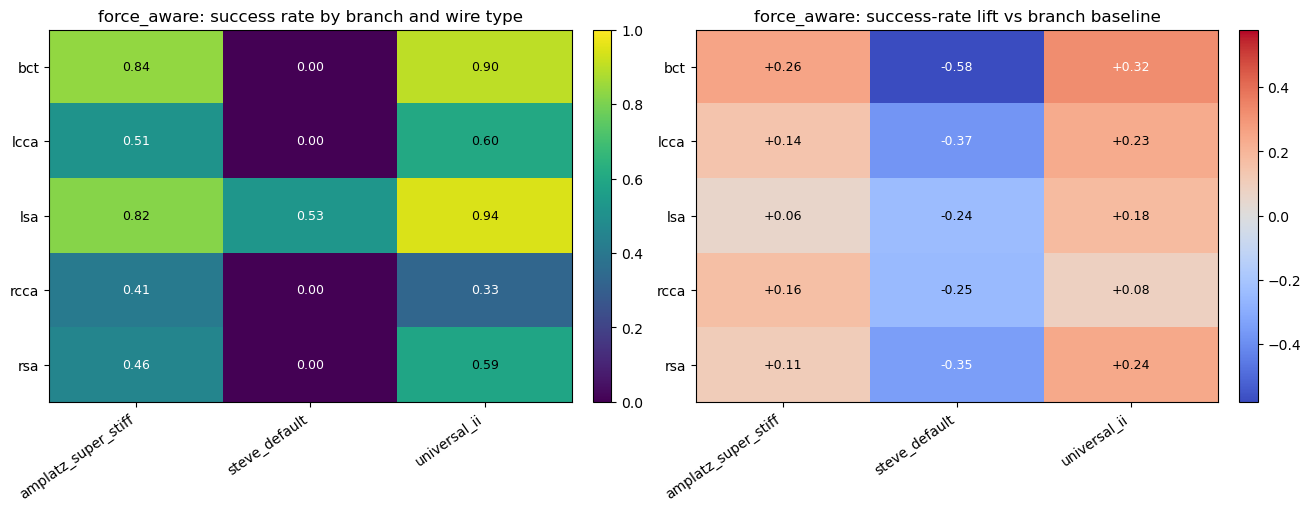

#### non_force_aware

wire_model,amplatz_super_stiff,steve_default,universal_ii
branch,,,
bct,0.678,0.546,0.673
lcca,0.442,0.396,0.376
lsa,0.857,0.860,0.816
rcca,0.135,0.238,0.107
rsa,0.444,0.410,0.278


Trial counts behind each cell

wire_model,amplatz_super_stiff,steve_default,universal_ii
branch,,,
bct,850000,850000,850000
lcca,850000,850000,850000
lsa,850000,850000,850000
rcca,850000,850000,850000
rsa,850000,850000,850000


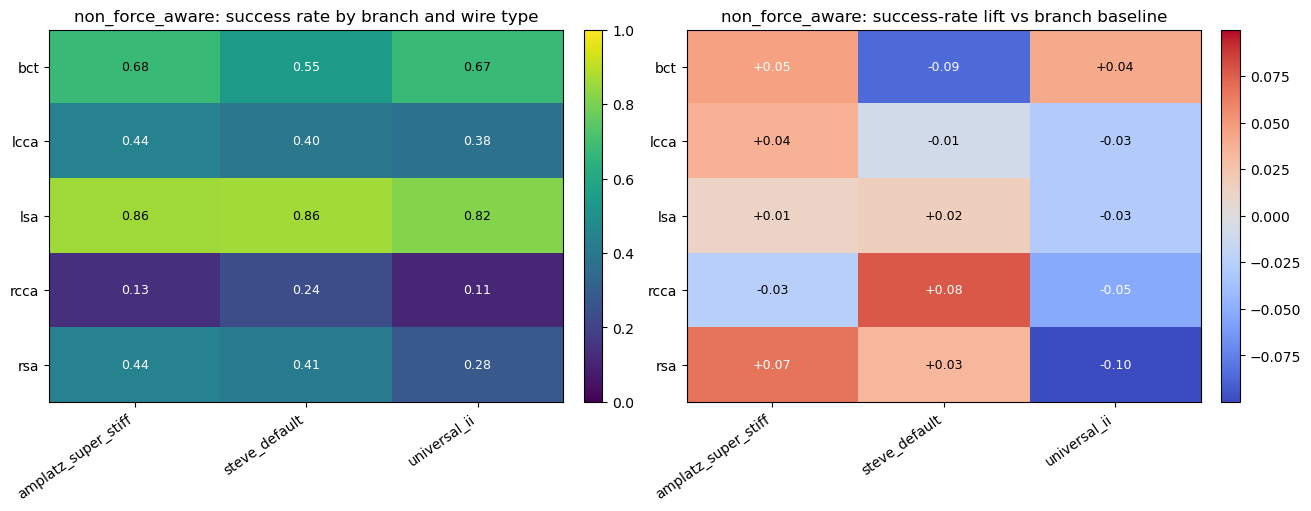

In [18]:
if trial_df is None:
    display(Markdown("Load a trial table first with `load_e2_trial_family(...)` or `load_e2_trial_combined()` to run this section."))
else:
    type_branch_success = (
        trial_df.groupby(["training_family", "branch", "wire_model"], dropna=False)
        .agg(
            n_trials=("success", "size"),
            n_success_trials=("success", lambda s: int(s.astype(bool).sum())),
            success_rate=("success", lambda s: float(s.astype(bool).mean())),
            mean_steps_total_success=("steps_total", lambda s: float(s[trial_df.loc[s.index, "success"].astype(bool)].mean())),
            mean_wire_force_max_N=("wire_force_normal_trial_max_N", "mean"),
        )
        .reset_index()
    )

    display(Markdown("### Branch x wire-type success-rate matrices by training family"))
    for training_family, family_df in type_branch_success.groupby("training_family", dropna=False):
        type_success_matrix = family_df.pivot(index="branch", columns="wire_model", values="success_rate").sort_index()
        type_trial_count_matrix = family_df.pivot(index="branch", columns="wire_model", values="n_trials").reindex_like(type_success_matrix)
        branch_baseline = trial_df.loc[trial_df["training_family"].eq(training_family)].groupby("branch")["success"].apply(lambda s: float(s.astype(bool).mean()))
        type_success_lift = type_success_matrix.sub(branch_baseline, axis=0)

        display(Markdown(f"#### {training_family}"))
        display(type_success_matrix.style.format("{:.3f}").background_gradient(cmap="viridis", axis=None))
        display(Markdown("Trial counts behind each cell"))
        display(type_trial_count_matrix.astype("Int64"))

        fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
        im0 = axes[0].imshow(type_success_matrix.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        axes[0].set_title(f"{training_family}: success rate by branch and wire type")
        axes[0].set_xticks(range(type_success_matrix.shape[1]), type_success_matrix.columns, rotation=35, ha="right")
        axes[0].set_yticks(range(type_success_matrix.shape[0]), type_success_matrix.index)
        for i in range(type_success_matrix.shape[0]):
            for j in range(type_success_matrix.shape[1]):
                value = type_success_matrix.iloc[i, j]
                if pd.notna(value):
                    axes[0].text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value < 0.55 else "black", fontsize=9)
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        max_abs_lift = float(np.nanmax(np.abs(type_success_lift.to_numpy(dtype=float)))) if not type_success_lift.empty else 0.0
        max_abs_lift = max(max_abs_lift, 1e-6)
        im1 = axes[1].imshow(type_success_lift.to_numpy(dtype=float), aspect="auto", cmap="coolwarm", vmin=-max_abs_lift, vmax=max_abs_lift)
        axes[1].set_title(f"{training_family}: success-rate lift vs branch baseline")
        axes[1].set_xticks(range(type_success_lift.shape[1]), type_success_lift.columns, rotation=35, ha="right")
        axes[1].set_yticks(range(type_success_lift.shape[0]), type_success_lift.index)
        for i in range(type_success_lift.shape[0]):
            for j in range(type_success_lift.shape[1]):
                value = type_success_lift.iloc[i, j]
                if pd.notna(value):
                    axes[1].text(j, i, f"{value:+.2f}", ha="center", va="center", color="white" if abs(value) > max_abs_lift * 0.45 else "black", fontsize=9)
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        plt.show()


## 8. Per-Wire Performance and Force Summary

This table compares the complete wire identities (`wire_model / wire_shape`). It keeps raw success and the relevant force telemetry side by side, because high success can be clinically unattractive if it comes with large wall/contact forces.

The table is sorted by success rate first and then by lower whole-wire max force.


### Per-candidate summary: success, steps, and forces

,training_family,force_alpha,candidate_key,wire_model,wire_shape,execution_wire,n_trials,n_success_trials,success_rate,force_score_available_rate,force_safe_rate,mean_steps_total,p95_steps_total,p99_steps_total,tip_force_max_mean_N,tip_force_max_p95_N,tip_force_max_p99_N,tip_force_mean_mean_N,wire_force_max_mean_N,wire_force_max_p95_N,wire_force_max_p99_N,wire_force_max_observed_N,wire_force_mean_mean_N
0,force_aware,a05,force_aware::universal_ii/standard_j::a05,universal_ii,standard_j,universal_ii/standard_j,850000,586433,0.690,0.998,0.996,330.34,828.00,828.00,0.079,0.092,0.179,0.004,0.638,0.183,0.266,5915.571,0.029
1,force_aware,a001,force_aware::universal_ii/standard_j::a001,universal_ii,standard_j,universal_ii/standard_j,850000,578901,0.681,1.000,0.999,311.47,828.00,828.00,0.088,0.097,0.189,0.004,0.700,0.196,0.282,5766.703,0.027
2,force_aware,a005,force_aware::universal_ii/standard_j::a005,universal_ii,standard_j,universal_ii/standard_j,850000,551729,0.649,1.000,0.998,316.34,828.00,828.00,0.084,0.093,0.178,0.004,0.790,0.184,0.273,7262.990,0.032
3,force_aware,a005,force_aware::amplatz_super_stiff/standard_j::a005,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,850000,541594,0.637,0.996,0.981,351.55,828.00,828.00,0.709,0.702,1.430,0.037,5.621,1.439,2.229,83554.418,0.185
4,force_aware,a05,force_aware::amplatz_super_stiff/standard_j::a05,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,850000,523644,0.616,0.999,0.988,398.51,828.00,828.00,0.991,0.695,1.431,0.038,5.509,1.390,2.085,48018.405,0.161
5,force_aware,a001,force_aware::amplatz_super_stiff/standard_j::a001,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,850000,483699,0.569,0.939,0.928,398.61,828.00,828.00,0.778,0.696,1.432,0.036,4.030,1.348,2.070,57429.664,0.142
6,force_aware,a001,force_aware::steve_default/standard_j::a001,steve_default,standard_j,steve_default/standard_j,850000,159244,0.187,0.867,0.538,693.81,828.00,828.00,2.078,6.675,10.125,0.382,2.476,8.723,16.918,111.662,0.494
7,force_aware,a005,force_aware::steve_default/standard_j::a005,steve_default,standard_j,steve_default/standard_j,850000,109258,0.129,0.780,0.563,734.33,828.00,828.00,1.336,4.126,6.602,0.255,1.545,5.320,9.831,39.785,0.354
8,force_aware,a05,force_aware::steve_default/standard_j::a05,steve_default,standard_j,steve_default/standard_j,850000,0,0.000,0.000,0.000,828.00,828.00,828.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,non_force_aware,nan,non_force_aware::steve_default/standard_j,steve_default,standard_j,steve_default/standard_j,850000,641176,0.754,1.000,0.013,265.78,828.00,828.00,7.223,12.257,20.568,0.811,33.577,20.339,29.177,149062.490,2.410


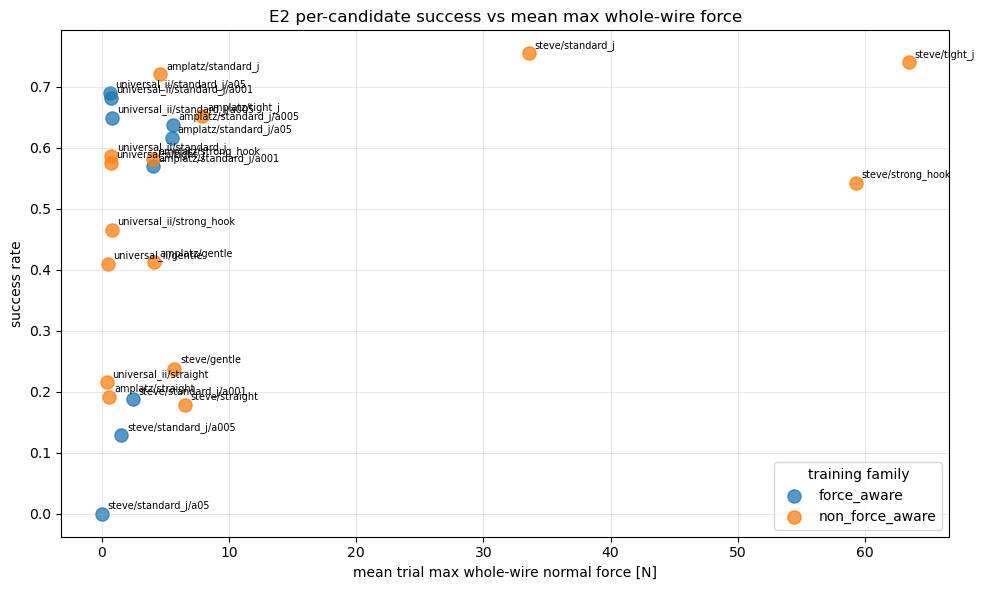

In [19]:
if trial_df is None:
    display(Markdown("Load a trial table first with `load_e2_trial_family(...)` or `load_e2_trial_combined()` to run this section."))
else:
    wire_performance_summary = (
        trial_df.groupby(["training_family", "force_alpha", "candidate_key", "wire_model", "wire_shape", "execution_wire"], dropna=False)
        .agg(
            n_trials=("success", "size"),
            n_success_trials=("success", lambda s: int(s.astype(bool).sum())),
            success_rate=("success", lambda s: float(s.astype(bool).mean())),
            force_score_available_rate=("force_available_for_score", lambda s: float(s.astype(bool).mean())),
            force_safe_rate=("force_within_safety_threshold", lambda s: float(s.astype(bool).mean())),
            mean_steps_total=("steps_total", "mean"),
            p95_steps_total=("steps_total", lambda s: s.quantile(0.95)),
            p99_steps_total=("steps_total", lambda s: s.quantile(0.99)),
            tip_force_max_mean_N=("tip_force_normal_trial_max_N", "mean"),
            tip_force_max_p95_N=("tip_force_normal_trial_max_N", lambda s: s.quantile(0.95)),
            tip_force_max_p99_N=("tip_force_normal_trial_max_N", lambda s: s.quantile(0.99)),
            tip_force_mean_mean_N=("tip_force_normal_trial_mean_N", "mean"),
            wire_force_max_mean_N=("wire_force_normal_trial_max_N", "mean"),
            wire_force_max_p95_N=("wire_force_normal_trial_max_N", lambda s: s.quantile(0.95)),
            wire_force_max_p99_N=("wire_force_normal_trial_max_N", lambda s: s.quantile(0.99)),
            wire_force_max_observed_N=("wire_force_normal_trial_max_N", "max"),
            wire_force_mean_mean_N=("wire_force_normal_trial_mean_N", "mean"),
        )
        .reset_index()
        .sort_values(["training_family", "success_rate", "wire_force_max_mean_N"], ascending=[True, False, True])
        .reset_index(drop=True)
    )

    display(Markdown("### Per-candidate summary: success, steps, and forces"))
    display(
        wire_performance_summary.style.format(
            {
                "success_rate": "{:.3f}",
                "force_score_available_rate": "{:.3f}",
                "force_safe_rate": "{:.3f}",
                "mean_steps_total": "{:.2f}",
                "p95_steps_total": "{:.2f}",
                "p99_steps_total": "{:.2f}",
                "tip_force_max_mean_N": "{:.3f}",
                "tip_force_max_p95_N": "{:.3f}",
                "tip_force_max_p99_N": "{:.3f}",
                "tip_force_mean_mean_N": "{:.3f}",
                "wire_force_max_mean_N": "{:.3f}",
                "wire_force_max_p95_N": "{:.3f}",
                "wire_force_max_p99_N": "{:.3f}",
                "wire_force_max_observed_N": "{:.3f}",
                "wire_force_mean_mean_N": "{:.3f}",
            }
        ).background_gradient(subset=["success_rate", "force_safe_rate"], cmap="Greens")
         .background_gradient(subset=["wire_force_max_mean_N", "wire_force_max_p95_N", "wire_force_max_p99_N", "wire_force_max_observed_N"], cmap="Reds")
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    for training_family, family_df in wire_performance_summary.groupby("training_family", dropna=False):
        ax.scatter(
            family_df["wire_force_max_mean_N"],
            family_df["success_rate"],
            s=90,
            alpha=0.75,
            label=str(training_family),
        )
        for _, row in family_df.iterrows():
            alpha_suffix = f"/{row['force_alpha']}" if pd.notna(row["force_alpha"]) else ""
            ax.annotate(
                f"{row['wire_model'].replace('_super_stiff', '').replace('_default', '')}/{row['wire_shape']}{alpha_suffix}",
                (row["wire_force_max_mean_N"], row["success_rate"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
            )
    ax.set_title("E2 per-candidate success vs mean max whole-wire force")
    ax.set_xlabel("mean trial max whole-wire normal force [N]")
    ax.set_ylabel("success rate")
    ax.grid(True, alpha=0.3)
    ax.legend(title="training family")
    plt.tight_layout()
    plt.show()


## 9. Next Analysis Ideas

Good follow-up analyses once more E2 jobs are synced:

- success rate by branch and wire family
- target difficulty per anatomy and branch
- rank stability by anatomy subset size
- score versus force tradeoff for each wire
- failure modes by `end_reason` from `trial_df`
- comparison of E2 branch-end performance against E1 fixed target results
- anatomy-level outlier detection: anatomies where all wires fail or all forces are high


## H1 Score Distribution